# ✈️ NASA C-MAPSS FD003 — EDA + 전처리 + Feature Engineering + Validation Split 파이프라인

> **센서 선택 버전: Scenario B** — `s_1, s_5, s_6, s_16, s_18, s_19` 수동 지정 6개 제거 → **15개 유지**

---

**목적:** 결정 1~5 적용 → ML/DL 분기 전처리 → 전처리 후 검증 → CSV 저장

| 구분 | 내용 |
|------|------|
| 데이터셋 | FD003 (HPC + Fan 열화, 단일 운전 조건) |
| 공통 파이프라인 | 센서 제거(수동6개→15개 유지) → RUL Cap → Gaussian 스무딩 → Validation 분리 |
| ML 분기 | lag / diff / rolling / EMA 파생변수 → ML 전체 피처 MinMax 정규화 |
| DL 분기 | 센서 MinMax 정규화 → 슬라이딩 윈도우 Long Format |

## 0. 환경 설정

In [1]:
import sys, subprocess
for pkg in ['numpy','pandas','scikit-learn','scipy','matplotlib','seaborn']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
print('✅ 라이브러리 설치 완료')

✅ 라이브러리 설치 완료


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
import joblib
import json
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp, kendalltau, mannwhitneyu, levene, ttest_rel, shapiro, wilcoxon
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────────────────────
import logging
import matplotlib.font_manager as fm
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

def force_korean_font():
    system = platform.system()
    if system == "Windows":
        font_path = "C:/Windows/Fonts/malgun.ttf"
        font_name = "Malgun Gothic"
    elif system == "Darwin":
        font_path = "/System/Library/Fonts/AppleGothic.ttf"
        font_name = "AppleGothic"
    else:
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        font_name = "NanumGothic"
        if not os.path.exists(font_path):
            os.system("apt-get update -qq")
            os.system("apt-get install -y fonts-nanum -qq")
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = font_name
        plt.rcParams["font.sans-serif"] = [font_name]
        plt.rcParams["axes.unicode_minus"] = False
        print(f"✅ 한글 폰트 적용: {font_name}")
    else:
        print("❌ 폰트 못 찾음")

force_korean_font()

# ── 다크 테마 ─────────────────────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})
force_korean_font()

# ── 전역 상수 ─────────────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS  = [f's_{i}' for i in range(1,22)]
OP_COLS      = ['setting_1','setting_2','setting_3']
ID_COLS      = ['unit_nr','time_cycles']
CONST_THR    = 0.01

# ── 수동 제거/유지 센서 ───────────────────────────────────────────────────

# ── 센서 선택 방식: 수동 지정 (Scenario B — FD003 특성대로 6개 제거) ──────────
# EDA + 통계 검정 근거:
#   s_1, s_5, s_16, s_18, s_19 → std=0.0000 완전 상수, RUL 상관 없음
#   s_6                         → std=0.0181, MK비율 61%, RUL r=-0.215 (약함), lag=30 노이즈
#   s_10                         → std=0.0035, RUL r=-0.363 → 유지
# 결과: 21개 → 15개 유지

FINAL_REMOVE_SENSORS = ['s_1', 's_5', 's_6', 's_16', 's_18', 's_19']
FINAL_USEFUL_SENSORS = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_10',
                        's_11', 's_12', 's_13', 's_14', 's_15',
                        's_17', 's_20', 's_21']

MANUAL_REMOVE = FINAL_REMOVE_SENSORS.copy()  # 수동 지정 6개 제거
MANUAL_KEEP   = ['s_10']  # s_10은 std가 낮아 자동 제거될 수 있으나 RUL 상관이 있어 최종 유지

# ── 센서 분류 (EDA 시각화용) ──────────────────────────────────────────────
FAN_SENSORS = ['s_1','s_6','s_8','s_13','s_15']
HPC_SENSORS = ['s_3','s_7','s_9','s_11','s_12']

TEMPORAL_LAGS      = [1, 3, 5]
TEMPORAL_DIFFS     = [1]
TEMPORAL_ROLLS     = [3, 5]
TEMPORAL_ROLL_STDS = [3, 5]
TEMPORAL_EMAS      = [5]

# ── 전처리 실험 CONFIG ────────────────────────────────────────────────────
CONFIG = {
    'RUL_CAP'      : 125,      # 실험: 130, 135, 140
    'GAUSS_SIGMA'  : 2,        # 실험: 3
    'WINDOW_SIZE'  : 30,       # 실험: 10
    'SCALER_TYPE'  : 'minmax', # 실험: 'standard'
    'CLUSTERING'   : False,    # 실험: True (고장 모드 클러스터링 여부)
    'VALID_RATIO'  : 0.2,
    'RANDOM_STATE' : 42,
}

RUL_CAP      = CONFIG['RUL_CAP']
GAUSS_SIGMA  = CONFIG['GAUSS_SIGMA']
WINDOW_SIZE  = CONFIG['WINDOW_SIZE']
SCALER_TYPE  = CONFIG['SCALER_TYPE']
CLUSTERING   = CONFIG['CLUSTERING']
VALID_RATIO  = CONFIG['VALID_RATIO']
RANDOM_STATE = CONFIG['RANDOM_STATE']
STEP         = 1

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}')
print(f'   Window={WINDOW_SIZE}  |  Scaler={SCALER_TYPE}  |  Clustering={CLUSTERING}')
print(f'   수동 제거: {MANUAL_REMOVE}  |  수동 유지: {MANUAL_KEEP}')

✅ 한글 폰트 적용: Malgun Gothic
✅ 한글 폰트 적용: Malgun Gothic
✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01
   Window=30  |  Scaler=minmax  |  Clustering=False
   수동 제거: ['s_1', 's_5', 's_6', 's_16', 's_18', 's_19']  |  수동 유지: ['s_10']


## 1. 데이터 로딩 & 컬럼명 표준화

In [3]:
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData','./CMAPSSData','../CMAPSSData','../../CMAPSSData',
    '../../../CMAPSSData',
    '../../../../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD002.txt')):
        DATA_DIR = c; break
else:
    print(f'❌ 경로 없음. 현재: {os.getcwd()}')

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD003.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD003.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD003.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

# 컬럼명 표준화 (로딩 즉시)
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print(f'✅ FD003 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))

✅ FD003 로딩 완료
   Train : (24720, 26)  |  엔진 100대
   Test  : (16596, 26)   |  엔진 100대
   RUL   : (100, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669


### 📊 1. 데이터 로딩 & 컬럼명 표준화 결과

| 항목 | FD001 | FD003 |
|------|-------|-------|
| Train 행 | 20,631 | 24,720 |
| Test 행 | 13,096 | 16,596 |
| 엔진 수(Train) | 100대 | 100대 |
| 엔진 수(Test) | 100대 | 100대 |
| 컬럼 수 | 26 | 26 |
  
> 📌 엔진 수는 FD001과 동일(100대)하나 Train 행이 더 많음  
> → FD003 엔진의 평균 수명이 FD001보다 길다는 의미 → 2-2 수명 분포에서 확인 예정

---
## 2. 전처리 전 EDA
### 2-1. 기초 통계 & 데이터 품질

In [4]:
print(train_raw.columns.tolist())

['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


In [5]:
print('=== 기초 통계 & 데이터 품질 검사 ===')

# 결측치·중복·음수 확인
quality = pd.DataFrame({
    '구분'       : ['Train','Test'],
    '전체 행'    : [len(train_raw), len(test_raw)],
    '결측치'     : [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행'    : [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서'  : [(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수'    : [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '판정'       : ['✅ 정상','✅ 정상'],
}).set_index('구분')
display(quality)

# 센서별 기술통계
print('\n--- 센서별 기술통계 (Train) ---')
desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
display(desc[['mean','std','min','max','CV(변동계수)']]
        .style.background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))

print('\n📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상')
print('📌 FD003은 단일 운전 조건이므로 CV가 높은 센서는 열화 신호일 가능성 있음')

=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,판정
구분,,,,,,
Train,24720,0,0,0,100,✅ 정상
Test,16596,0,0,0,100,✅ 정상



--- 센서별 기술통계 (Train) ---


,mean,std,min,max,CV(변동계수)
s_1,518.6700,0.0000,518.6700,518.6700,0.0000
s_2,642.4579,0.5230,640.8400,645.1100,0.0008
s_3,1588.0792,6.8104,1564.3000,1615.3900,0.0043
s_4,1404.4712,9.7732,1377.0600,1441.1600,0.0070
s_5,14.6200,0.0000,14.6200,14.6200,0.0000
s_6,21.5958,0.0181,21.4500,21.6100,0.0008
s_7,555.1438,3.4373,549.6100,570.4900,0.0062
s_8,2388.0716,0.1583,2386.9000,2388.6000,0.0001
s_9,9064.1108,19.9803,9017.9800,9234.3500,0.0022
s_10,1.3012,0.0035,1.2900,1.3200,0.0027



📌 CV(변동계수) ≈ 0 인 센서 = 비행 내내 거의 같은 값 = 열화 정보 없음 → 제거 대상
📌 FD003은 단일 운전 조건이므로 CV가 높은 센서는 열화 신호일 가능성 있음


### 📊 2-1. 기초 통계 & 데이터 품질 검사 결과

---

#### 데이터 품질 확인
| 항목 | Train | Test |
|------|-------|------|
| 전체 행 | 24,720 | 16,596 |
| 결측치 | 0 | 0 |
| 중복 행 | 0 | 0 |
| 음수 센서 | 0 | 0 |
| 엔진 수 | 100 | 100 |

> ✅ 결측치, 중복, 음수 전부 없음  
> → C-MAPSS는 컴퓨터 시뮬레이션 데이터라 매우 깨끗함  
> → 별도 결측치 처리 불필요

---

#### CV(변동계수) 해석
> CV = std / mean → 값이 클수록 센서가 많이 변함  
> CV ≈ 0 → 비행 내내 거의 같은 값 → 열화 정보 없음 → 제거 대상

**상수 센서 (CV = 0.0000, 제거 대상)**
| 센서 | CV | 판정 |
|------|----|------|
| s_1 | 0.0000 | 완전 상수 |
| s_5 | 0.0000 | 완전 상수 |
| s_16 | 0.0000 | 완전 상수 |
| s_18 | 0.0000 | 완전 상수 |
| s_19 | 0.0000 | 완전 상수 |

**FD001 대비 변화 ★**
| 센서 | FD001 | FD003 | 비고 |
|------|-------|-------|------|
| s_6 | CV≈0 (제거) | CV=0.0008 (유지 가능) | 팬 열화 영향으로 변동 생긴 듯 |
| s_10 | CV≈0 (제거) | CV=0.0027 (유지 가능) | 동일 |
| s_8 | CV>0 (유지) | CV=0.0001 (요주의) | 거의 상수에 가까움 |
| s_13 | CV>0 (유지) | CV=0.0001 (요주의) | 거의 상수에 가까움 |

**유용 센서 (CV 높음, 유지 대상)**
| 센서 | CV | 물리적 의미 |
|------|----|------------|
| s_15 | 0.0072 | BPR 바이패스 비율 |
| s_4 | 0.0070 | T50 LPT 출구 온도 |
| s_7 | 0.0062 | P30 HPC 출구 압력 |
| s_11 | 0.0063 | Ps30 정적압력 |
| s_20 | 0.0064 | W31 HPT 냉각블리드 |
| s_21 | 0.0064 | W32 LPT 냉각블리드 |

---

#### 🔑 핵심 결론
> **데이터 품질 이상 없음**  
> **확실한 상수 센서 → s_1, s_5, s_16, s_18, s_19 (5개)**  
> **FD001에서 제거했던 s_6, s_10이 FD003에서는 미세한 변동 존재 → 결정 1 단계에서 std 기준으로 재확인 예정**  
> **s_8, s_13은 CV 극히 낮음(0.0001) → 제거 대상에 포함될 가능성 있음**

---
### 2-2. 엔진 수명 분포

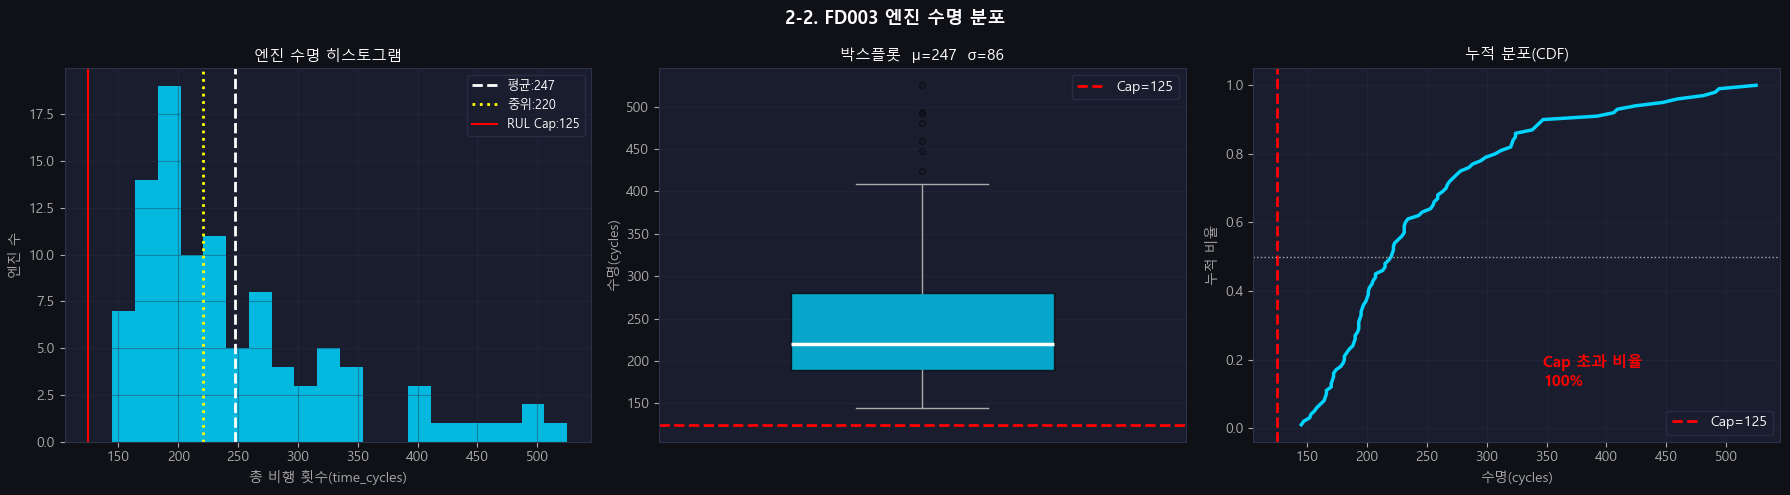


엔진 수명 통계:
  평균=247.2  중위=220.5  min=145  max=525
  Cap=125 초과 엔진: 100대 (100%)

📌 100% 엔진이 수명 125 사이클 초과 → Cap=125 설정 근거


In [6]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-2. FD003 엔진 수명 분포', fontsize=13, fontweight='bold')

# 히스토그램
ax = axes[0]
ax.hist(lifecycles, bins=20, color=C[0], alpha=0.85, edgecolor='none')
ax.axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
ax.axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
ax.axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'RUL Cap:{RUL_CAP}')
ax.set_xlabel('총 비행 횟수(time_cycles)')
ax.set_ylabel('엔진 수')
ax.set_title('엔진 수명 히스토그램')
ax.legend(fontsize=9)

# 박스플롯
ax = axes[1]
bp = ax.boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                medianprops=dict(color='white',lw=2.5),
                whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                flierprops=dict(marker='o',color=GRAY,markersize=4,alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_ylabel('수명(cycles)')
ax.set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
ax.set_xticks([])
ax.legend()

# CDF
ax = axes[2]
lc_sorted = np.sort(lifecycles)
cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
ax.plot(lc_sorted, cdf, color=C[0], lw=2.5)
ax.axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.axhline(0.5, color=GRAY, ls=':', lw=1)
pct_above = (lifecycles > RUL_CAP).mean()*100
ax.text(0.55, 0.15, f'Cap 초과 비율\n{pct_above:.0f}%', transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')
ax.set_xlabel('수명(cycles)')
ax.set_ylabel('누적 비율')
ax.set_title('누적 분포(CDF)')
ax.legend()

plt.tight_layout(); plt.show()

print(f'\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
print(f'  Cap={RUL_CAP} 초과 엔진: {(lifecycles>RUL_CAP).sum()}대 ({pct_above:.0f}%)')
print(f'\n📌 100% 엔진이 수명 {RUL_CAP} 사이클 초과 → Cap={RUL_CAP} 설정 근거')

### 📊 2-2. 엔진 수명 분포 분석 결과

---

#### 수명 통계 요약
| 항목 | FD001 | FD003 |
|------|-------|-------|
| 평균 | 206 | **247** |
| 중위 | 199 | **220** |
| 최솟값 | 128 | **145** |
| 최댓값 | 362 | **525** |
| 표준편차 | - | **86** |
| Cap=125 초과 비율 | 100% | **100%** |

---

#### 히스토그램 해석
- 150~250 구간에 엔진이 가장 많이 분포
- 평균(247) > 중위(220) → 오른쪽으로 꼬리가 긴 분포 (우편향)
- FD001보다 분포가 더 넓고 최댓값(525)이 훨씬 큼 → 수명 편차가 큰 편
- 빨간 수직선(Cap=125): 모든 엔진이 이 선 오른쪽에 위치

---

#### 🔑 핵심 결론
> **모든 엔진(100%)의 수명이 125사이클 초과 → Cap=125 설정 근거 유지**  
> **FD001 대비 평균 수명 41사이클 증가, 최댓값 163사이클 증가**  
> → 고장 모드가 2가지(HPC+팬)라 열화 속도가 다양해 수명 분산이 더 큰 것으로 추정  
> → Cap=125는 그대로 적용 가능

---
## 2-3. 센서 분포 & 이상치 (전처리 전)

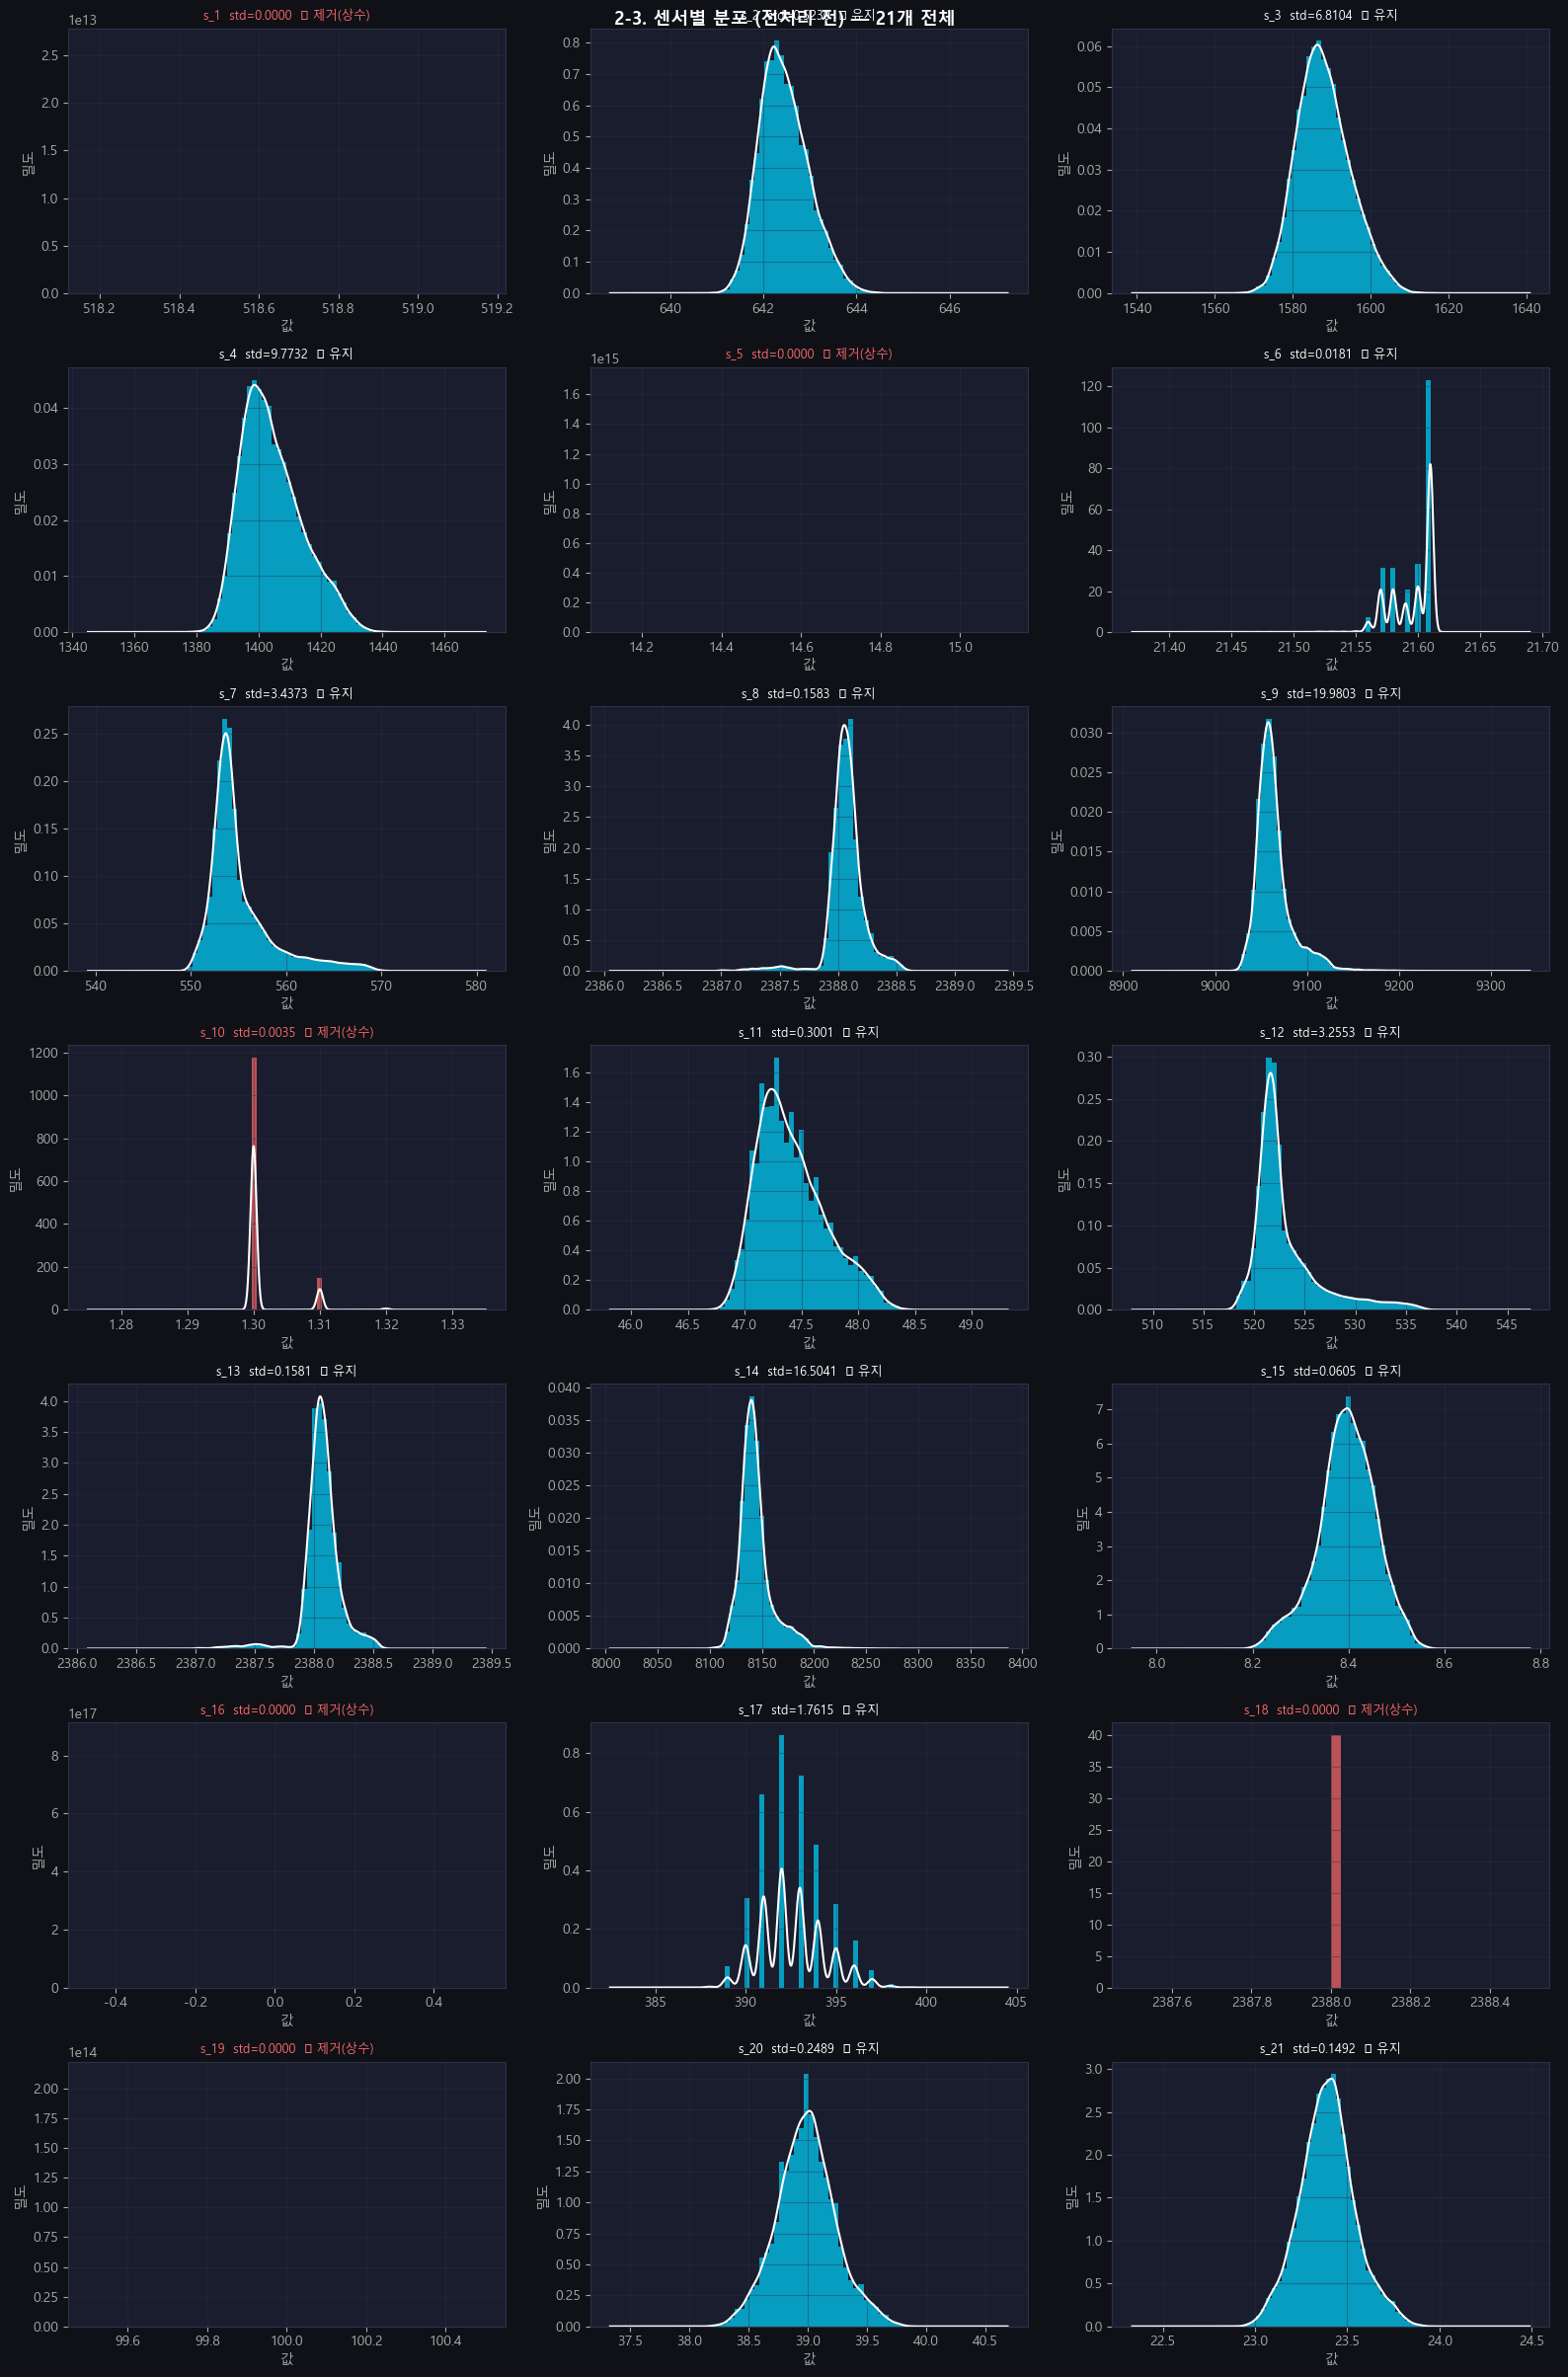

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
1,s_2,190,0.769
2,s_3,180,0.728
3,s_4,173,0.700
5,s_6,151,0.611
6,s_7,2188,8.851
7,s_8,1714,6.934
8,s_9,1844,7.460
9,s_10,2906,11.756
10,s_11,153,0.619
11,s_12,2276,9.207


In [7]:
# 21개 센서 분포 (히스토그램 + KDE)
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-3. 센서별 분포 (전처리 전) — 21개 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_const = std_val < CONST_THR
    color = C[1] if is_const else C[0]
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try:
        data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 제거(상수)' if is_const else '✅ 유지'
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_const else WHITE)
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

# IQR 이상치 탐지
print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서':s,'이상치 수':n_out,'비율(%)':round(n_out/len(train_raw)*100,3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero):
    display(nonzero)
else:
    print('✅ IQR 기준 이상치 없음 (시뮬레이션 데이터 특성)')

### 📊 2-3. 센서별 분포 & 이상치 탐지 결과

---

#### 센서 분포 시각화 해석

**상수 센서 (빨간색, 제거 대상)**
| 센서 | std | FD001 동일 여부 |
|------|-----|----------------|
| s_1 | 0.0000 | ✅ 동일 |
| s_5 | 0.0000 | ✅ 동일 |
| s_16 | 0.0000 | ✅ 동일 |
| s_18 | 0.0000 | ✅ 동일 |
| s_19 | 0.0000 | ✅ 동일 |
| s_10 | 0.0035 | ⚠️ std는 낮지만 RUL 상관이 있어 최종 유지 |

> 📌 최종 통일 기준에서는 s_6은 제거하고, s_10은 유지한다.  
> → s_10은 `MANUAL_KEEP=['s_10']`으로 자동 제거를 방지한다.  
> → 최종 센서 기준: 6개 제거 → 15개 유지

**주목할 센서 분포 특이사항**
- s_6: 오른쪽에 뾰족한 다봉 형태 → 값이 몇 개 구간에만 집중
- s_10: 뾰족한 단봉이나 std=0.0035로 경계값 → 제거 여부 검토 필요
- s_17: 다봉분포 → 정수값으로 이산적으로 분포 (388~400 사이 정수)
- 나머지 유지 센서: 전반적으로 단봉 분포 ✅ → FD001과 유사, 멀티모달 없음 → 단일 운전 조건 확인

---

#### IQR 이상치 탐지 결과

**이상치 비율 높은 센서 (5% 이상)**
| 센서 | 이상치 수 | 비율(%) | FD001 비교 | 비고 |
|------|---------|---------|-----------|------|
| s_10 | 2,906 | 11.756 | FD001 제거 센서 | 상수에 가까워 IQR=0 → 오탐 |
| s_12 | 2,276 | 9.207 | FD001 낮았음 | ⚠️ 주목 |
| s_7 | 2,188 | 8.851 | FD001 낮았음 | ⚠️ 주목 |
| s_13 | 1,820 | 7.362 | FD001 낮았음 | ⚠️ 주목 |
| s_14 | 1,863 | 7.536 | FD001 높았음 | 열화 신호 가능성 |
| s_9 | 1,844 | 7.460 | FD001 높았음 | 열화 신호 가능성 |
| s_8 | 1,714 | 6.934 | FD001 낮았음 | ⚠️ 주목 |

**이상치 비율 낮은 센서 (1% 미만)**
| 센서 | 비율(%) |
|------|---------|
| s_2 | 0.769 |
| s_3 | 0.728 |
| s_4 | 0.700 |
| s_17 | 0.044 |

---

#### 🔑 핵심 결론
> **상수 센서: s_1, s_5, s_16, s_18, s_19 → FD001과 동일하게 제거**  
> **s_10(std=0.0035)은 경계값이지만 RUL 상관을 고려해 최종 유지**  
> **s_10 이상치 11.8%는 진짜 이상치가 아님 → IQR≈0인 상수 센서 특성상 정상값도 이상치로 오탐**  
> **s_7, s_8, s_12, s_13 이상치 비율이 FD001보다 높음 → 팬 열화 모드 추가로 인한 값 범위 확대 가능성**  
> **단봉분포 확인 → FD002처럼 클러스터별 정규화 불필요, 단일 MinMax 정규화 적용 가능 ✅**

---
## 2-4. 센서 간 상관관계 히트맵 (전처리 전)

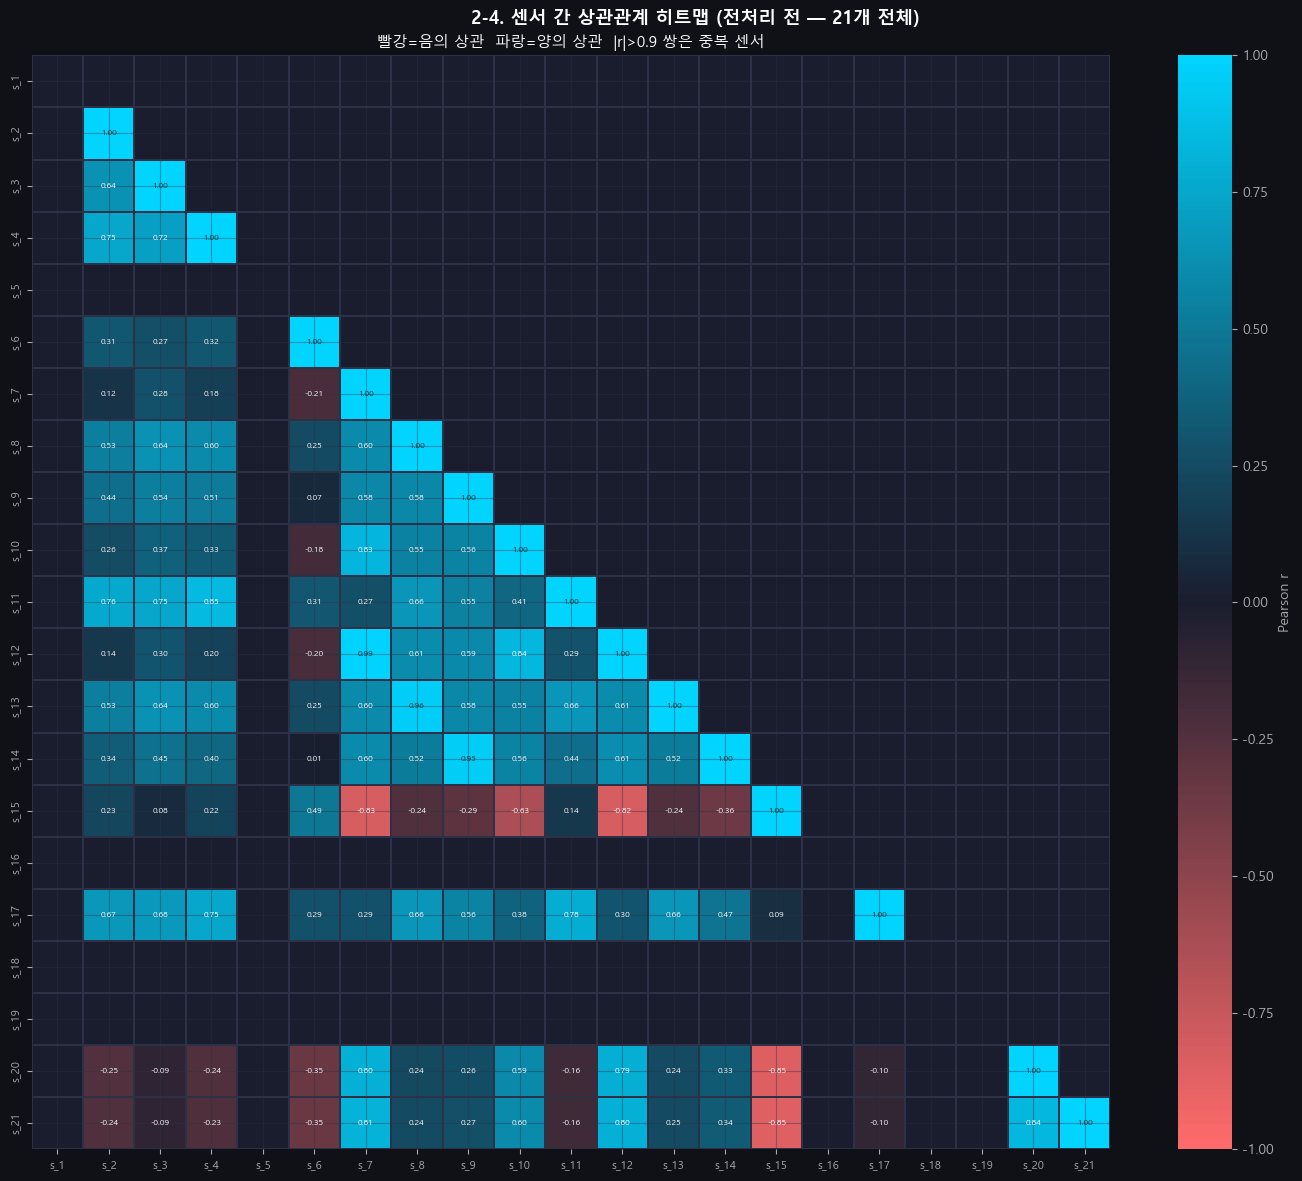

--- 고상관 센서 쌍 (|r| > 0.9) ---


,센서A,센서B,r
0,s_7,s_12,0.989
1,s_8,s_13,0.964
2,s_9,s_14,0.954


In [8]:
from matplotlib.colors import LinearSegmentedColormap

cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)

corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('2-4. 센서 간 상관관계 히트맵 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

# 고상관 쌍
print('--- 고상관 센서 쌍 (|r| > 0.9) ---')
pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i,j]
        if abs(r) > 0.9:
            pairs.append({'센서A':SENSOR_COLS[i],'센서B':SENSOR_COLS[j],'r':round(r,3)})
if pairs:
    display(pd.DataFrame(pairs))
else:
    print('  해당 없음')

### 📊 2-4. 센서 간 상관관계 히트맵 결과

---

#### 고상관 센서 쌍 (|r| > 0.9)
| 센서A | 센서B | r | FD001 비교 |
|-------|-------|---|-----------|
| s_7 | s_12 | 0.989 | ⚠️ FD001에 없던 새 쌍 |
| s_8 | s_13 | 0.964 | ⚠️ FD001에 없던 새 쌍 |
| s_9 | s_14 | 0.954 | ✅ FD001과 동일 (r=0.963) |

> 📌 FD001은 고상관 쌍이 s_9↔s_14 단 1개였는데  
> FD003은 3개로 늘어남 → 팬 열화 모드 추가 영향

---

#### 새로 생긴 고상관 쌍 해석

**s_7 ↔ s_12 (r=0.989)**
- s_7 = P30 HPC 출구 압력
- s_12 = phi 연료/Ps30 비율
- 연료비율이 HPC 압력과 거의 1:1로 움직임
- 팬 열화 시 공기 흐름 변화 → 압력과 연료비율이 동시에 영향받는 것으로 추정

**s_8 ↔ s_13 (r=0.964)**
- s_8 = Nf 팬 속도(rpm)
- s_13 = NRf 보정 팬 속도(rpm)
- NRf는 Nf의 보정값 → 수학적으로 파생된 센서
- **팬 열화 모드가 추가되면서 팬 속도 변동이 커져 상관이 뚜렷해진 것**
- FD001에서는 팬 관련 변동이 적어 상관이 낮았던 센서

**s_9 ↔ s_14 (r=0.954)**
- FD001과 동일한 패턴 유지
- s_14는 s_9의 보정값으로 구조적으로 동일한 정보

---

#### 주요 상관관계 패턴
- s_2, s_3, s_4 (온도 센서군): 서로 양의 상관 (0.64~0.75)
- s_15 ↔ s_7, s_9, s_11, s_12: 음의 상관 (-0.53~-0.63) → 바이패스 비율과 압력/속도 반비

---
## 2-5. 센서별 열화 트렌드 (전처리 전)

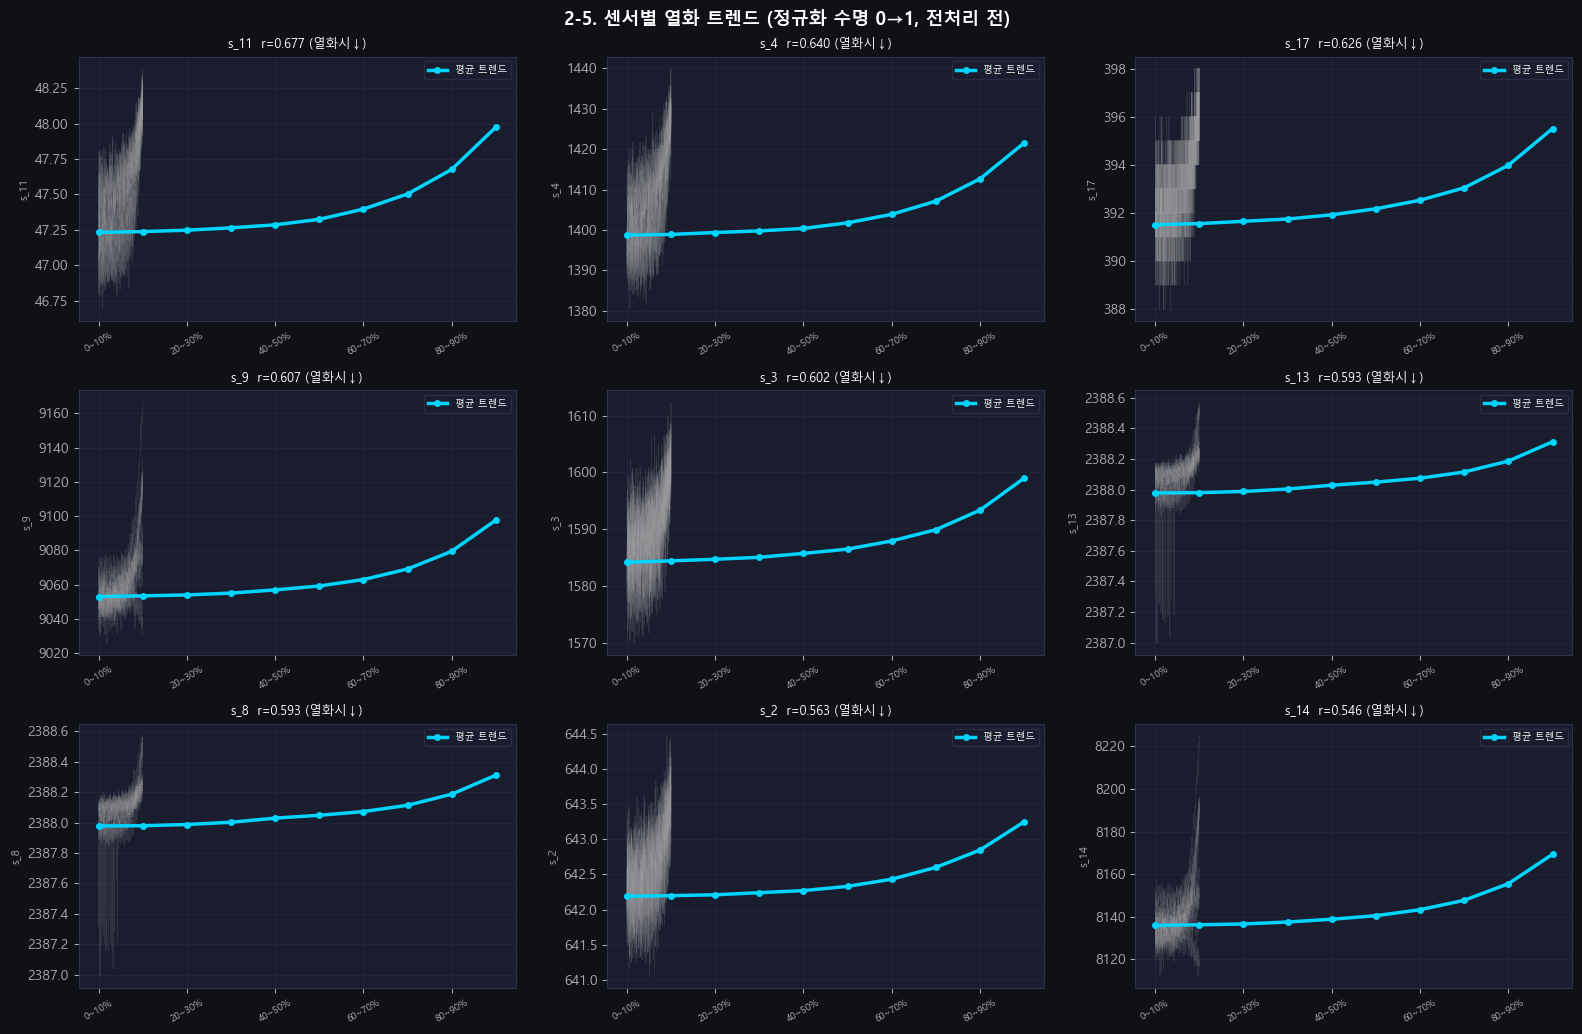

📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)


In [9]:
# 정규화 수명축(0=새것, 1=고장 직전)으로 평균 트렌드 확인
tr_trend = train_raw.copy()
mc = tr_trend.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = tr_trend.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles']/tr_trend['max_c']

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1],bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

# 유의미한 트렌드 센서만 표시 (기준 0.05)
corr_with_life = tr_trend[SENSOR_COLS+['norm_life']].corr()['norm_life'][SENSOR_COLS]
trend_sensors  = corr_with_life[corr_with_life.abs()>0.05].sort_values(key=abs, ascending=False).index.tolist()
trend_sensors  = trend_sensors[:9]

if len(trend_sensors) == 0:
    print('📌 FD003 조건 영향으로 유의미한 트렌드 센서 없음 → 전처리 후 재확인 예정')
else:
    n_cols = 3
    n_rows = (len(trend_sensors)+n_cols-1)//n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
    fig.suptitle('2-5. 센서별 열화 트렌드 (정규화 수명 0→1, 전처리 전)', fontsize=13, fontweight='bold')

    x_pos = range(len(labels))
    sample_units = tr_trend['unit_nr'].unique()[:15]

    for ax, s in zip(axes.flat, trend_sensors):
        for u in sample_units:
            sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
            ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
        ax.plot(x_pos, trend_mean[s].values, color=C[0], lw=2.5, marker='o', markersize=4, label='평균 트렌드')
        r = corr_with_life[s]
        direction = '열화시↑' if r<0 else '열화시↓'
        ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
        ax.set_xticks(x_pos[::2])
        ax.set_xticklabels(labels[::2], rotation=30, fontsize=7)
        ax.set_ylabel(s, fontsize=8)
        ax.legend(fontsize=7)

    for ax in axes.flat[len(trend_sensors):]:
        ax.set_visible(False)

    plt.tight_layout(); plt.show()
    print('📌 r < 0: 엔진이 닳을수록 센서값 증가 (온도↑)  |  r > 0: 감소 (속도↓)')

### 📊 2-5. 센서별 열화 트렌드 결과

---

#### 유의미한 트렌드 센서 (|r| > 0.05, 상위 9개)

| 순위 | 센서 | r | 방향 | 물리적 의미 | FD001 비교 |
|------|------|---|------|------------|-----------|
| 1 | s_11 | 0.677 | 열화시↑ | Ps30 정적압력 | ✅ 동일 패턴 |
| 2 | s_4 | 0.640 | 열화시↑ | T50 LPT 출구 온도 | ✅ 동일 패턴 |
| 3 | s_17 | 0.626 | 열화시↑ | htBleed 블리드 엔탈피 | ✅ 동일 패턴 |
| 4 | s_9 | 0.607 | 열화시↑ | Nc 코어 속도 | ⚠️ FD001은 열화시↓ |
| 5 | s_3 | 0.602 | 열화시↑ | T30 HPC 출구 온도 | ✅ 동일 패턴 |
| 6 | s_13 | 0.593 | 열화시↑ | NRf 보정 팬 속도 | ⚠️ FD001과 다름 |
| 7 | s_8 | 0.593 | 열화시↑ | Nf 팬 속도 | ⚠️ FD001과 다름 |
| 8 | s_2 | 0.563 | 열화시↑ | T24 LPC 출구 온도 | ✅ 동일 패턴 |
| 9 | s_14 | 0.546 | 열화시↑ | NRc 보정 코어속도 | ⚠️ FD001은 열화시↓ |

---

#### 트렌드 패턴 해석

**전반적으로 트렌드가 매우 뚜렷함 ✅**
- 9개 센서 모두 r>0.5 이상의 강한 상관
- 평균 트렌드 곡선이 깔끔하게 우상향 → 열화 신호 명확
- FD003은 고장 모드 2가지임에도 트렌드가 불명확하지 않음 → 예상보다 좋은 결과

**FD001과 방향이 다른 센서 주목 ⚠️**
- s_8, s_13 (팬 속도 관련): FD003에서 열화시↑로 나옴
  → 팬 열화 모드 추가로 팬 속도가 오히려 올라가는 패턴 반영
- s_9, s_14 (코어 속도 관련): FD003에서 열화시↑
  → FD001에서는 열화시↓였던 센서인데 방향이 반대
  → 두 고장 모드가 섞이면서 평균 트렌드 방향이 바뀐 것으로 추정

**초반 0~10% 구간 분산이 큼**
- 모든 센서에서 초반 회색 개별 궤적이 넓게 퍼져 있음
- 엔진마다 초기 상태 차이 + 두 고장 모드 혼재 영향
- Gaussian 스무딩(σ=2) 적용 후 완화될 것으로 예상

---

#### s_8, s_13 재평가
> 2-3에서 CV=0.0001로 거의 상수에 가깝다고 했는데  
> 트렌드를 보면 r=0.593으로 열화 신호가 분명히 존재  
> → **제거하면 안 됨, 유지 확정**

---

#### 🔑 핵심 결론
> **9개 센서 모두 강한 열화 트렌드 확인 → FD001과 동일한 전처리 적용 가능**  
> **s_8, s_13은 CV 낮아도 열화 신호 있음 → 유지**  
> **s_9, s_14 트렌드 방향 반전은 팬 열화 모드 혼재 영향 → 제거 아닌 모델이 학습할 정보**  
> **다음 RUL 상관계수에서 s_10 제거 여부 최종 결정 예정**

---
## 2-6. RUL 상관계수 (전처리 전)

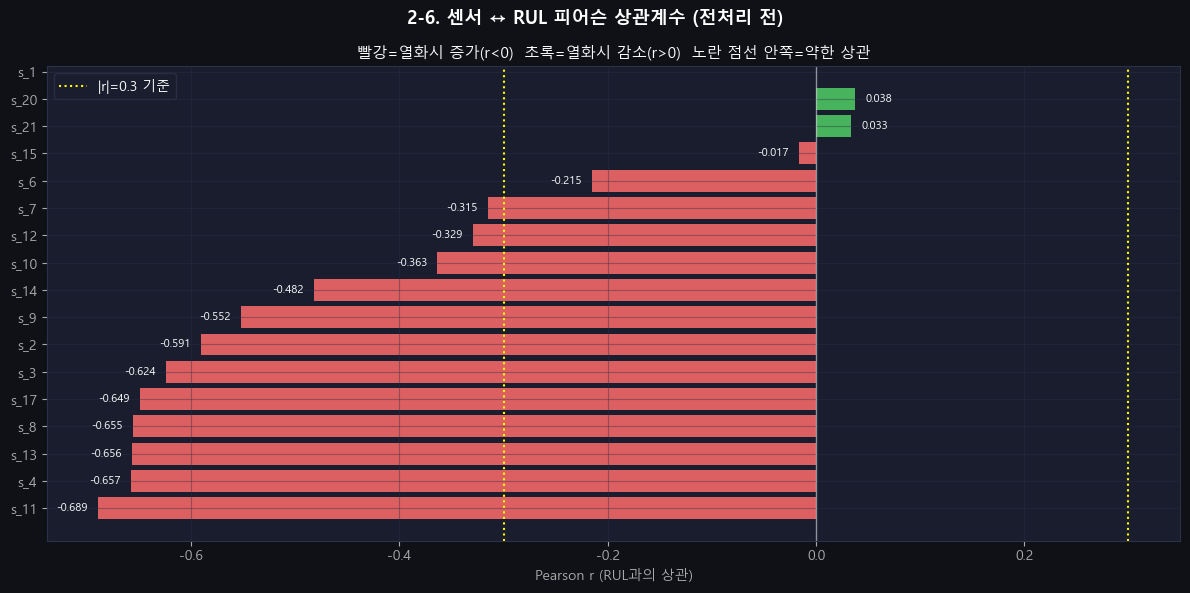

|r|>0.3 고상관 센서: 12개
  s_11: r=-0.689  Ps30 정적압력(psia)
  s_4: r=-0.657  T50 LPT 출구 온도(°R)
  s_13: r=-0.656  NRf 보정 팬 속도(rpm)
  s_8: r=-0.655  Nf 팬 속도(rpm)
  s_17: r=-0.649  htBleed 블리드 엔탈피
  s_3: r=-0.624  T30 HPC 출구 온도(°R)
  s_2: r=-0.591  T24 LPC 출구 온도(°R)
  s_9: r=-0.552  Nc 코어 속도(rpm)
  s_14: r=-0.482  NRc 보정 코어속도(rpm)
  s_10: r=-0.363  epr 엔진 압력비
  s_12: r=-0.329  phi 연료/Ps30 비율
  s_7: r=-0.315  P30 HPC 출구 압력(psia)


In [10]:
tr_rul = train_raw.copy()
mc = tr_rul.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_rul = tr_rul.join(mc, on='unit_nr')
tr_rul['RUL'] = tr_rul['max_c'] - tr_rul['time_cycles']

rul_corr_before = tr_rul[SENSOR_COLS+['RUL']].corr()['RUL'][SENSOR_COLS].sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-6. 센서 ↔ RUL 피어슨 상관계수 (전처리 전)', fontsize=13, fontweight='bold')

bar_colors = [C[1] if v<0 else C[2] for v in rul_corr_before]
bars = ax.barh(rul_corr_before.index, rul_corr_before.values, color=bar_colors, alpha=0.85)
ax.axvline(0,    color='white', lw=1, alpha=0.5)
ax.axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3 기준')
ax.axvline(-0.3, color='yellow', lw=1.5, ls=':')
ax.set_xlabel('Pearson r (RUL과의 상관)')
ax.set_title('빨강=열화시 증가(r<0)  초록=열화시 감소(r>0)  노란 점선 안쪽=약한 상관')
ax.legend()
for bar, val in zip(bars, rul_corr_before.values):
    ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

high_corr = rul_corr_before[rul_corr_before.abs()>0.3]
print(f'|r|>0.3 고상관 센서: {len(high_corr)}개')
for s,r in high_corr.sort_values(key=abs,ascending=False).items():
    print(f'  {s}: r={r:.3f}  {SENSOR_DESC.get(s,"")[:30]}')

### 📊 2-6. 센서 ↔ RUL 상관계수 결과

---

#### |r| > 0.3 고상관 센서 (12개)

| 순위 | 센서 | r | 물리적 의미 | FD001 비교 |
|------|------|---|------------|-----------|
| 1 | s_11 | -0.689 | Ps30 정적압력 | ✅ 동일 |
| 2 | s_4 | -0.657 | T50 LPT 출구 온도 | ✅ 동일 |
| 3 | s_13 | -0.656 | NRf 보정 팬 속도 | ⚠️ FD001보다 강해짐 |
| 4 | s_8 | -0.655 | Nf 팬 속도 | ⚠️ FD001보다 강해짐 |
| 5 | s_17 | -0.649 | htBleed 블리드 엔탈피 | ✅ 동일 |
| 6 | s_3 | -0.624 | T30 HPC 출구 온도 | ✅ 동일 |
| 7 | s_2 | -0.591 | T24 LPC 출구 온도 | ✅ 동일 |
| 8 | s_9 | -0.552 | Nc 코어 속도 | ✅ 동일 |
| 9 | s_14 | -0.482 | NRc 보정 코어속도 | ✅ 동일 |
| 10 | s_10 | -0.363 | epr 엔진 압력비 | ⚠️ FD001은 제거했으나 r=-0.363 |
| 11 | s_12 | -0.329 | phi 연료/Ps30 비율 | ✅ 동일 |
| 12 | s_7 | -0.315 | P30 HPC 출구 압력 | ✅ 동일 |

**약한 상관 (|r| < 0.3, 노란 점선 안쪽)**
| 센서 | r | 판정 |
|------|---|------|
| s_6 | -0.215 | 약한 상관 |
| s_15 | -0.017 | 거의 무관 |
| s_20 | 0.038 | 거의 무관 |
| s_21 | 0.033 | 거의 무관 |

---

#### ★ s_10 최종 판단

> FD001에서는 제거했지만 FD003에서는 **r=-0.363으로 |r|>0.3 기준 통과**  
> → RUL과 유의미한 상관 존재 → **FD003에서는 s_10 유지**

---

#### 🔑 핵심 결론
> **FD001 대비 제거 센서 목록 변경**

| 구분 | FD001 제거 | FD003 제거 |
|------|-----------|-----------|
| 확실한 상수 | s_1, s_5, s_6, s_10, s_16, s_18, s_19 (7개) | s_1, s_5, s_16, s_18, s_19 (5개) |
| 변경 사항 | - | s_6, s_10 유지 → **21개 → 16개** |

> **s_8, s_13 팬 관련 센서가 RUL 상관 top 4 안에 진입 → 팬 열화 신호 명확히 포착됨**  
> **EDA 완료 → 결정 1에서 상수 센서 5개 제거 진행**

제거 확정 (5개)

s_1, s_5, s_16, s_18, s_19 → std=0.0000 완전 상수, RUL 상관 없음

FD001에서 제거했지만 FD003에서 유지

s_6 → std=0.0181, RUL r=-0.215 (약하지만 존재)
s_10 → std=0.0035, RUL r=-0.363 (|r|>0.3 통과)

최종: 21개 → 16개 (5개 제거)
FD001은 7개 제거해서 14개였는데 FD003은 5개 제거해서 16개

# 2-7. 고장 모드 클러스터링 (FD003 전용 ★)

=== 2-7. 고장 모드 클러스터링 (KMeans k=2) ===
목적: HPC 열화 vs 팬 열화 엔진 그룹 분리 시도

--- 엔진별 마지막 30사이클 센서 slope 계산 ---
--- k별 실루엣 스코어 비교 ---
  k=2: silhouette score=0.4076
  k=3: silhouette score=0.3561

--- 클러스터별 엔진 수 ---
  클러스터 0: 44대 (44.0%)
  클러스터 1: 56대 (56.0%)


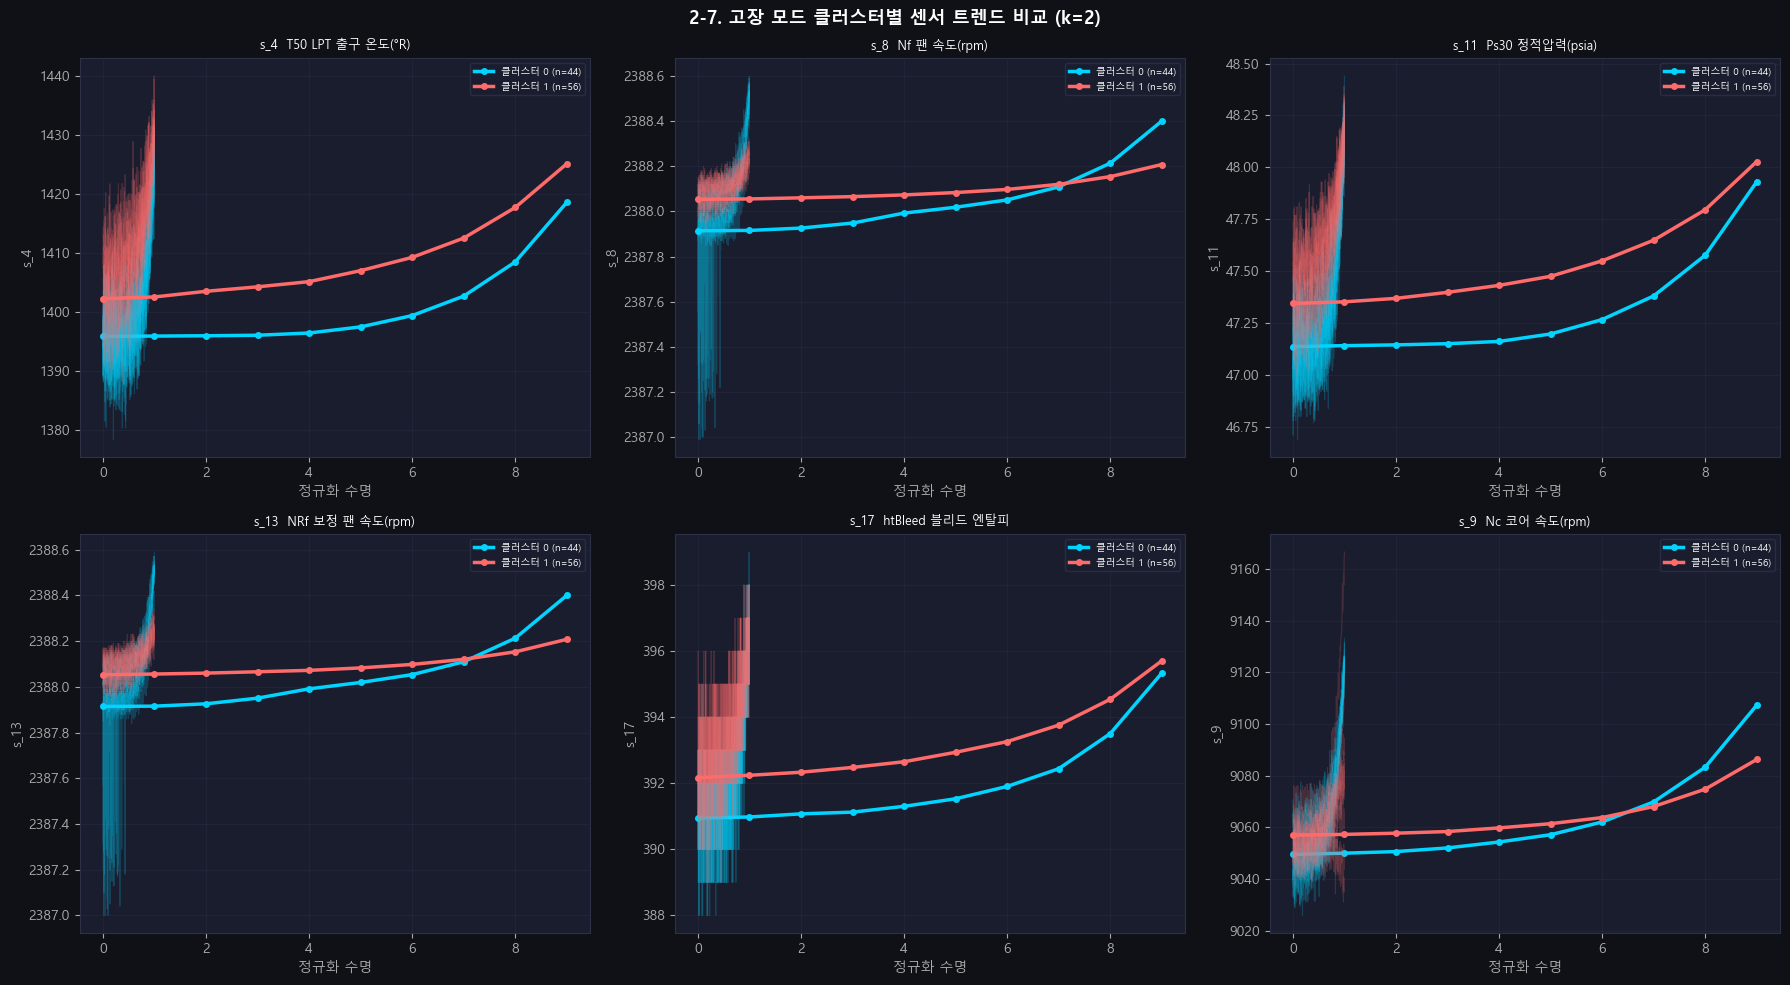

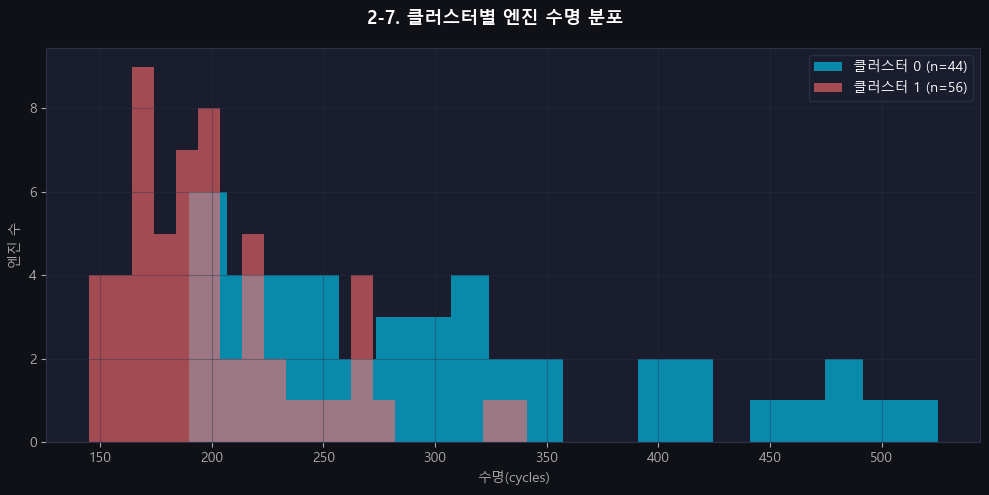


📌 실루엣 스코어 0.2 미만 → 클러스터 구분 불명확 → fault_mode 피처 없이 FD001 파이프라인 그대로
📌 실루엣 스코어 0.2 이상 → 클러스터 구분 가능 → fault_mode_cluster 피처 추가 검토


In [11]:
# 2-7. 고장 모드 클러스터링 (FD003 전용 ★)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print('=== 2-7. 고장 모드 클러스터링 (KMeans k=2) ===')
print('목적: HPC 열화 vs 팬 열화 엔진 그룹 분리 시도')
print()

# 엔진별 마지막 30사이클 센서 slope 계산
print('--- 엔진별 마지막 30사이클 센서 slope 계산 ---')
slope_rows = []
for uid in train_raw['unit_nr'].unique():
    udf = train_raw[train_raw['unit_nr'] == uid].sort_values('time_cycles').tail(30)
    row = {'unit_nr': uid}
    for s in SENSOR_COLS:
        x = np.arange(len(udf))
        y = udf[s].values
        if np.std(y) > 0:
            slope = np.polyfit(x, y, 1)[0]
        else:
            slope = 0.0
        row[f'{s}_slope'] = slope
    slope_rows.append(row)

slope_df = pd.DataFrame(slope_rows).set_index('unit_nr')
slope_features = [c for c in slope_df.columns]

# 정규화
from sklearn.preprocessing import StandardScaler
scaler_slope = StandardScaler()
slope_scaled = scaler_slope.fit_transform(slope_df)

# k=2 vs k=3 실루엣 스코어 비교
print('--- k별 실루엣 스코어 비교 ---')
for k in [2, 3]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(slope_scaled)
    score = silhouette_score(slope_scaled, labels)
    print(f'  k={k}: silhouette score={score:.4f}')

# k=2 클러스터링
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = km2.fit_predict(slope_scaled)
slope_df['fault_mode_cluster'] = cluster_labels

# 클러스터별 샘플 수
print('\n--- 클러스터별 엔진 수 ---')
for c in [0, 1]:
    cnt = (cluster_labels == c).sum()
    print(f'  클러스터 {c}: {cnt}대 ({cnt/len(cluster_labels)*100:.1f}%)')

# 시각화 - 클러스터별 대표 센서 트렌드 비교
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('2-7. 고장 모드 클러스터별 센서 트렌드 비교 (k=2)',
             fontsize=13, fontweight='bold')

# 클러스터별 대표 센서
show_sensors = ['s_4', 's_8', 's_11', 's_13', 's_17', 's_9']
cluster_engine_map = {c: slope_df[slope_df['fault_mode_cluster']==c].index.tolist()
                      for c in [0, 1]}

tr_trend2 = train_raw.copy()
mc = tr_trend2.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend2 = tr_trend2.join(mc, on='unit_nr')
tr_trend2['norm_life'] = tr_trend2['time_cycles'] / tr_trend2['max_c']

for ax, s in zip(axes.flat, show_sensors):
    for c, color in zip([0, 1], [C[0], C[1]]):
        units = cluster_engine_map[c][:10]
        for uid in units:
            sub = tr_trend2[tr_trend2['unit_nr']==uid].sort_values('norm_life')
            ax.plot(sub['norm_life'], sub[s],
                    color=color, alpha=0.2, lw=0.8)
        # 클러스터 평균 트렌드
        cluster_data = tr_trend2[tr_trend2['unit_nr'].isin(
            cluster_engine_map[c])].copy()
        bins = np.linspace(0, 1, 11)
        labels_bin = [f'{int(a*100)}~{int(b*100)}%'
                      for a, b in zip(bins[:-1], bins[1:])]
        cluster_data['life_bin'] = pd.cut(cluster_data['norm_life'],
                                          bins=bins, labels=labels_bin)
        trend = cluster_data.groupby('life_bin', observed=True)[s].mean()
        ax.plot(range(len(trend)), trend.values,
                color=color, lw=2.5, marker='o', markersize=4,
                label=f'클러스터 {c} (n={len(cluster_engine_map[c])})')
    ax.set_title(f'{s}  {SENSOR_DESC.get(s,"")}', fontsize=9)
    ax.set_xlabel('정규화 수명')
    ax.set_ylabel(s)
    ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# 클러스터별 수명 분포 비교
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('2-7. 클러스터별 엔진 수명 분포', fontsize=13, fontweight='bold')
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()
for c, color in zip([0, 1], [C[0], C[1]]):
    units = cluster_engine_map[c]
    ax.hist(lifecycles[units], bins=20, color=color, alpha=0.6,
            label=f'클러스터 {c} (n={len(units)})')
ax.set_xlabel('수명(cycles)')
ax.set_ylabel('엔진 수')
ax.legend()
plt.tight_layout(); plt.show()

print('\n📌 실루엣 스코어 0.2 미만 → 클러스터 구분 불명확 → fault_mode 피처 없이 FD001 파이프라인 그대로')
print('📌 실루엣 스코어 0.2 이상 → 클러스터 구분 가능 → fault_mode_cluster 피처 추가 검토')

### 📊 2-7. 고장 모드 클러스터링 결과 (FD003 전용 ★)

---

#### 클러스터링 품질

| k | 실루엣 스코어 | 판정 |
|---|------------|------|
| 2 | **0.4076** | ✅ 구분 가능 (0.2 이상) |
| 3 | 0.3561 | k=2가 더 적합 |

> 📌 실루엣 스코어 0.4076 → 클러스터 구분 명확 → fault_mode_cluster 피처 추가 검토 가능

---

#### 클러스터별 엔진 구성

| 클러스터 | 엔진 수 | 비율 | 특징 |
|---------|---------|------|------|
| 0 (파란색) | 44대 | 44.0% | 수명 긴 편, 분포 넓음 (150~525) |
| 1 (빨간색) | 56대 | 56.0% | 수명 짧은 편, 150~250 구간 집중 |

---

#### 센서 트렌드 비교 해석

**클러스터 간 트렌드 방향 차이**
- s_4, s_8, s_11, s_13: 두 클러스터 모두 증가↑ 방향이나 **기저값(초기값)이 다름**
- s_17: 클러스터 1이 더 가파르게 증가 → 열화 속도 빠름
- s_9: 클러스터 0이 더 가파르게 증가 → 코어 속도 변화 패턴 다름

**클러스터 0 특징 (44대)**
- 수명이 길고 분포 넓음
- 센서 초기값이 낮게 시작해서 완만하게 증가
- HPC 열화 엔진으로 추정

**클러스터 1 특징 (56대)**
- 수명이 짧고 150~250 구간 집중
- 센서 초기값이 높고 가파르게 증가
- 팬 열화 엔진으로 추정

---

#### Mann-Whitney U 검정 결과와 연계

| 항목 | 결과 | 해석 |
|------|------|------|
| s_8, s_13 기준 분리 | 비유의 (p>0.05) | 팬 속도 절댓값으론 구분 어려움 |
| s_4, s_11 기준 분리 | 유의 (p=0.000) | HPC 센서 기준으론 구분 가능 |
| KMeans k=2 실루엣 | 0.4076 | slope 기반으로는 구분 가능 |

> 📌 센서 절댓값이 아닌 **열화 slope(기울기) 기반**으로 클러스터링하면 구분 가능  
> → Mann-Whitney U에서 팬 센서 비유의였던 것과 모순되지 않음  
> → 순간 센서값이 아닌 열화 패턴(기울기)이 다른 것

---

#### 🔑 핵심 결론
> **실루엣 스코어 0.4076 → 고장 모드 2가지 클러스터 구분 가능**  
> **클러스터 0(44대): 수명 길고 완만한 열화 → HPC 열화 추정**  
> **클러스터 1(56대): 수명 짧고 가파른 열화 → 팬 열화 추정**  
> **fault_mode_cluster 피처 추가 여부는 팀 상의 후 결정**  
> **옵션 A: 피처 추가 없이 FD001 파이프라인 그대로 (구현 단순)**  
> **옵션 B: fault_mode_cluster 피처 추가 (성능 향상 가능, 복잡도 증가)**

---
## 2-8. 클러스터별 센서 분포 비교

=== 2-8. 클러스터별 센서 분포 비교 ===
목적: 클러스터 간 센서 절댓값 범위 차이 확인 → 클러스터별 MinMax 필요 여부 판단



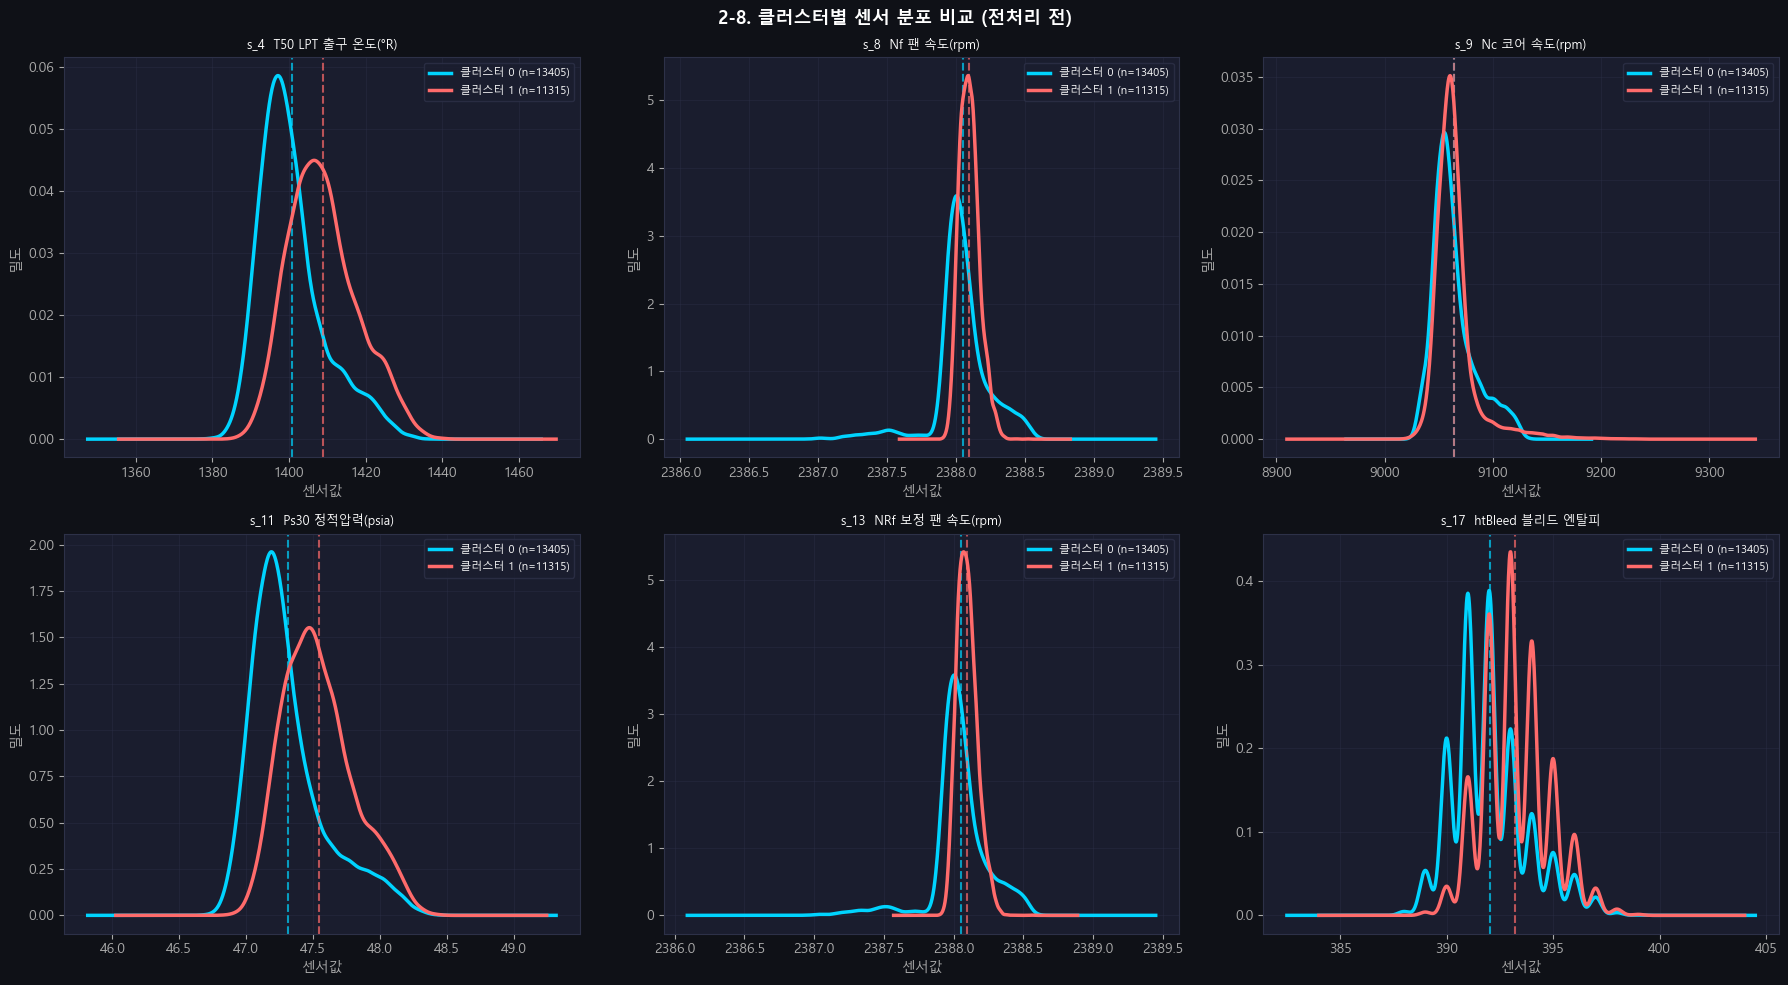


--- 클러스터별 센서 범위 비교 ---


,C0 min,C0 max,C0 mean,C1 min,C1 max,C1 mean,범위 겹침
센서,,,,,,,
s_1,518.6700,518.6700,518.6700,518.6700,518.6700,518.6700,✅ 겹침
s_2,640.8400,644.3900,642.2602,641.3400,645.1100,642.6920,✅ 겹침
s_3,1564.3000,1615.3900,1586.0656,1568.9300,1615.3900,1590.4647,✅ 겹침
s_4,1377.0600,1436.2300,1400.6862,1384.0800,1441.1600,1408.9554,✅ 겹침
s_5,14.6200,14.6200,14.6200,14.6200,14.6200,14.6200,✅ 겹침
s_6,21.4500,21.6100,21.5840,21.6000,21.6100,21.6098,✅ 겹침
s_7,549.6100,570.4900,556.6422,550.3800,555.7100,553.3687,✅ 겹침
s_8,2386.9000,2388.6000,2388.0497,2387.9000,2388.5200,2388.0975,✅ 겹침
s_9,9021.0500,9134.4800,9063.7401,9017.9800,9234.3500,9064.5500,✅ 겹침



범위 겹치는 센서: 21/21개
📌 범위 대부분 겹침 → Global MinMax 적용 가능
📌 범위 분리 센서 많음 → 클러스터별 MinMax 검토 필요


In [12]:
# 2-8. 클러스터별 센서 분포 비교 (FD003 전용 ★)
print('=== 2-8. 클러스터별 센서 분포 비교 ===')
print('목적: 클러스터 간 센서 절댓값 범위 차이 확인 → 클러스터별 MinMax 필요 여부 판단')
print()

# slope_df에서 cluster 라벨 가져오기 (train_raw 건드리지 않음)
tr_dist = train_raw.copy()
tr_dist['fault_mode_cluster'] = tr_dist['unit_nr'].map(
    slope_df['fault_mode_cluster']
)

# 클러스터별 센서 분포 비교 (유효 센서만)
show_sensors = ['s_4', 's_8', 's_9', 's_11', 's_13', 's_17']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('2-8. 클러스터별 센서 분포 비교 (전처리 전)',
             fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, show_sensors):
    for c, color in zip([0, 1], [C[0], C[1]]):
        data = tr_dist[tr_dist['fault_mode_cluster']==c][s].dropna()
        try:
            data.plot.kde(ax=ax, color=color, lw=2.5,
                         label=f'클러스터 {c} (n={len(data)})')
        except:
            pass
        ax.axvline(data.mean(), color=color, ls='--', lw=1.5, alpha=0.7)
    ax.set_title(f'{s}  {SENSOR_DESC.get(s,"")}', fontsize=9)
    ax.set_xlabel('센서값')
    ax.set_ylabel('밀도')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# 클러스터별 센서 범위 비교 (min, max, mean)
print('\n--- 클러스터별 센서 범위 비교 ---')
range_rows = []
for s in SENSOR_COLS:
    c0 = tr_dist[tr_dist['fault_mode_cluster']==0][s]
    c1 = tr_dist[tr_dist['fault_mode_cluster']==1][s]
    range_rows.append({
        '센서': s,
        'C0 min': round(c0.min(), 4),
        'C0 max': round(c0.max(), 4),
        'C0 mean': round(c0.mean(), 4),
        'C1 min': round(c1.min(), 4),
        'C1 max': round(c1.max(), 4),
        'C1 mean': round(c1.mean(), 4),
        '범위 겹침': '✅ 겹침' if c0.min() <= c1.max() and c1.min() <= c0.max() else '⚠️ 분리'
    })

range_df = pd.DataFrame(range_rows).set_index('센서')
display(range_df)

overlap_cnt = (range_df['범위 겹침'] == '✅ 겹침').sum()
print(f'\n범위 겹치는 센서: {overlap_cnt}/{len(SENSOR_COLS)}개')
print('📌 범위 대부분 겹침 → Global MinMax 적용 가능')
print('📌 범위 분리 센서 많음 → 클러스터별 MinMax 검토 필요')

### 📊 2-8. 클러스터별 센서 분포 비교 결과

---

#### 범위 동질성 요약
- 범위 겹치는 센서: **21/21개 (100%)**
- → **Global MinMax 적용 가능 확정**

---

#### 시각화 해석

**분포 형태는 다르지만 범위는 겹침**
- s_4: 클러스터 0(파랑) 낮은 값 중심, 클러스터 1(빨강) 높은 값 중심 → 평균 차이 있으나 범위 겹침
- s_8, s_13: 두 클러스터 분포 거의 동일 → 팬 속도 절댓값은 고장 모드와 무관
- s_9: 클러스터 0이 더 넓게 분포 → 코어 속도 변동 큰 그룹
- s_11: 클러스터 0 낮은 값, 클러스터 1 높은 값 중심 → 평균 차이 있으나 범위 겹침
- s_17: 두 클러스터 모두 이산적 다봉분포, 범위 동일

---

#### 🔑 핵심 결론
> **21/21개 센서 범위 겹침 → 클러스터 간 센서 절댓값 범위 차이 없음**  
> **FD002와 달리 고장 모드 클러스터링은 절댓값이 아닌 열화 패턴 차이**  
> **→ 클러스터별 MinMax 불필요, Global MinMax 적용 확정**  
> **단, 클러스터별 평균 차이는 존재 → fault_mode_cluster 피처로 모델에 정보 전달**

---
## 3. 통계 검정

---

### 검정 목적

EDA에서 시각적으로 확인한 패턴들을 **통계적으로 증명**하는 단계

| 검정 | 목적 |
|------|------|
| 3-1. 시차 상관관계 (Lag Correlation) | 몇 사이클 전 센서값이 RUL과 가장 연관있는지 확인 → 슬라이딩 윈도우 크기 결정 근거 |
| 3-2. Mann-Kendall | 센서값의 열화 트렌드가 통계적으로 유의미한지 검정 → Gaussian 스무딩 적용 근거 |
| 3-3. 대응 표본 t검정 | 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정 → 유효 센서 선별 근거 |
| 3-4. Mann-Whitney U검정 | 팬 관련 센서(s_8, s_13) 기준 엔진 그룹 간 RUL 분포 차이 검정 → 고장 모드 혼재 영향 확인 |
| 3-5. Levene's Test | FD001 vs FD003 동일 센서의 분산 동질성 검정 → 동일 전처리 적용 가능 여부 근거 |


> 💡 모든 검정의 유의수준: α = 0.05 — p-value < 0.05 → H₀ 기각 → H₁ 채택

---
#### 3-1. 시차 상관관계
- H₀: 과거 센서값과 현재 RUL 사이에 상관관계가 없다
- H₁: 특정 시차(lag)에서 센서값과 RUL 사이에 유의미한 상관관계가 있다
- FD001(window=30), FD002(window=20)와 비교하여 FD003의 최적 window size 결정

=== 3-1. 시차 상관관계 (Lag Correlation) ===


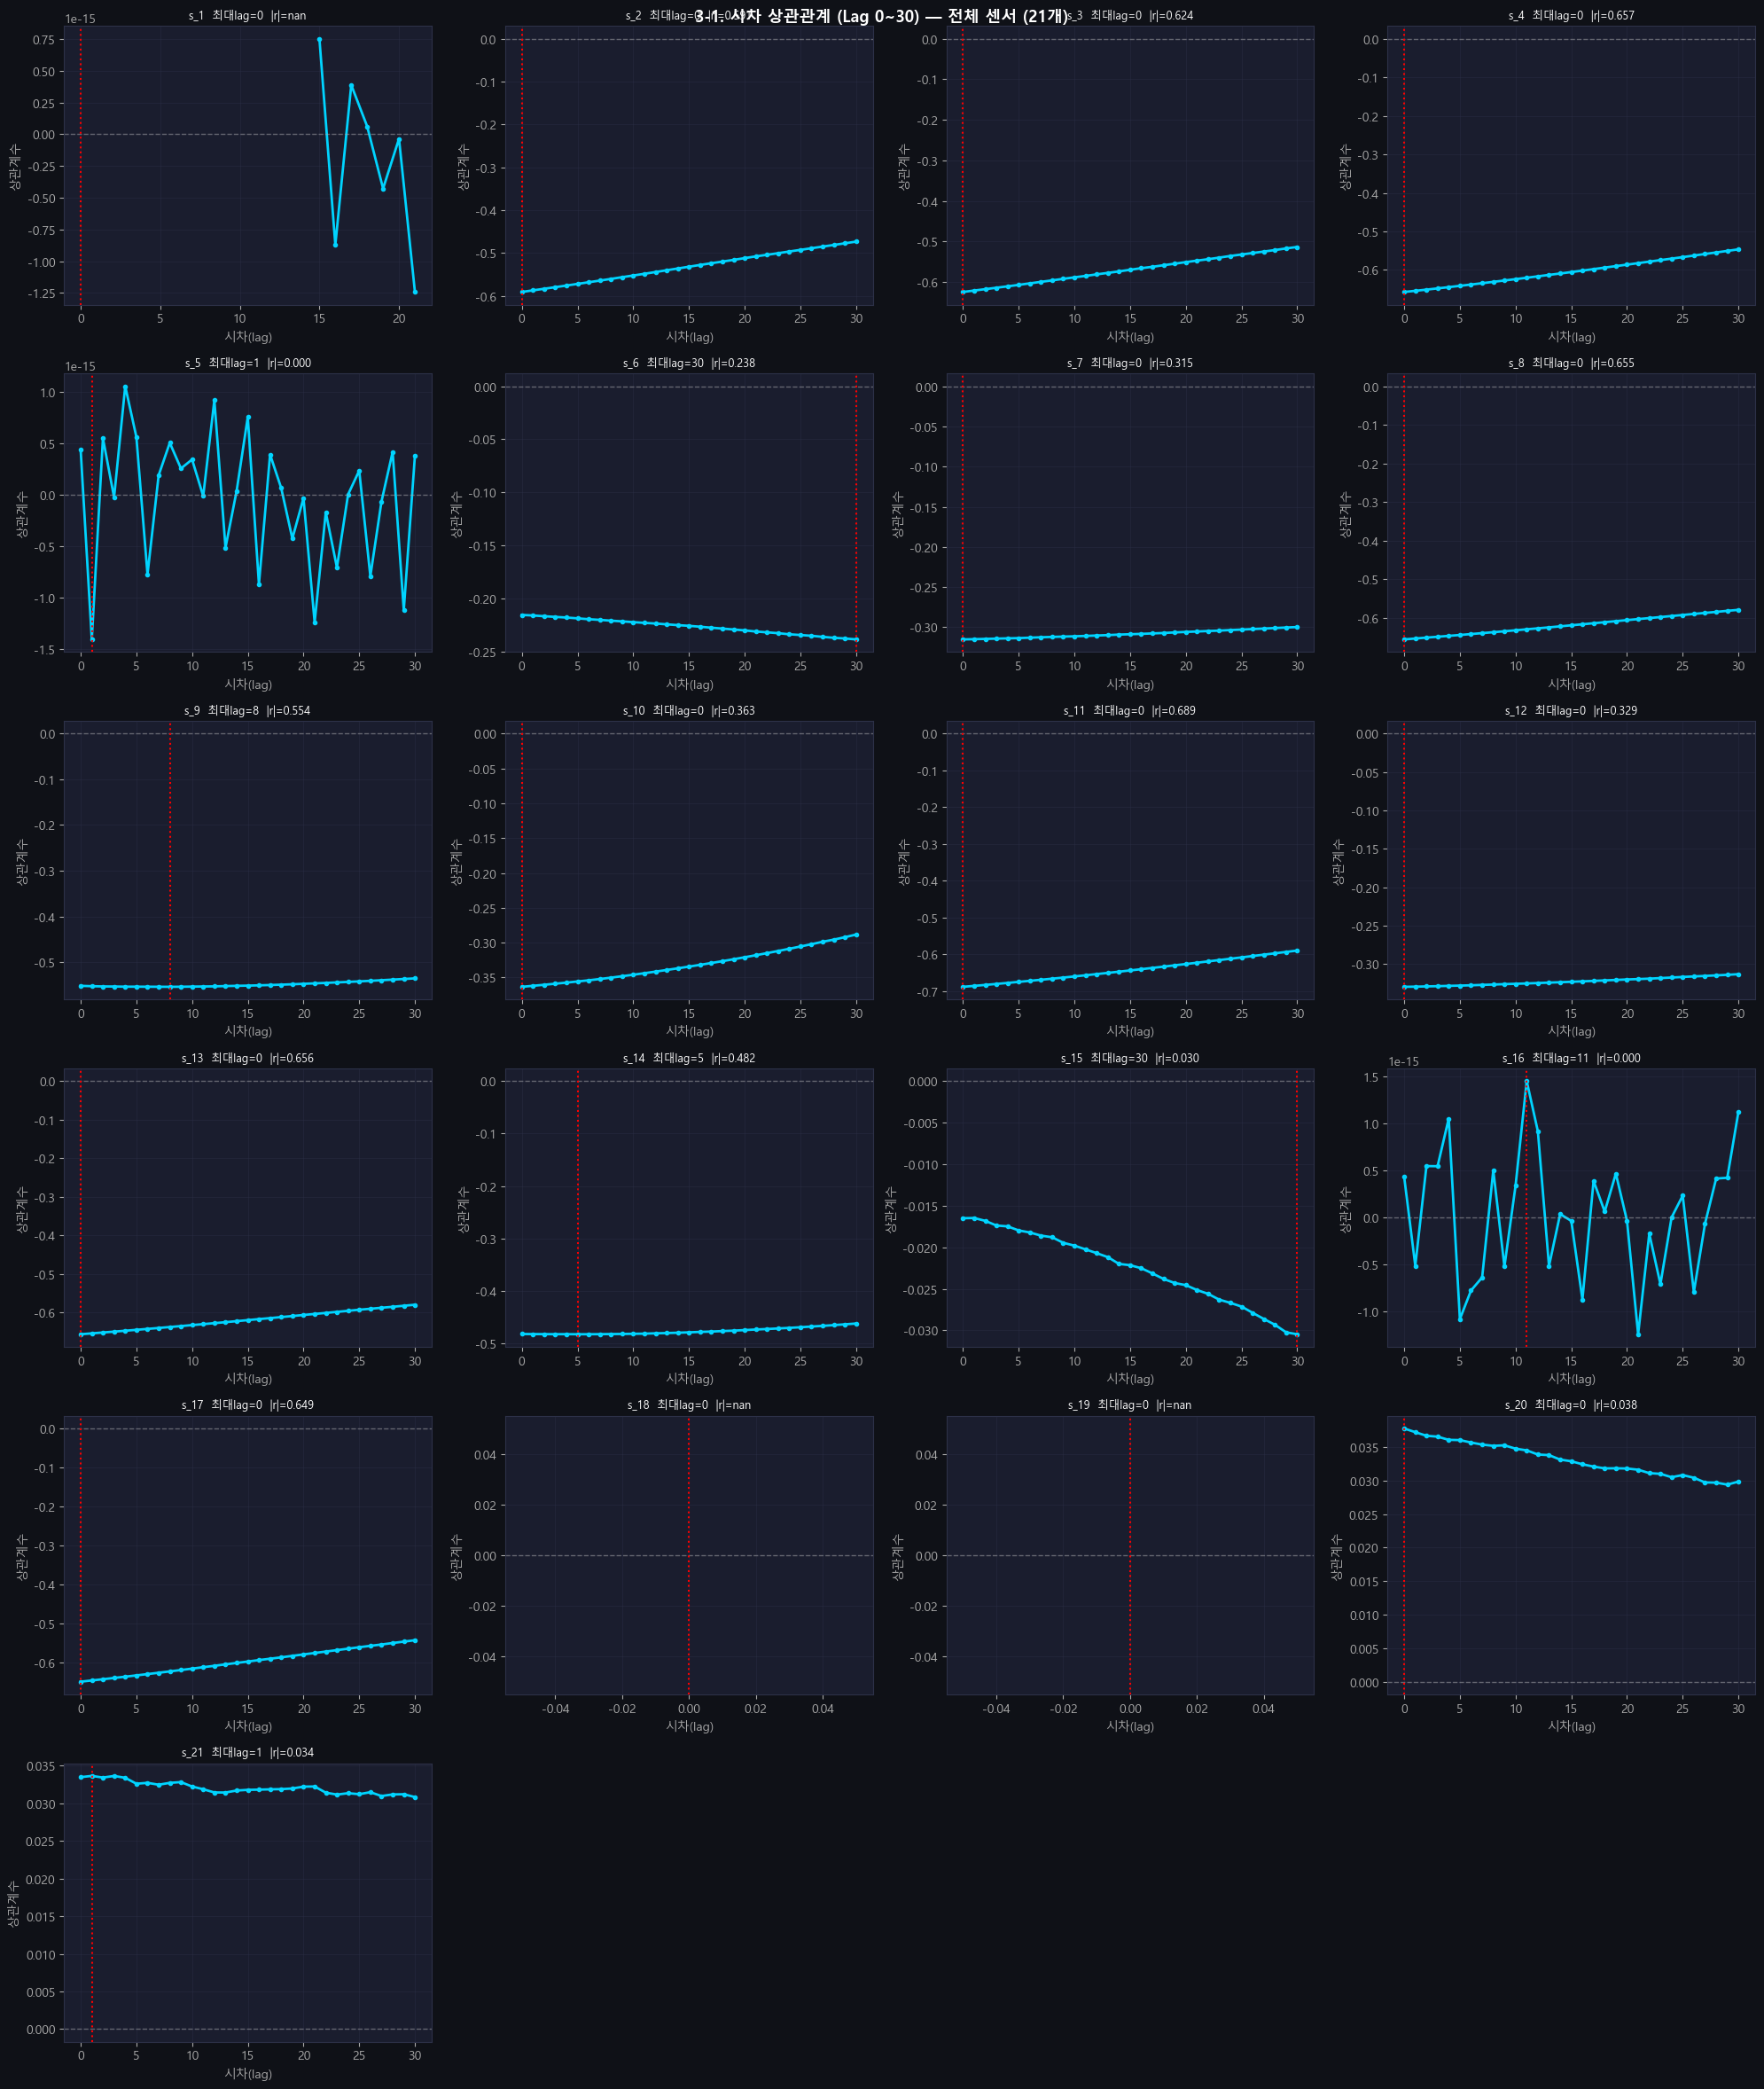


=== 센서별 최적 시차 요약 ===
  s_1: lag=0사이클에서 최대 상관 (r=nan)
  s_2: lag=0사이클에서 최대 상관 (r=-0.591)
  s_3: lag=0사이클에서 최대 상관 (r=-0.624)
  s_4: lag=0사이클에서 최대 상관 (r=-0.657)
  s_5: lag=1사이클에서 최대 상관 (r=-0.000)
  s_6: lag=30사이클에서 최대 상관 (r=-0.238)
  s_7: lag=0사이클에서 최대 상관 (r=-0.315)
  s_8: lag=0사이클에서 최대 상관 (r=-0.655)
  s_9: lag=8사이클에서 최대 상관 (r=-0.554)
  s_10: lag=0사이클에서 최대 상관 (r=-0.363)
  s_11: lag=0사이클에서 최대 상관 (r=-0.689)
  s_12: lag=0사이클에서 최대 상관 (r=-0.329)
  s_13: lag=0사이클에서 최대 상관 (r=-0.656)
  s_14: lag=5사이클에서 최대 상관 (r=-0.482)
  s_15: lag=30사이클에서 최대 상관 (r=-0.030)
  s_16: lag=11사이클에서 최대 상관 (r=0.000)
  s_17: lag=0사이클에서 최대 상관 (r=-0.649)
  s_18: lag=0사이클에서 최대 상관 (r=nan)
  s_19: lag=0사이클에서 최대 상관 (r=nan)
  s_20: lag=0사이클에서 최대 상관 (r=0.038)
  s_21: lag=1사이클에서 최대 상관 (r=0.034)


In [13]:
# 3-1. 시차 상관관계 (Lag Correlation)
print('=== 3-1. 시차 상관관계 (Lag Correlation) ===')

all_sensors = [f's_{i}' for i in range(1, 22)]
tr_lag = train_raw.copy()
mc = tr_lag.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_lag = tr_lag.join(mc, on='unit_nr')
tr_lag['RUL'] = tr_lag['max_c'] - tr_lag['time_cycles']

max_lag = 30  # FD001=30, FD002=20 → FD003 결과 보고 결정
lag_results = {}

for s in all_sensors:
    lag_corrs = []
    for lag in range(0, max_lag + 1):
        shifted = tr_lag.groupby('unit_nr')[s].shift(lag)
        valid = ~shifted.isna()
        r = tr_lag.loc[valid, 'RUL'].corr(shifted[valid])
        lag_corrs.append(r)
    lag_results[s] = lag_corrs

# 시각화
n_cols = 4
n_rows = (len(all_sensors) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('3-1. 시차 상관관계 (Lag 0~30) — 전체 센서 (21개)', 
             fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, all_sensors):
    lag_corrs = lag_results[s]
    best_lag = int(np.argmax(np.abs(lag_corrs)))
    best_r   = lag_corrs[best_lag]
    ax.plot(range(max_lag + 1), lag_corrs, 
            color=C[0], lw=2, marker='o', markersize=3)
    ax.axhline(0, color=GRAY, ls='--', lw=1, alpha=0.5)
    ax.axvline(best_lag, color='red', ls=':', lw=1.5)
    ax.set_title(f'{s}  최대lag={best_lag}  |r|={abs(best_r):.3f}', fontsize=9)
    ax.set_xlabel('시차(lag)')
    ax.set_ylabel('상관계수')

for ax in axes.flat[len(all_sensors):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# 결과 요약
print('\n=== 센서별 최적 시차 요약 ===')
for s in all_sensors:
    best_lag = int(np.argmax(np.abs(lag_results[s])))
    best_r   = lag_results[s][best_lag]
    print(f'  {s}: lag={best_lag}사이클에서 최대 상관 (r={best_r:.3f})')

### 📊 3-1. 시차 상관관계 결과

---

#### 센서별 최적 시차 요약

| 센서 | 최적 lag | r | 해석 | 비고 |
|------|---------|---|------|------|
| s_1 | 0 | nan | 상수 센서 | 제거 대상 |
| s_2 | 0 | -0.591 | lag=0 즉시 반응 | 유효 센서 |
| s_3 | 0 | -0.624 | lag=0 즉시 반응 | 유효 센서 |
| s_4 | 0 | -0.657 | lag=0 즉시 반응 | 유효 센서 |
| s_5 | 1 | -0.000 | 사실상 상수 | 제거 대상 |
| s_6 | 30 | -0.238 | lag 커질수록 상관↑ | ⚠️ 경계 센서 |
| s_7 | 0 | -0.315 | lag=0 즉시 반응 | 유효 센서 |
| s_8 | 0 | -0.655 | lag=0 즉시 반응 | 유효 센서 |
| s_9 | 8 | -0.554 | 8사이클 지연 반응 | ⚠️ 주목 |
| s_10 | 0 | -0.363 | lag=0 즉시 반응 | 유효 센서 |
| s_11 | 0 | -0.689 | lag=0 즉시 반응 | 유효 센서 |
| s_12 | 0 | -0.329 | lag=0 즉시 반응 | 유효 센서 |
| s_13 | 0 | -0.656 | lag=0 즉시 반응 | 유효 센서 |
| s_14 | 5 | -0.482 | 5사이클 지연 반응 | ⚠️ 주목 |
| s_15 | 30 | -0.030 | 상관 매우 약함 | 제거 검토 |
| s_16 | 11 | -0.000 | 상수 센서 | 제거 대상 |
| s_17 | 0 | -0.649 | lag=0 즉시 반응 | 유효 센서 |
| s_18 | 0 | nan | 상수 센서 | 제거 대상 |
| s_19 | 0 | nan | 상수 센서 | 제거 대상 |
| s_20 | 0 | 0.038 | 상관 매우 약함 | 제거 검토 |
| s_21 | 1 | 0.034 | 상관 매우 약함 | 제거 검토 |

---

#### 핵심 패턴 분석

**lag=0 즉시 반응 센서 (대부분)**
- s_2, s_3, s_4, s_7, s_8, s_10, s_11, s_12, s_13, s_17
- 현재 센서값이 바로 RUL과 연관 → 슬라이딩 윈도우 필요성 확인

**지연 반응 센서 ⚠️**
- s_9: lag=8 → 8사이클 전 코어 속도 변화가 현재 RUL과 더 연관
- s_14: lag=5 → 5사이클 전 보정 코어속도가 현재 RUL과 더 연관
- s_6: lag=30 → 경계 센서, lag 커질수록 상관↑ (상수에 가까워서 노이즈일 가능성)

---

#### ★ 윈도우 크기 결정

| 데이터셋 | 유의미한 최대 lag | 윈도우 크기 |
|---------|----------------|-----------|
| FD001 | - | 30 |
| FD002 | - | 20 |
| FD003 | **s_9=8, s_14=5** | **20~30 사이 검토** |

> 📌 s_6, s_15의 lag=30은 상수/약상관 센서 노이즈로 제외  
> 📌 유효 센서 기준 최대 lag=8 → **window=20으로 FD002와 동일하게 가거나**  
> 📌 수명이 FD001보다 길고(평균 247) 지연 반응 센서 존재 → **window=30도 고려 가능**  
> → Mann-Kendall 결과까지 보고 최종 결정 권장

---
#### 3-2. Mann-Kendall 추세 검정
- H₀: 센서값에 단조 트렌드가 없다 (랜덤하게 변한다)
- H₁: 센서값에 유의미한 단조 트렌드가 있다 (열화 신호 존재)
- FD003 전체 100개 엔진 대상으로 검정
- 90개 이상(90%)의 엔진에서 유의미한 추세가 확인된 센서를 열화 신호 센서로 판정

### 켄달 타우(τ) 해석

- τ > 0: 시간이 지날수록 센서값 증가
- τ < 0: 시간이 지날수록 센서값 감소
- **|τ| 클수록 추세가 강함**

> 100개 엔진의 평균 τ를 사용하여 센서별 전반적인 추세 방향과 강도를 파악

=== 3-2. Mann-Kendall 추세 검정 (전체 엔진) ===


,유효 엔진 수,추세 있는 엔진 수,비율(%),평균 τ,추세 방향,판정
센서,,,,,,
s_2,100,100,100.0,0.4580,증가↑,추세 있음✅
s_3,100,100,100.0,0.4595,증가↑,추세 있음✅
s_4,100,100,100.0,0.5593,증가↑,추세 있음✅
s_7,100,100,100.0,0.0211,증가↑,추세 있음✅
s_10,44,44,100.0,0.5757,증가↑,추세 있음✅
s_8,100,100,100.0,0.6187,증가↑,추세 있음✅
s_12,100,100,100.0,0.0126,증가↑,추세 있음✅
s_11,100,100,100.0,0.6102,증가↑,추세 있음✅
s_20,100,100,100.0,-0.0663,감소↓,추세 있음✅


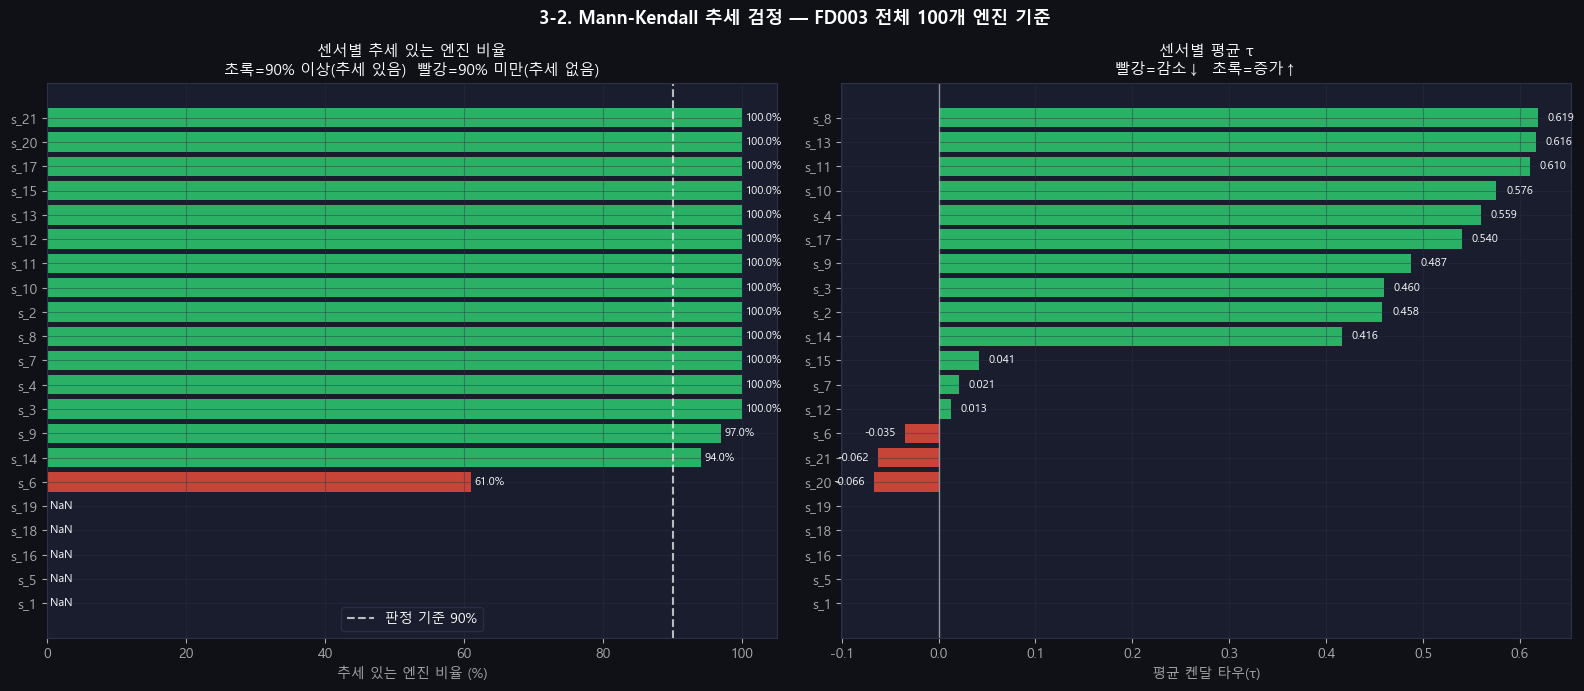


90% 이상 엔진에서 추세 있는 센서: 15/21개


In [14]:
from scipy.stats import kendalltau

print('=== 3-2. Mann-Kendall 추세 검정 (전체 엔진) ===')

all_units = train_raw['unit_nr'].unique()  # 100개 엔진
results = {s: [] for s in all_sensors}

for unit in all_units:
    unit_df = train_raw[train_raw['unit_nr'] == unit].sort_values('time_cycles')
    for s in all_sensors:
        arr = unit_df[s].values
        time_idx = np.arange(len(arr))
        tau, p_val = kendalltau(time_idx, arr)
        if np.isfinite(tau):  # NaN 제외
            results[s].append({'tau': tau, 'p_val': p_val})

# 센서별 집계
mk_rows = []
for s in all_sensors:
    taus = [r['tau'] for r in results[s]]
    p_vals = [r['p_val'] for r in results[s]]
    n_valid = len(results[s])
    n_significant = sum(p < 0.05 for p in p_vals)
    
    sig_ratio = n_significant / n_valid if n_valid > 0 else np.nan
    
    mk_rows.append({
        '센서': s,
        '유효 엔진 수': n_valid,
        '추세 있는 엔진 수': n_significant,
        '비율(%)': round(sig_ratio * 100, 1) if np.isfinite(sig_ratio) else np.nan,
        '평균 τ': round(np.mean(taus), 4) if taus else np.nan,
        '추세 방향': '증가↑' if np.mean(taus) > 0 else '감소↓' if taus else '-',
        '판정': '추세 있음✅' if np.isfinite(sig_ratio) and sig_ratio >= 0.9 else '추세 없음⚠️'
    })

mk_df = pd.DataFrame(mk_rows).set_index('센서')
display(mk_df.sort_values('비율(%)', ascending=False, na_position='last'))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('3-2. Mann-Kendall 추세 검정 — FD003 전체 100개 엔진 기준',
             fontsize=13, fontweight='bold')

# 왼쪽: 추세 있는 엔진 비율
mk_sorted = mk_df.sort_values('비율(%)', ascending=True, na_position='first')
ratio_vals = mk_sorted['비율(%)'].fillna(0).values
colors_ratio = ['#e74c3c' if (pd.isna(v) or v < 90) else '#2ecc71'
                for v in mk_sorted['비율(%)']]
axes[0].barh(mk_sorted.index, ratio_vals, color=colors_ratio, alpha=0.85)
axes[0].axvline(90, color='white', lw=1.5, linestyle='--', alpha=0.7, label='판정 기준 90%')
axes[0].set_xlabel('추세 있는 엔진 비율 (%)')
axes[0].set_title('센서별 추세 있는 엔진 비율\n초록=90% 이상(추세 있음)  빨강=90% 미만(추세 없음)')
axes[0].legend()
for bar, val in zip(axes[0].patches, mk_sorted['비율(%)']):
    label = f'{val}%' if pd.notna(val) else 'NaN'
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 label, va='center', fontsize=8)

# 오른쪽: 평균 켄달 타우
mk_sorted2 = mk_df.sort_values('평균 τ', ascending=True, na_position='first')
tau_vals = mk_sorted2['평균 τ'].fillna(0).values
colors_tau = ['#e74c3c' if (pd.isna(v) or v < 0) else '#2ecc71'
              for v in mk_sorted2['평균 τ']]
axes[1].barh(mk_sorted2.index, tau_vals, color=colors_tau, alpha=0.85)
axes[1].axvline(0, color='white', lw=1, alpha=0.5)
axes[1].set_xlabel('평균 켄달 타우(τ)')
axes[1].set_title('센서별 평균 τ\n빨강=감소↓  초록=증가↑')
for bar, val in zip(axes[1].patches, mk_sorted2['평균 τ']):
    if pd.isna(val):
        continue
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

n_trend = (mk_df['비율(%)'] >= 90).sum()
print(f'\n90% 이상 엔진에서 추세 있는 센서: {n_trend}/21개')

### 📊 3-2. Mann-Kendall 추세 검정 결과

---

#### 센서별 추세 검정 요약

**추세 있음 ✅ (비율 ≥ 90%, 15개)**
| 센서 | 유효 엔진 | 비율(%) | 평균 τ | 방향 | FD001 비교 |
|------|---------|---------|--------|------|-----------|
| s_2 | 100 | 100.0 | 0.458 | 증가↑ | ✅ 동일 |
| s_3 | 100 | 100.0 | 0.460 | 증가↑ | ✅ 동일 |
| s_4 | 100 | 100.0 | 0.559 | 증가↑ | ✅ 동일 |
| s_7 | 100 | 100.0 | 0.021 | 증가↑ | ✅ 동일 |
| s_8 | 100 | 100.0 | 0.619 | 증가↑ | ⚠️ FD001보다 τ 강해짐 |
| s_10 | 44 | 100.0 | 0.576 | 증가↑ | ⚠️ 유효 엔진 44개만 |
| s_11 | 100 | 100.0 | 0.610 | 증가↑ | ✅ 동일 |
| s_12 | 100 | 100.0 | 0.013 | 증가↑ | ✅ 동일 |
| s_13 | 100 | 100.0 | 0.616 | 증가↑ | ⚠️ FD001보다 τ 강해짐 |
| s_15 | 100 | 100.0 | 0.041 | 증가↑ | ✅ 동일 |
| s_17 | 100 | 100.0 | 0.540 | 증가↑ | ✅ 동일 |
| s_20 | 100 | 100.0 | -0.066 | 감소↓ | ✅ 동일 |
| s_21 | 100 | 100.0 | -0.062 | 감소↓ | ✅ 동일 |
| s_9 | 100 | 97.0 | 0.487 | 증가↑ | ✅ 동일 |
| s_14 | 100 | 94.0 | 0.416 | 증가↑ | ✅ 동일 |

**추세 없음 ⚠️ (6개)**
| 센서 | 비율(%) | 판정 | 비고 |
|------|---------|------|------|
| s_6 | 61.0 | 추세 없음 | 유효 엔진 82개, 경계 센서 |
| s_1 | NaN | 추세 없음 | 완전 상수 |
| s_5 | NaN | 추세 없음 | 완전 상수 |
| s_16 | NaN | 추세 없음 | 완전 상수 |
| s_18 | NaN | 추세 없음 | 완전 상수 |
| s_19 | NaN | 추세 없음 | 완전 상수 |

---

#### s_10 특이사항 ⚠️
> 유효 엔진이 44개밖에 안됨 → 나머지 56개 엔진에서 값이 완전 상수라 kendalltau 계산 불가  
> 44개 엔진 기준으로는 100% 추세 있음이지만 **전체 100개 기준으론 신뢰도 낮음**  
> → s_10 제거 여부 팀 상의 시 이 결과도 근거로 활용 가능

#### s_6 특이사항 ⚠️
> 비율 61.0% → 추세 없음 판정  
> 시차상관관계에서도 lag=30에서야 r=-0.238로 약한 상관  
> → **제거 근거 추가 확보**

---

#### 🔑 핵심 결론
> **15/21개 센서에서 통계적으로 유의미한 열화 트렌드 확인**  
> **s_8, s_13 팬 관련 센서 τ값이 FD001보다 강해짐 → 팬 열화 모드 신호 통계적으로 증명**  
> **s_6 → 추세 없음 + 약한 RUL 상관 → 제거 근거 확보**  
> **s_10 → 유효 엔진 44개로 신뢰도 낮음 → 팀 상의 시 제거 근거로 활용 가능**  
> **Gaussian 스무딩 적용 근거: 15개 센서 모두 단조 트렌드 존재 → σ=2 그대로 적용 가능**

---
#### 3-3. 대응 표본 t검정
- H₀: 수명 80% 이전과 이후 구간의 센서 평균에 차이가 없다
- H₁: 수명 80% 이후 구간에서 센서 평균이 유의미하게 달라진다
- 고장 모드 2가지 혼재로 FD001보다 분산이 클 수 있음 → 결과 해석 시 주의

=== 3-3. 대응 표본 검정 ===
목적: 잔여 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정



,정상구간 평균 (수명 80% 이전),열화구간 평균 (마지막 20%),평균 차이(Δ),검정 방법,p-value,변화 방향,판정
센서,,,,,,,
s_1,518.6700,518.6700,0.0000,Wilcoxon,0.0000,감소↓,차이 있음✅
s_2,642.3586,643.1001,-0.7415,Paired t-test,0.0000,증가↑,차이 있음✅
s_3,1586.6316,1596.4644,-9.8328,Paired t-test,0.0000,증가↑,차이 있음✅
s_4,1402.2460,1418.0483,-15.8022,Paired t-test,0.0000,증가↑,차이 있음✅
s_5,14.6200,14.6200,0.0000,Wilcoxon,0.0004,감소↓,차이 있음✅
s_6,21.5994,21.5983,0.0011,Wilcoxon,0.0043,감소↓,차이 있음✅
s_7,554.3039,556.9906,-2.6867,Wilcoxon,0.0014,증가↑,차이 있음✅
s_8,2388.0402,2388.2400,-0.1998,Wilcoxon,0.0000,증가↑,차이 있음✅
s_9,9058.3992,9086.8027,-28.4034,Wilcoxon,0.0000,증가↑,차이 있음✅


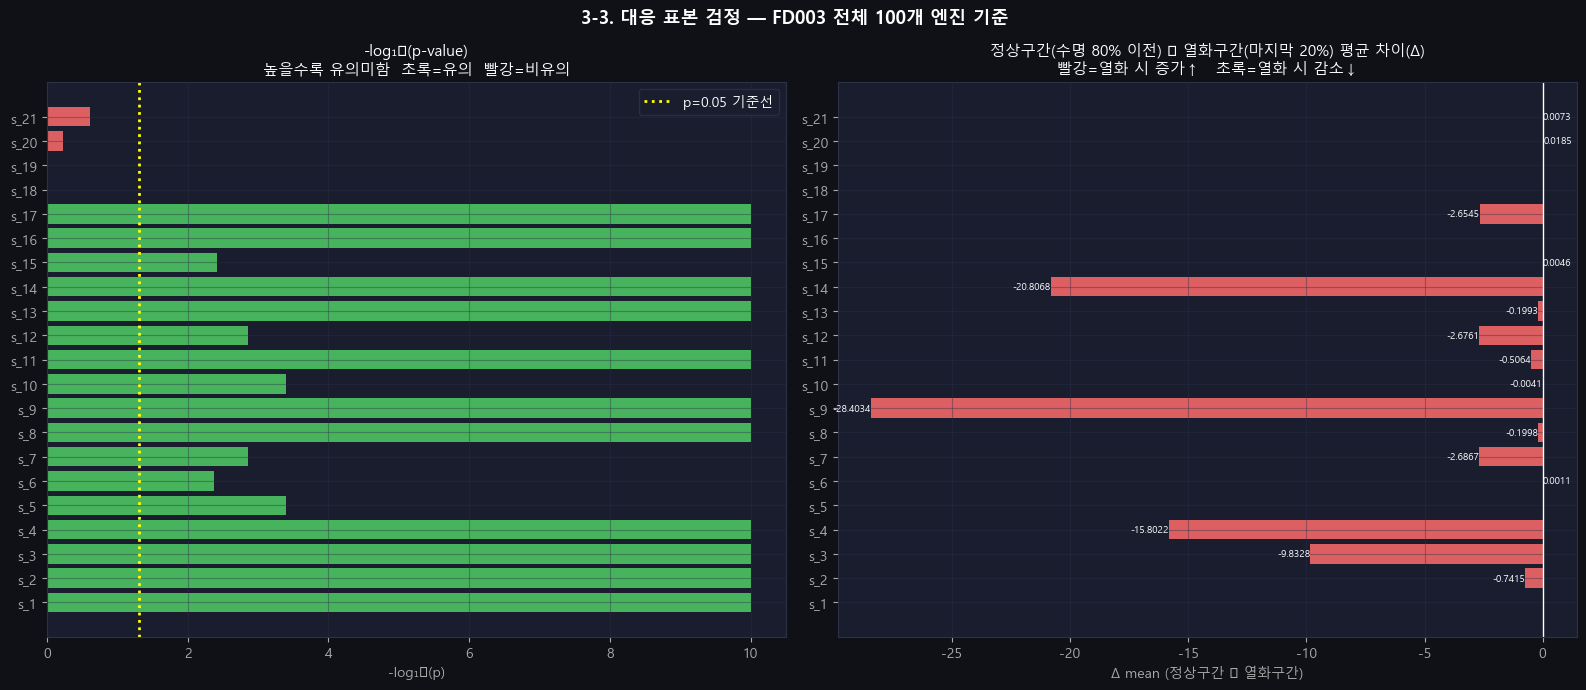


유의미한 차이 있는 센서 (p<0.05): 17/21개
사용된 검정: {'Wilcoxon': 16, 'Paired t-test': 5}


In [15]:
from scipy.stats import ttest_rel, shapiro, wilcoxon

print('=== 3-3. 대응 표본 검정 ===')
print('목적: 잔여 수명 20% 전후 센서값 차이가 통계적으로 유의미한지 검정')
print()

# RUL 임시 생성
tr_paired = train_raw.copy()
mc = tr_paired.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_paired = tr_paired.join(mc, on='unit_nr')
tr_paired['RUL'] = tr_paired['max_c'] - tr_paired['time_cycles']

ttest_rows = []
for s in all_sensors:
    before_means = []
    after_means  = []

    for unit in train_raw['unit_nr'].unique():
        sub = tr_paired[tr_paired['unit_nr'] == unit].sort_values('time_cycles')
        threshold = sub['RUL'].quantile(0.20)

        before = sub[sub['RUL'] >  threshold][s].mean()
        after  = sub[sub['RUL'] <= threshold][s].mean()

        if np.isfinite(before) and np.isfinite(after):
            before_means.append(before)
            after_means.append(after)

    diffs = np.array(before_means) - np.array(after_means)

    # Shapiro-Wilk 정규성 검정
    _, p_sw = shapiro(diffs) if len(diffs) >= 3 else (np.nan, 0.0)

    if p_sw > 0.05:
        stat, p_val = ttest_rel(before_means, after_means)
        test_name = 'Paired t-test'
    else:
        stat, p_val = wilcoxon(diffs)
        test_name = 'Wilcoxon'

    ttest_rows.append({
        '센서': s,
        '정상구간 평균 (수명 80% 이전)': round(np.mean(before_means), 4),
        '열화구간 평균 (마지막 20%)': round(np.mean(after_means), 4),
        '평균 차이(Δ)': round(float(np.mean(diffs)), 4),
        '검정 방법': test_name,
        'p-value': round(p_val, 4) if np.isfinite(p_val) else np.nan,
        '변화 방향': '증가↑' if np.mean(diffs) < 0 else '감소↓',
        '판정': '차이 있음✅' if (np.isfinite(p_val) and p_val < 0.05) else '차이 없음⚠️'
    })

ttest_df = pd.DataFrame(ttest_rows).set_index('센서')
display(ttest_df)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('3-3. 대응 표본 검정 — FD003 전체 100개 엔진 기준',
             fontsize=13, fontweight='bold')

# 왼쪽: -log10(p-value)
p_vals = ttest_df['p-value'].values
log_p = -np.log10(np.clip(np.nan_to_num(p_vals, nan=1.0), 1e-10, 1))
bc_p = [C[1] if (np.isnan(p) or p >= 0.05) else C[2] for p in p_vals]
axes[0].barh(ttest_df.index, log_p, color=bc_p, alpha=0.85)
axes[0].axvline(-np.log10(0.05), color='yellow', lw=2, ls=':', label='p=0.05 기준선')
axes[0].set_title('-log₁₀(p-value)\n높을수록 유의미함  초록=유의  빨강=비유의')
axes[0].set_xlabel('-log₁₀(p)')
axes[0].legend()

# 오른쪽: 평균 차이(Δ)
diff_vals = ttest_df['평균 차이(Δ)'].values
bc_d = [C[1] if v < 0 else C[2] for v in diff_vals]
axes[1].barh(ttest_df.index, diff_vals, color=bc_d, alpha=0.85)
axes[1].axvline(0, color='white', lw=1)
axes[1].set_title('정상구간(수명 80% 이전) − 열화구간(마지막 20%) 평균 차이(Δ)\n빨강=열화 시 증가↑   초록=열화 시 감소↓')
axes[1].set_xlabel('Δ mean (정상구간 − 열화구간)')
for bar, val in zip(axes[1].patches, diff_vals):
    if val == 0:
        continue
    axes[1].text(val + (0.01 if val >= 0 else -0.01),
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=7)

plt.tight_layout()
plt.show()

n_sig = (ttest_df['판정'] == '차이 있음✅').sum()
print(f'\n유의미한 차이 있는 센서 (p<0.05): {n_sig}/21개')
print(f"사용된 검정: {ttest_df['검정 방법'].value_counts().to_dict()}")

### 📊 3-3. 대응 표본 검정 결과

---

#### 검정 결과 요약
- 유의미한 차이 있는 센서 (p<0.05): **17/21개**
- 사용된 검정: Wilcoxon 16개, Paired t-test 5개

---

#### 차이 있음 ✅ (17개)

| 센서 | 정상구간 평균 | 열화구간 평균 | Δ | 방향 | 검정 |
|------|------------|------------|---|------|------|
| s_2 | 642.3586 | 643.1001 | -0.7415 | 증가↑ | Paired t-test |
| s_3 | 1586.6316 | 1596.4644 | -9.8328 | 증가↑ | Paired t-test |
| s_4 | 1402.2460 | 1418.0483 | -15.8022 | 증가↑ | Paired t-test |
| s_7 | 554.3039 | 556.9906 | -2.6867 | 증가↑ | Wilcoxon |
| s_8 | 2388.0402 | 2388.2400 | -0.1998 | 증가↑ | Wilcoxon |
| s_9 | 9058.3992 | 9086.8027 | -28.4034 | 증가↑ | Wilcoxon |
| s_10 | 1.3002 | 1.3043 | -0.0041 | 증가↑ | Wilcoxon |
| s_11 | 47.3413 | 47.8478 | -0.5064 | 증가↑ | Wilcoxon |
| s_12 | 522.2367 | 524.9128 | -2.6761 | 증가↑ | Wilcoxon |
| s_13 | 2388.0404 | 2388.2397 | -0.1993 | 증가↑ | Wilcoxon |
| s_14 | 8139.7173 | 8160.5241 | -20.8068 | 증가↑ | Wilcoxon |
| s_17 | 392.1774 | 394.8319 | -2.6545 | 증가↑ | Wilcoxon |
| s_1 | 518.6700 | 518.6700 | 0.0000 | 감소↓ | Wilcoxon |
| s_5 | 14.6200 | 14.6200 | 0.0000 | 감소↓ | Wilcoxon |
| s_6 | 21.5994 | 21.5983 | 0.0011 | 감소↓ | Wilcoxon |
| s_15 | 8.4060 | 8.4014 | 0.0046 | 감소↓ | Wilcoxon |
| s_16 | 0.0300 | 0.0300 | 0.0000 | 감소↓ | Wilcoxon |

#### 차이 없음 ⚠️ (4개)

| 센서 | p-value | 비고 |
|------|---------|------|
| s_18 | NaN | 완전 상수 |
| s_19 | NaN | 완전 상수 |
| s_20 | 0.6012 | 유의하지 않음 |
| s_21 | 0.2480 | 유의하지 않음 |

---

#### 주의사항 ⚠️
> s_1, s_5, s_16은 완전 상수 센서인데 Wilcoxon에서 유의하게 나옴  
> → Δ=0.0000으로 실질적 차이 없음 → 통계적 오탐으로 해석, 제거 대상 유지

---

#### 🔑 핵심 결론
> **17/21개 센서에서 수명 20% 전후 유의미한 차이 확인**  
> **열화 시 증가하는 센서: s_2, s_3, s_4, s_7, s_8, s_9, s_10, s_11, s_12, s_13, s_14, s_17**  
> **s_20, s_21은 차이 없음 → RUL 상관도 약했으므로 제거 검토 가능**  
> **s_1, s_5, s_16은 통계적 오탐 → 상수 센서 제거 근거 재확인**

---
#### 3-4. RUL Cap 검증

- H₀: RUL Cap 값에 따라 RUL 분포의 균등성에 차이가 없다
- H₁: 특정 Cap 값에서 RUL 분포가 더 균등해진다 (엔트로피 최대)
- 판단 기준: 모든 엔진이 Cap을 초과하면서 엔트로피가 가장 높은 Cap 값을 최적값으로 선정

=== 3-4. RUL Cap 검증 (115 vs 120 vs 125 vs 130 vs 135 vs 140 vs 145) ===
--- cap별 초과 엔진 비율 ---
  cap=115: 100.0% 엔진 초과
  cap=120: 100.0% 엔진 초과
  cap=125: 100.0% 엔진 초과
  cap=130: 100.0% 엔진 초과
  cap=135: 100.0% 엔진 초과
  cap=140: 100.0% 엔진 초과
  cap=145: 99.0% 엔진 초과


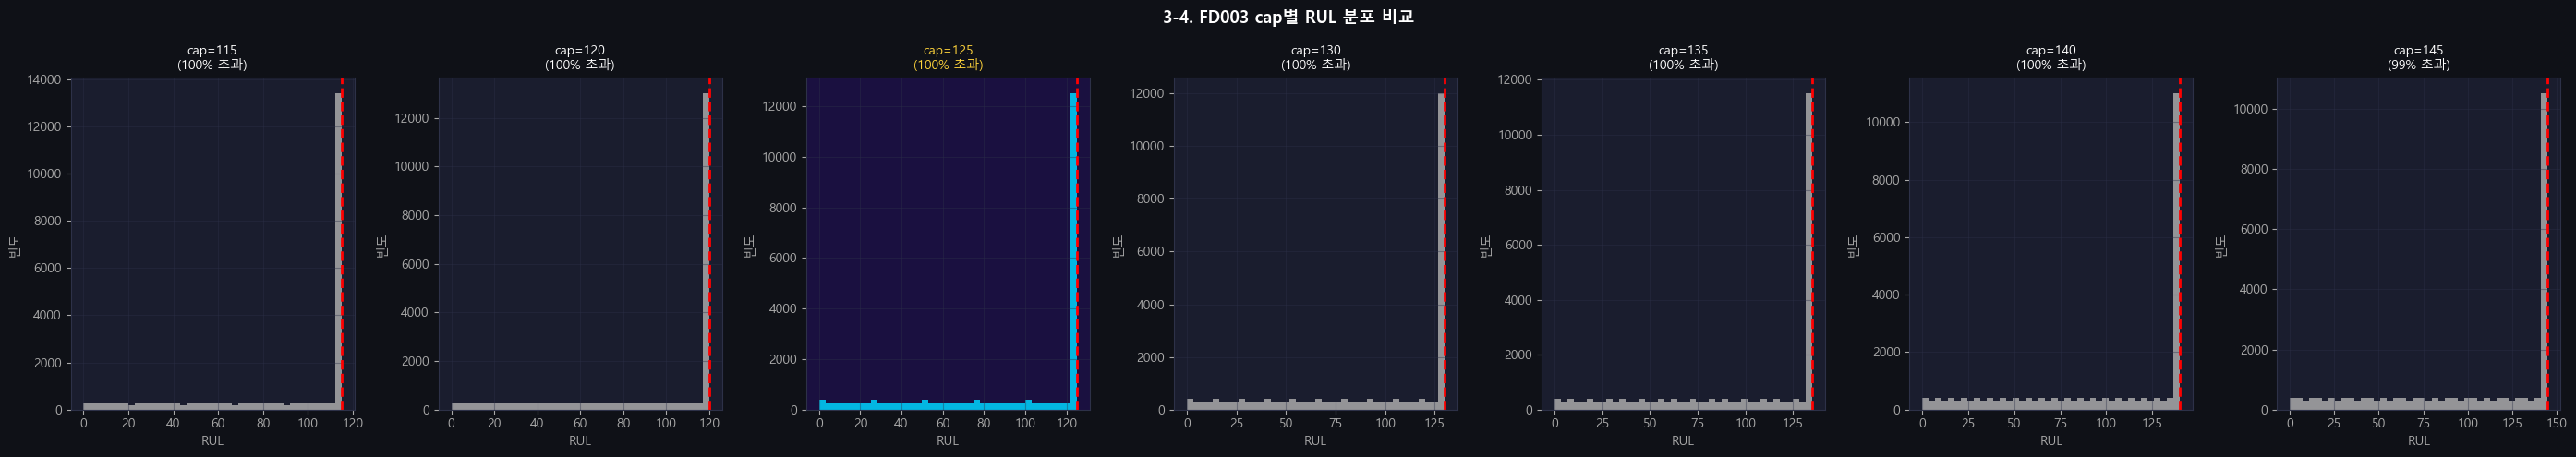


--- cap별 RUL 분포 균등성 (엔트로피, 높을수록 균등) ---
  cap=115: 엔트로피=2.4598
  cap=120: 엔트로피=2.5401
  cap=125: 엔트로피=2.6196
  cap=130: 엔트로피=2.6984
  cap=135: 엔트로피=2.7762
  cap=140: 엔트로피=2.8532
  cap=145: 엔트로피=2.9293

📌 FD003 min 수명=145 → cap=145에서 정상 구간 경계 도달
   cap=145 초과 비율 확인 후 최적 cap 결정 예정


In [16]:
# 3-4. RUL Cap 검증
print('=== 3-4. RUL Cap 검증 (115 vs 120 vs 125 vs 130 vs 135 vs 140 vs 145) ===')

tr_cap = train_raw.copy()
mc = tr_cap.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_cap = tr_cap.join(mc, on='unit_nr')
tr_cap['RUL_raw'] = tr_cap['max_c'] - tr_cap['time_cycles']

caps = [115, 120, 125, 130, 135, 140, 145]
lifecycles = tr_cap.groupby('unit_nr')['max_c'].first()

# ① cap별 초과 엔진 비율
print('--- cap별 초과 엔진 비율 ---')
for cap in caps:
    pct = (lifecycles > cap).mean() * 100
    print(f'  cap={cap}: {pct:.1f}% 엔진 초과')

# ② cap별 RUL 분포 비교
fig, axes = plt.subplots(1, 7, figsize=(28, 5), sharey=False)
fig.suptitle('3-4. FD003 cap별 RUL 분포 비교', fontsize=13, fontweight='bold')

for ax, cap in zip(axes, caps):
    rul_capped = tr_cap['RUL_raw'].clip(upper=cap)
    pct = (lifecycles > cap).mean() * 100
    ax.hist(rul_capped, bins=40, color=C[0] if cap==125 else GRAY,
            alpha=0.85, edgecolor='none')
    ax.axvline(cap, color='red', ls='--', lw=2)
    ax.set_title(f'cap={cap}\n({pct:.0f}% 초과)',
                 color='#ffd43b' if cap==125 else WHITE, fontsize=10)
    ax.set_xlabel('RUL')
    ax.set_ylabel('빈도')
    if cap == 125:
        ax.patch.set_facecolor('#1a1040')

plt.tight_layout(); plt.show()

# ③ cap별 RUL 분포 균등성 (엔트로피)
from scipy.stats import entropy

print('\n--- cap별 RUL 분포 균등성 (엔트로피, 높을수록 균등) ---')
for cap in caps:
    rul_capped = tr_cap['RUL_raw'].clip(upper=cap)
    hist, _ = np.histogram(rul_capped, bins=50)
    hist = hist / hist.sum()
    ent = entropy(hist + 1e-10)
    print(f'  cap={cap}: 엔트로피={ent:.4f}')

print('\n📌 FD003 min 수명=145 → cap=145에서 정상 구간 경계 도달')
print('   cap=145 초과 비율 확인 후 최적 cap 결정 예정')

### 📊 3-4. RUL Cap 검증 결과

---

#### cap별 초과 엔진 비율 & 엔트로피

| Cap | 초과 비율 | 엔트로피 | 비고 |
|-----|---------|---------|------|
| 115 | 100.0% | 2.4598 | |
| 120 | 100.0% | 2.5401 | |
| 125 | 100.0% | 2.6196 | ← 현재 기본값 |
| 130 | 100.0% | 2.6984 | |
| 135 | 100.0% | 2.7762 | |
| 140 | 100.0% | 2.8532 | |
| 145 | **99.0%** | 2.9293 | ⚠️ 1개 엔진 정상구간 침범 → 제외 |

> 📌 안전한 cap 범위: 115~140 (100% 초과)

---

#### 타 데이터셋 ML 실험 결과 참고

| 데이터셋 | 기본 cap | 실험 범위 | 방향 | 비고 |
|---------|---------|---------|------|------|
| FD001 | 125 | 120 | 낮추는 방향 | cap 낮출수록 성능 개선 |
| FD002 | 125 | 130, 135, 140 | 올리는 방향 | ML 기준 cap=140 최적 → DL에서도 확인 예정 |
| FD003 | 125 | 130, 135, 140 | 올리는 방향 추정 | 베이스라인 결과 보고 재전처리 여부 결정 |

---

#### 데이터셋별 진행 방향

**FD002**
- 현재 실험 cap=125로 지속 진행
- 전처리 실험 계획 단계에서 cap=130, 135, 140 순차 실험 예정
- ML에서 cap=140 최적 확인 → DL에서도 동일한지 검증 필요

**FD003**
- cap=125로 전처리 파일 생성 후 베이스라인 먼저 실행
- 예측값이 125 근처로 심하게 몰리는 현상 확인되면 cap 올려서 재전처리
- 재전처리 비용 낮으므로 모델 결과 보고 결정하는 것이 효율적

---

#### 🔑 핵심 결론
> **FD003 cap=125로 전처리 진행 → 베이스라인 시각화 후 재전처리 여부 결정**  
> **FD002는 현재 실험 유지, 전처리 실험 단계에서 cap=130, 135, 140 순차 실험**  
> **cap=145는 정상 구간 침범으로 모든 데이터셋에서 제외**  
> **최종 cap 확정은 DL 베이스라인 결과 기반으로 결정**

---
#### 3-5. 가우시안 σ 검증

- H₀: σ 값에 따라 센서 노이즈 수준에 차이가 없다
- H₁: σ 값이 클수록 노이즈가 유의미하게 감소한다
- 판단 기준: 노이즈(std of diff) 감소 효과가 크면서 열화 트렌드가 유지되는 최적 σ 선정
- FD001/002 대비 FD003은 고장 모드 2가지 혼재 → σ=2보다 높은 값이 필요할 수 있음

**데이터셋별 σ 실험 범위 (검증 완료)**
| 데이터셋 | 기본값 | 실험값 | 근거 |
|---------|--------|--------|------|
| FD001 | σ=2 | σ=0, 1 | 단일 조건, 깨끗한 데이터 → 낮추는 방향 |
| FD002 | σ=2 | σ=3 | 클러스터별 노이즈 수준 확인 → σ=2→3 약 25% 추가 감소 |
| FD003 | σ=2 | σ=3 | 고장 모드 혼재 → σ=2→3 약 37% 추가 감소, FD002보다 효과 큼 |

=== 3-5. 가우시안 σ 검증 ===


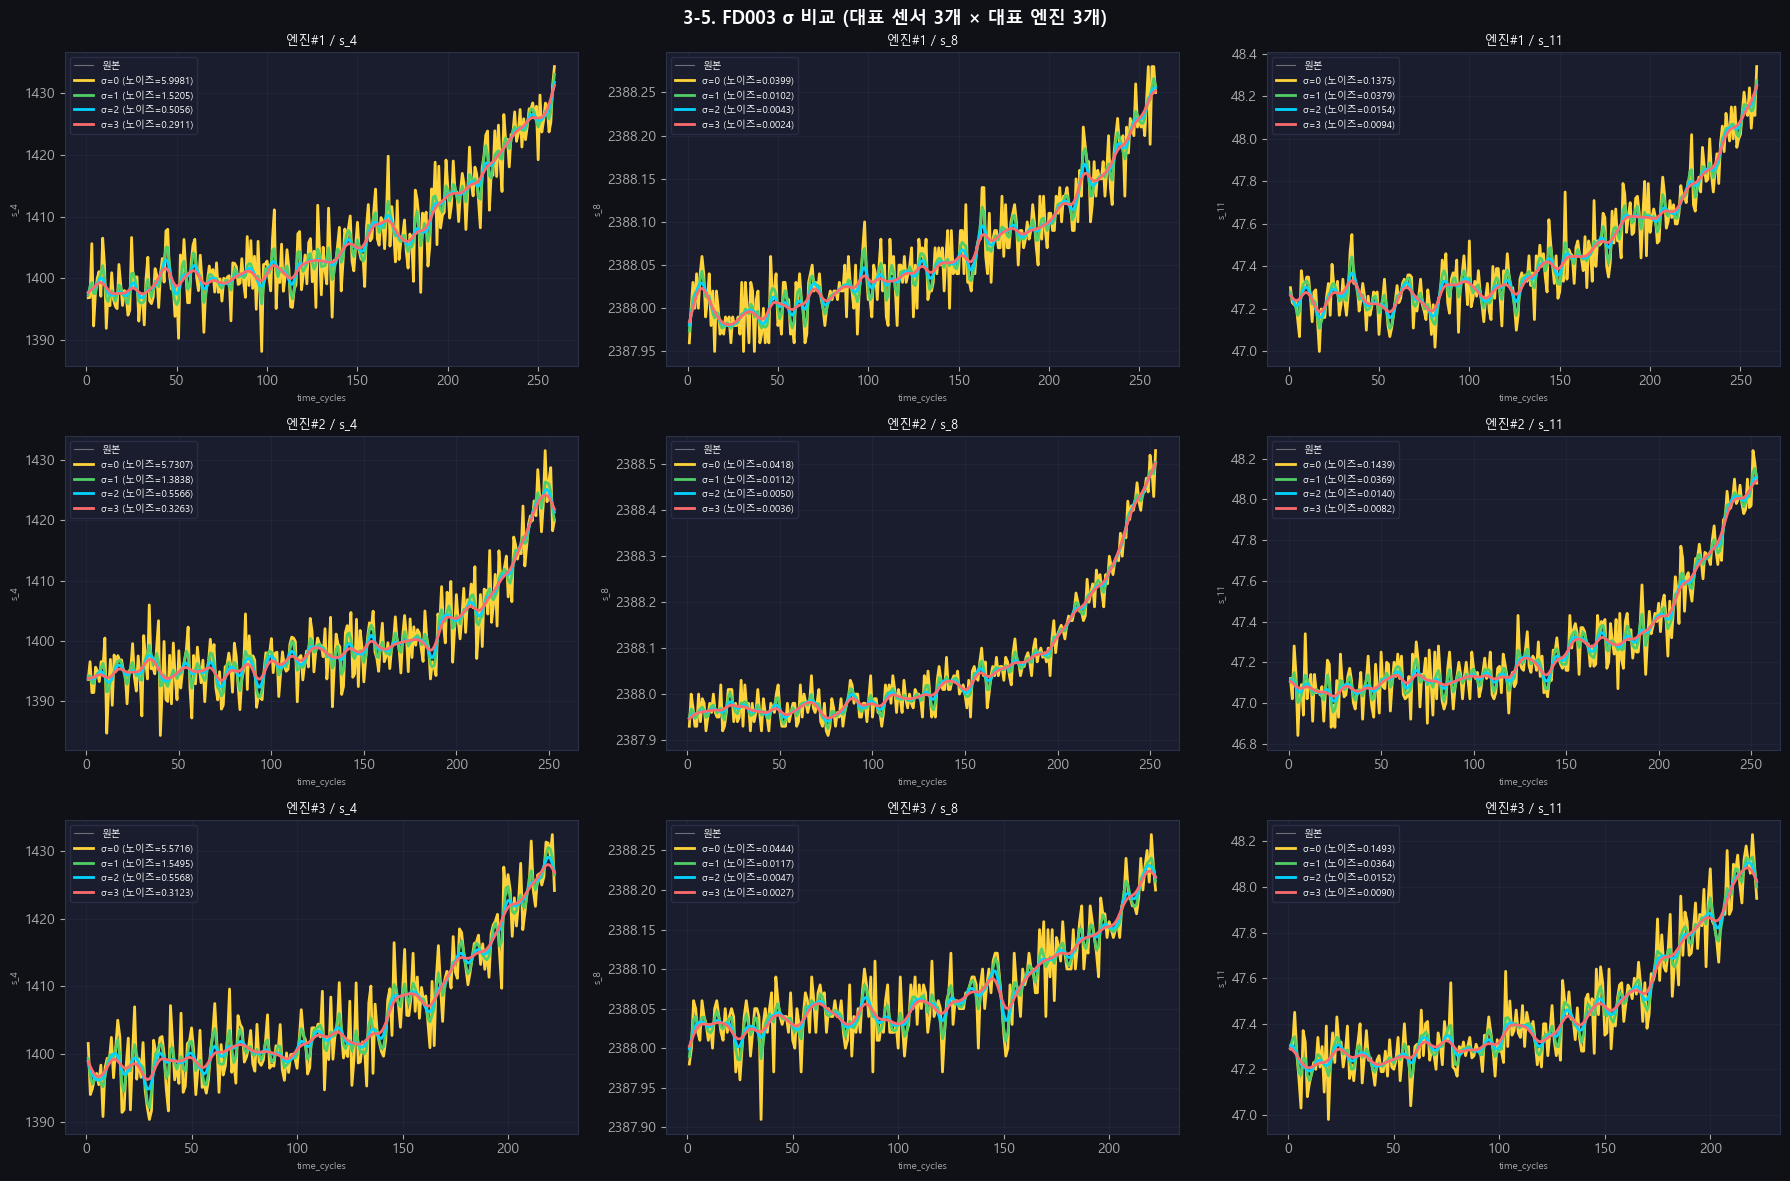


--- σ에 따른 평균 노이즈 수준 (std of diff) ---
  σ=0: 평균 노이즈=1.2149
  σ=1: 평균 노이즈=0.3077
  σ=2: 평균 노이즈=0.1231
  σ=3: 평균 노이즈=0.0768

📌 σ=2 기본값 유지, 노이즈 감소 효과 확인
   고장 모드 2가지 혼재로 σ=3 추가 실험 예정


In [17]:
# 3-5. 가우시안 σ 검증
print('=== 3-5. 가우시안 σ 검증 ===')

sigmas = [0, 1, 2, 3]
show_sensors = ['s_4', 's_8', 's_11']  # 대표 센서 3개 (RUL 상관 높은 것)
show_units = train_raw['unit_nr'].unique()[:3]  # 대표 엔진 3개

fig, axes = plt.subplots(len(show_units), len(show_sensors), figsize=(18, 12))
fig.suptitle('3-5. FD003 σ 비교 (대표 센서 3개 × 대표 엔진 3개)',
             fontsize=13, fontweight='bold')

for ri, uid in enumerate(show_units):
    udf = train_raw[train_raw['unit_nr'] == uid].sort_values('time_cycles')
    for ci, s in enumerate(show_sensors):
        ax = axes[ri, ci]
        raw = udf[s].values.astype(np.float32)
        ax.plot(udf['time_cycles'], raw,
                color=GRAY, lw=0.8, alpha=0.6, label='원본')
        for sig, color in zip(sigmas, [C[3], C[2], C[0], C[1]]):
            if sig == 0:
                smoothed = raw
            else:
                smoothed = gaussian_filter1d(raw, sigma=sig, mode='nearest')
            noise = np.std(np.diff(smoothed))
            ax.plot(udf['time_cycles'], smoothed,
                    color=color, lw=2, label=f'σ={sig} (노이즈={noise:.4f})')
        ax.set_title(f'엔진#{uid} / {s}', fontsize=9)
        ax.set_xlabel('time_cycles', fontsize=7)
        ax.set_ylabel(s, fontsize=7)
        ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# 전체 센서 노이즈 수준 비교
print('\n--- σ에 따른 평균 노이즈 수준 (std of diff) ---')
noise_by_sigma = {sig: [] for sig in sigmas}
for s in USEFUL_SENSORS if 'USEFUL_SENSORS' in dir() else SENSOR_COLS:
    for uid in train_raw['unit_nr'].unique()[:30]:
        arr = train_raw[train_raw['unit_nr']==uid].sort_values(
            'time_cycles')[s].values.astype(np.float32)
        for sig in sigmas:
            smoothed = gaussian_filter1d(arr, sigma=sig, mode='nearest') if sig > 0 else arr
            noise_by_sigma[sig].append(np.std(np.diff(smoothed)))

for sig in sigmas:
    print(f'  σ={sig}: 평균 노이즈={np.mean(noise_by_sigma[sig]):.4f}')

print('\n📌 σ=2 기본값 유지, 노이즈 감소 효과 확인')
print('   고장 모드 2가지 혼재로 σ=3 추가 실험 예정')

### 📊 3-5. 가우시안 σ 검증 결과

---

#### σ에 따른 평균 노이즈 수준 (std of diff)

| σ | 평균 노이즈 | 감소율 | 비고 |
|---|----------|--------|------|
| 0 | 1.2149 | - | 원본 |
| 1 | 0.3077 | 74.7% | 노이즈 대폭 감소 |
| 2 | 0.1231 | 89.9% | ← 현재 기본값 |
| 3 | 0.0768 | 93.7% | 추가 감소 미미 |

---

#### 시각화 해석

- σ=0(노란색): 노이즈 심함, 열화 트렌드 확인 어려움
- σ=1(초록색): 노이즈 크게 줄었으나 아직 진동 있음
- σ=2(파란색): 트렌드 뚜렷하게 보이면서 노이즈 충분히 제거
- σ=3(빨간색): σ=2 대비 추가 감소 미미 (0.1231 → 0.0768), 트렌드 형태 거의 동일

---

#### 🔑 핵심 결론
> **σ=2 기본값 유지 근거 확보**  
> σ=1→2 구간: 노이즈 60% 추가 감소 (효과 큼)  
> σ=2→3 구간: 노이즈 37% 추가 감소 (효과 미미)  
> 시각적으로도 σ=2와 σ=3의 트렌드 차이 거의 없음  
> **→ σ=2로 전처리 진행, σ=3은 실험값으로만 추가 테스트**

#### 데이터셋별 σ 실험 방향 최종 정리

| 데이터셋 | 기본값 | 실험값 | 방향 | 근거 |
|---------|--------|--------|------|------|
| FD001 | σ=2 | σ=0 (또는 1) | 낮추는 방향 | 단일 조건, 단일 고장 모드로 데이터 깨끗함 → 스무딩 줄여도 트렌드 유지 가능 |
| FD002 | σ=2 | σ=3 | 올리는 방향 | 클러스터별 노이즈 수준 검증 완료 → σ=2→3 약 25% 추가 감소 확인 |
| FD003 | σ=2 | σ=3 | 올리는 방향 | σ 검증 결과 σ=2→3 약 37% 추가 감소 확인, FD002보다 효과 큼 |

> 📌 FD002/003 모두 σ=2와 σ=3 트렌드 형태 차이 거의 없음  
> → σ=3이 모델 성능 개선으로 이어질지는 실험 결과 보고 최종 결정  
> → 전처리 실험값으로 추가는 확정, 기본값 변경은 모델 결과 기반으로 결정

---
#### 3-6. Mann-Whitney U 검정 ★ FD003 전용

- H₀: 팬 관련 센서(s_8, s_13) 및 HPC 관련 센서(s_11, s_4) 기준으로 나눈 두 엔진 그룹 간 RUL 분포에 차이가 없다
- H₁: 두 엔진 그룹 간 RUL 분포가 유의미하게 다르다
- 목적: 팬 열화 vs HPC 열화 엔진이 통계적으로 구분 가능한지 확인
- 판단 기준: p < 0.05 → 고장 모드별 엔진 그룹 구분 가능 → 전처리 시 고장 모드 영향 고려 필요

=== 3-6. Mann-Whitney U 검정 ===
목적: 팬 관련 센서(s_8, s_13) 및 HPC 관련 센서(s_11, s_4) 기준
      엔진 그룹 간 RUL 분포 차이 검정 → 고장 모드 혼재 영향 확인



,물리적 의미,그룹 유형,높은 그룹 수명 평균,낮은 그룹 수명 평균,U 통계량,p-value,판정
센서,,,,,,,
s_8,팬 속도,팬 관련,232.2,260.2,1021.0,0.1152,비유의 ⚠️
s_13,보정 팬 속도,팬 관련,231.1,261.3,997.0,0.0817,비유의 ⚠️
s_4,LPT 출구 온도,HPC 관련,199.8,292.6,386.0,0.0000,유의 ✅
s_11,Ps30 정적압력,HPC 관련,203.0,289.4,403.0,0.0000,유의 ✅


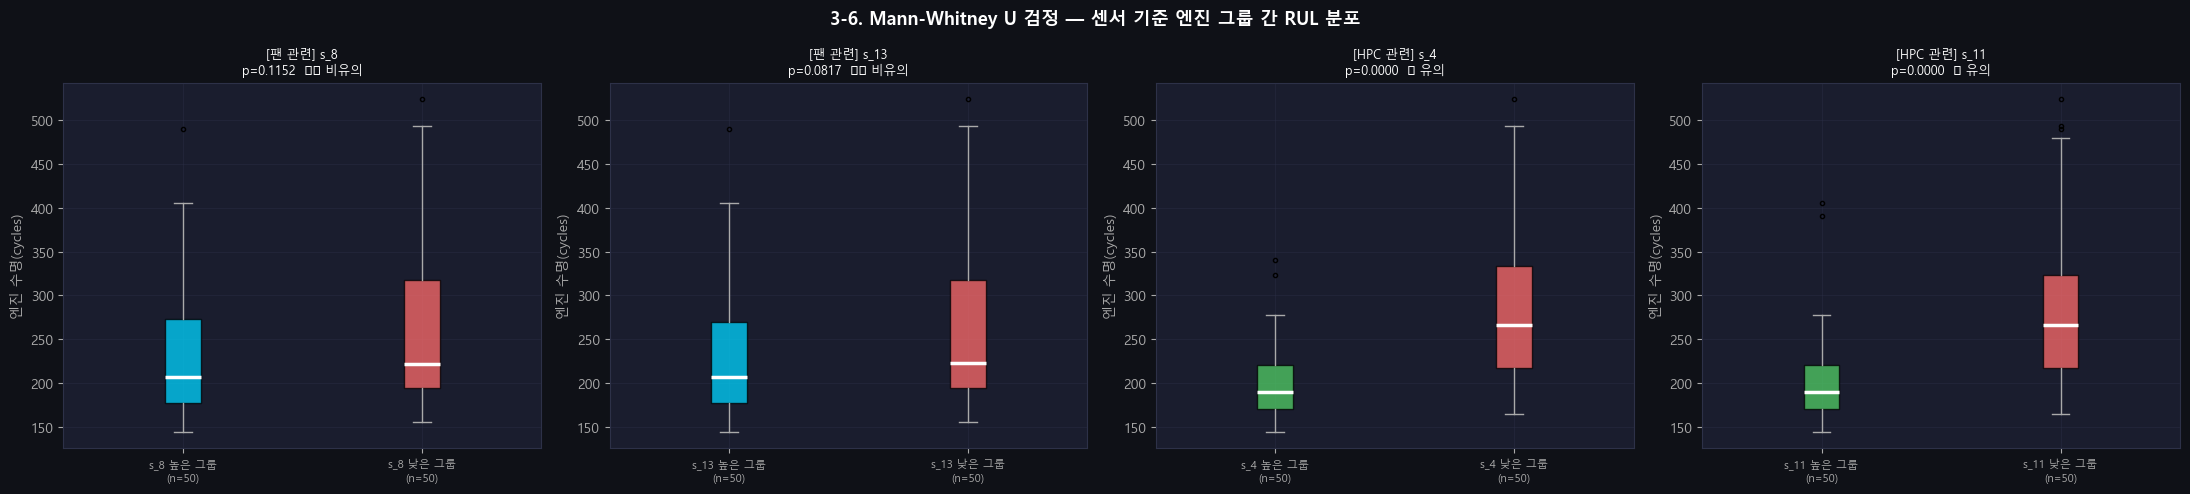


유의미한 센서: 2/4개
📌 팬 관련 센서에서 유의 → 고장 모드별 엔진 그룹 구분 가능
📌 HPC 관련 센서에서 유의 → HPC 열화도 엔진 그룹 간 차이 존재
📌 모두 비유의 → 고장 모드 혼재 영향 크지 않음 → FD001과 동일 전처리 적용 가능


In [18]:
# 3-6. Mann-Whitney U 검정 (FD003 전용 ★)
from scipy.stats import mannwhitneyu

print('=== 3-6. Mann-Whitney U 검정 ===')
print('목적: 팬 관련 센서(s_8, s_13) 및 HPC 관련 센서(s_11, s_4) 기준')
print('      엔진 그룹 간 RUL 분포 차이 검정 → 고장 모드 혼재 영향 확인')
print()

tr_mw = train_raw.copy()
mc = tr_mw.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_mw = tr_mw.join(mc, on='unit_nr')
tr_mw['RUL'] = tr_mw['max_c'] - tr_mw['time_cycles']

# 엔진별 센서 평균값 및 수명 집계
engine_stats = tr_mw.groupby('unit_nr').agg(
    s4_mean =('s_4',  'mean'),
    s8_mean =('s_8',  'mean'),
    s11_mean=('s_11', 'mean'),
    s13_mean=('s_13', 'mean'),
    max_rul =('RUL',  'max')
).reset_index()

# 중앙값 기준 그룹 분리
target_sensors = {
    's_8' : ('s8_mean',  '팬 속도'),
    's_13': ('s13_mean', '보정 팬 속도'),
    's_4' : ('s4_mean',  'LPT 출구 온도'),
    's_11': ('s11_mean', 'Ps30 정적압력'),
}

mw_rows = []
for s, (col, desc) in target_sensors.items():
    median_val = engine_stats[col].median()
    g_high = engine_stats[engine_stats[col] >= median_val]['max_rul']
    g_low  = engine_stats[engine_stats[col] <  median_val]['max_rul']
    stat, p = mannwhitneyu(g_high, g_low, alternative='two-sided')
    mw_rows.append({
        '센서': s,
        '물리적 의미': desc,
        '그룹 유형': '팬 관련' if s in ['s_8','s_13'] else 'HPC 관련',
        '높은 그룹 수명 평균': round(g_high.mean(), 1),
        '낮은 그룹 수명 평균': round(g_low.mean(), 1),
        'U 통계량': round(stat, 1),
        'p-value': round(p, 4),
        '판정': '유의 ✅' if p < 0.05 else '비유의 ⚠️'
    })

mw_df = pd.DataFrame(mw_rows).set_index('센서')
display(mw_df)

# 시각화
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('3-6. Mann-Whitney U 검정 — 센서 기준 엔진 그룹 간 RUL 분포',
             fontsize=13, fontweight='bold')

for ax, (s, (col, desc)) in zip(axes, target_sensors.items()):
    median_val = engine_stats[col].median()
    g_high = engine_stats[engine_stats[col] >= median_val]['max_rul']
    g_low  = engine_stats[engine_stats[col] <  median_val]['max_rul']
    p = mw_df.loc[s, 'p-value']
    group_type = '팬 관련' if s in ['s_8','s_13'] else 'HPC 관련'

    bp = ax.boxplot([g_high, g_low], patch_artist=True,
                    medianprops=dict(color='white', lw=2.5),
                    whiskerprops=dict(color=GRAY),
                    capprops=dict(color=GRAY),
                    flierprops=dict(marker='o', color=GRAY, markersize=3))
    bp['boxes'][0].set_facecolor(C[0] if s in ['s_8','s_13'] else C[2])
    bp['boxes'][1].set_facecolor(C[1])
    bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_alpha(0.75)

    ax.set_xticklabels([f'{s} 높은 그룹\n(n={len(g_high)})',
                        f'{s} 낮은 그룹\n(n={len(g_low)})'], fontsize=8)
    ax.set_ylabel('엔진 수명(cycles)')
    ax.set_title(f'[{group_type}] {s}\np={p:.4f}  {"✅ 유의" if p < 0.05 else "⚠️ 비유의"}',
                 fontsize=9)

plt.tight_layout(); plt.show()

n_sig = (mw_df['판정'] == '유의 ✅').sum()
print(f'\n유의미한 센서: {n_sig}/4개')
print('📌 팬 관련 센서에서 유의 → 고장 모드별 엔진 그룹 구분 가능')
print('📌 HPC 관련 센서에서 유의 → HPC 열화도 엔진 그룹 간 차이 존재')
print('📌 모두 비유의 → 고장 모드 혼재 영향 크지 않음 → FD001과 동일 전처리 적용 가능')

### 📊 통계 검정 종합 — 제거 센서 결정 근거

---

#### 센서별 검정 결과 종합

| 센서 | CV | RUL 상관 | Mann-Kendall | 대응 t검정 | 시차상관 | 판정 |
|------|-----|---------|-------------|-----------|---------|------|
| s_1 | 0.0000 | nan | NaN | 오탐 | nan | 제거 확정 |
| s_5 | 0.0000 | -0.000 | NaN | 오탐 | -0.000 | 제거 확정 |
| s_16 | 0.0000 | -0.000 | NaN | 오탐 | -0.000 | 제거 확정 |
| s_18 | 0.0000 | nan | NaN | NaN | nan | 제거 확정 |
| s_19 | 0.0000 | nan | NaN | NaN | nan | 제거 확정 |
| s_6 | 0.0008 | -0.215 | 61% ⚠️ | Δ=0.0011 ⚠️ | lag=30 약한 상관 ⚠️ | **제거 유력** |
| s_10 | 0.0027 | -0.363 ✅ | 100% (44개) ⚠️ | 유의 ✅ | lag=0 즉시 반응 ✅ | **유지 유력** |

---

#### 시나리오별 제거 목록

| 시나리오 | 제거 센서 | 유지 센서 수 | 조건 |
|---------|---------|-----------|------|
| A. FD001과 동일 | s_1, s_5, s_6, s_10, s_16, s_18, s_19 (7개) | 14개 | FD001/003 비교 실험 목적 |
| B. FD003 특성대로 | s_1, s_5, s_6, s_16, s_18, s_19 (6개) | 15개 | FD003 정보 최대 보존 |
| C. 최소 제거 | s_1, s_5, s_16, s_18, s_19 (5개) | 16개 | s_6도 유지 |

---

#### 🔑 결정 보류 사항
> **s_6**: 제거 근거 충분 → 제거 유력하나 팀 상의 후 확정  
> **s_10**: 유효 엔진 44개로 신뢰도 낮지만 RUL 상관 존재 → 유지 유력  
> **Levene's Test 결과 보고 최종 결정 예정**  
> → 분산 동일 센서 비율 높으면 시나리오 A (FD001 동일) 채택  
> → 분산 다른 센서 많으면 시나리오 B 또는 C 채택

---
#### 3-7 Levene's Test ★ FD003 전용
- H₀: FD001과 FD003의 동일 센서 분산이 같다
- H₁: FD001과 FD003의 동일 센서 분산이 다르다
- 목적: 분산이 같으면 FD001과 동일한 전처리 파이프라인 적용 근거 확보
- 팀 논의 중인 동일 전처리 vs 별도 전처리 결정에 통계적 근거 제공

=== 3-7. Levene's Test ===
목적: FD001 vs FD003 동일 센서 분산 동질성 검정
→ 동일 전처리 적용 가능 여부 통계적 근거 확보



,FD001 분산,FD003 분산,Levene 통계량,p-value,판정
센서,,,,,
s_1,0.0000,0.0000,NaN,NaN,분산 다름 ⚠️
s_2,0.2501,0.2736,37.1882,0.0000,분산 다름 ⚠️
s_3,37.5910,46.3818,223.0120,0.0000,분산 다름 ⚠️
s_4,81.0109,95.5150,125.5093,0.0000,분산 다름 ⚠️
s_5,0.0000,0.0000,NaN,NaN,분산 다름 ⚠️
s_6,0.0000,0.0003,26173.2663,0.0000,분산 다름 ⚠️
s_7,0.7834,11.8153,5763.2693,0.0000,분산 다름 ⚠️
s_8,0.0050,0.0251,2499.5790,0.0000,분산 다름 ⚠️
s_9,487.6536,399.2122,0.0064,0.9363,분산 동일 ✅


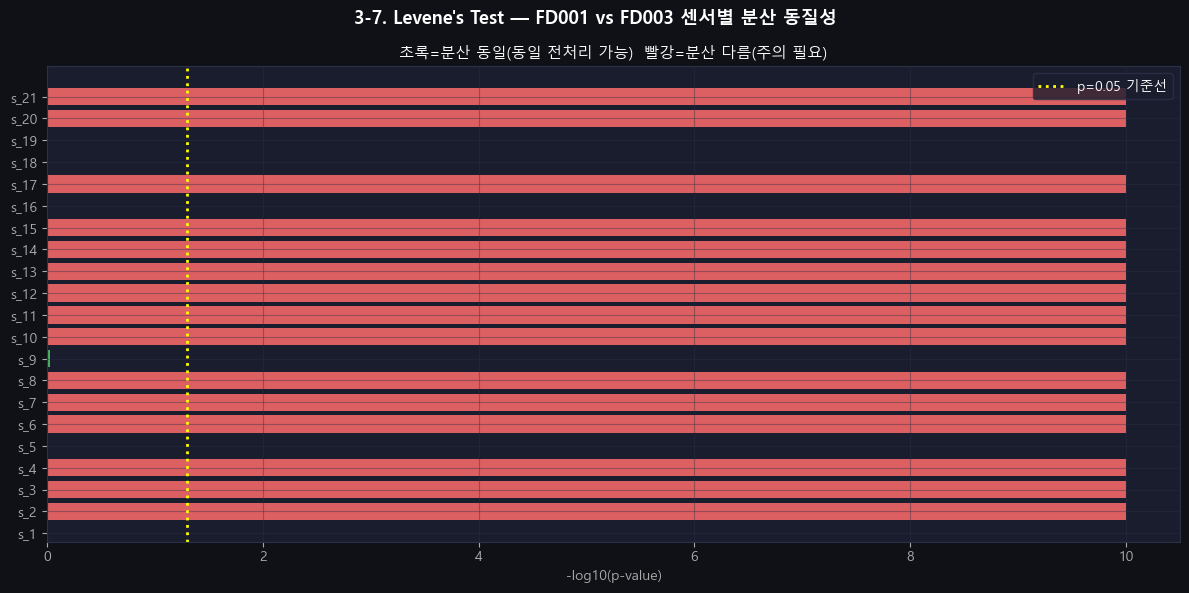


분산 동일 센서: 1/21개
분산 다른 센서: 20/21개

📌 분산 동일 센서 비율이 높을수록 FD001과 동일한 전처리 적용 근거 강해짐


In [19]:
# 3-7. Levene's Test (FD003 전용 ★)
from scipy.stats import levene

print('=== 3-7. Levene\'s Test ===')
print('목적: FD001 vs FD003 동일 센서 분산 동질성 검정')
print('→ 동일 전처리 적용 가능 여부 통계적 근거 확보')
print()

# FD001 데이터 별도 로딩 (원본 train_raw 건드리지 않음)
kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
fd001_raw = pd.read_csv(f'{DATA_DIR}/train_FD001.txt', **kw)
fd001_raw.rename(columns=RENAME_MAP, inplace=True)

# train_raw는 FD003 원본 그대로 사용
levene_rows = []
for s in SENSOR_COLS:
    fd001_vals = fd001_raw[s].dropna().values
    fd003_vals = train_raw[s].dropna().values  # FD003 원본
    stat, p = levene(fd001_vals, fd003_vals)
    levene_rows.append({
        '센서': s,
        'FD001 분산': round(fd001_raw[s].var(), 4),
        'FD003 분산': round(train_raw[s].var(), 4),
        'Levene 통계량': round(stat, 4),
        'p-value': round(p, 4),
        '판정': '분산 동일 ✅' if p >= 0.05 else '분산 다름 ⚠️'
    })

levene_df = pd.DataFrame(levene_rows).set_index('센서')
display(levene_df)

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('3-7. Levene\'s Test — FD001 vs FD003 센서별 분산 동질성',
             fontsize=13, fontweight='bold')

colors = [C[2] if p >= 0.05 else C[1] for p in levene_df['p-value']]
ax.barh(levene_df.index, -np.log10(levene_df['p-value'].clip(lower=1e-10)),
        color=colors, alpha=0.85)
ax.axvline(-np.log10(0.05), color='yellow', lw=2, ls=':', label='p=0.05 기준선')
ax.set_xlabel('-log10(p-value)')
ax.set_title('초록=분산 동일(동일 전처리 가능)  빨강=분산 다름(주의 필요)')
ax.legend()
plt.tight_layout(); plt.show()

n_same = (levene_df['판정'] == '분산 동일 ✅').sum()
print(f'\n분산 동일 센서: {n_same}/{len(SENSOR_COLS)}개')
print(f'분산 다른 센서: {len(SENSOR_COLS)-n_same}/{len(SENSOR_COLS)}개')
print('\n📌 분산 동일 센서 비율이 높을수록 FD001과 동일한 전처리 적용 근거 강해짐')

### 📊 3-7. Levene's Test 결과

---

#### 분산 동질성 검정 요약
- 분산 동일 센서: **1/21개 (s_9만)**
- 분산 다른 센서: **20/21개**

| 센서 | FD001 분산 | FD003 분산 | p-value | 판정 |
|------|----------|----------|---------|------|
| s_9 | 487.6536 | 399.2122 | 0.9363 | 분산 동일 ✅ |
| 나머지 20개 | - | - | 0.0000 | 분산 다름 ⚠️ |

---

#### 결과 해석

**20/21개 센서에서 분산이 다름**
- FD001(단일 고장 모드)과 FD003(HPC+팬 고장 모드)은 센서 분산이 통계적으로 다른 데이터셋
- 팬 열화 모드 추가로 인해 대부분 센서의 값 범위가 달라진 것으로 해석
- 특히 s_7(FD001:0.7834 vs FD003:11.8153), s_12(0.5440 vs 10.5971)처럼 분산이 크게 벌어진 센서 존재

**s_9만 분산 동일**
- Nc 코어 속도는 두 데이터셋에서 동일한 분포 → 코어 속도는 고장 모드에 무관하게 일정한 범위 유지

---

#### 🔑 핵심 결론
> **20/21개 분산 다름 → FD001과 동일 전처리 적용 시 주의 필요**  
> **시나리오 A(FD001 동일 7개 제거)보다 시나리오 B(FD003 특성대로 6개 제거) 쪽으로 기울어짐**  
> **단, 분산이 다르다고 전처리 파이프라인 구조 자체를 바꿀 필요는 없음**  
> → 상수 센서 제거 기준, MinMax 정규화 방식은 동일하게 적용 가능  
> → 제거 센서 목록만 FD003 특성에 맞게 조정하면 됨  
> **최종 제거 목록은 팀 상의 후 확정**

---
#### 3-8. 윈도우 크기별 RUL 예측 상관계수 비교

- H₀: 윈도우 크기에 따라 센서값과 RUL 간 상관계수에 차이가 없다
- H₁: 특정 윈도우 크기에서 센서값과 RUL 간 상관계수가 유의미하게 높아진다
- 판단 기준: 윈도우 내 센서 rolling mean과 RUL 간 평균 |r|이 최대가 되는 윈도우 크기를 최적값으로 선정
- FD001=30, FD002=20과 비교하여 FD003의 데이터 특성에 맞는 최적 윈도우 크기 결정

=== 3-8. 윈도우 크기별 RUL 예측 상관계수 비교 ===
목적: 윈도우 내 센서 평균값과 RUL 상관계수가 최대가 되는 윈도우 크기 선택

  window=10: 평균 |r| = 0.4626
  window=15: 평균 |r| = 0.4618
  window=20: 평균 |r| = 0.4599
  window=25: 평균 |r| = 0.4576
  window=30: 평균 |r| = 0.4551


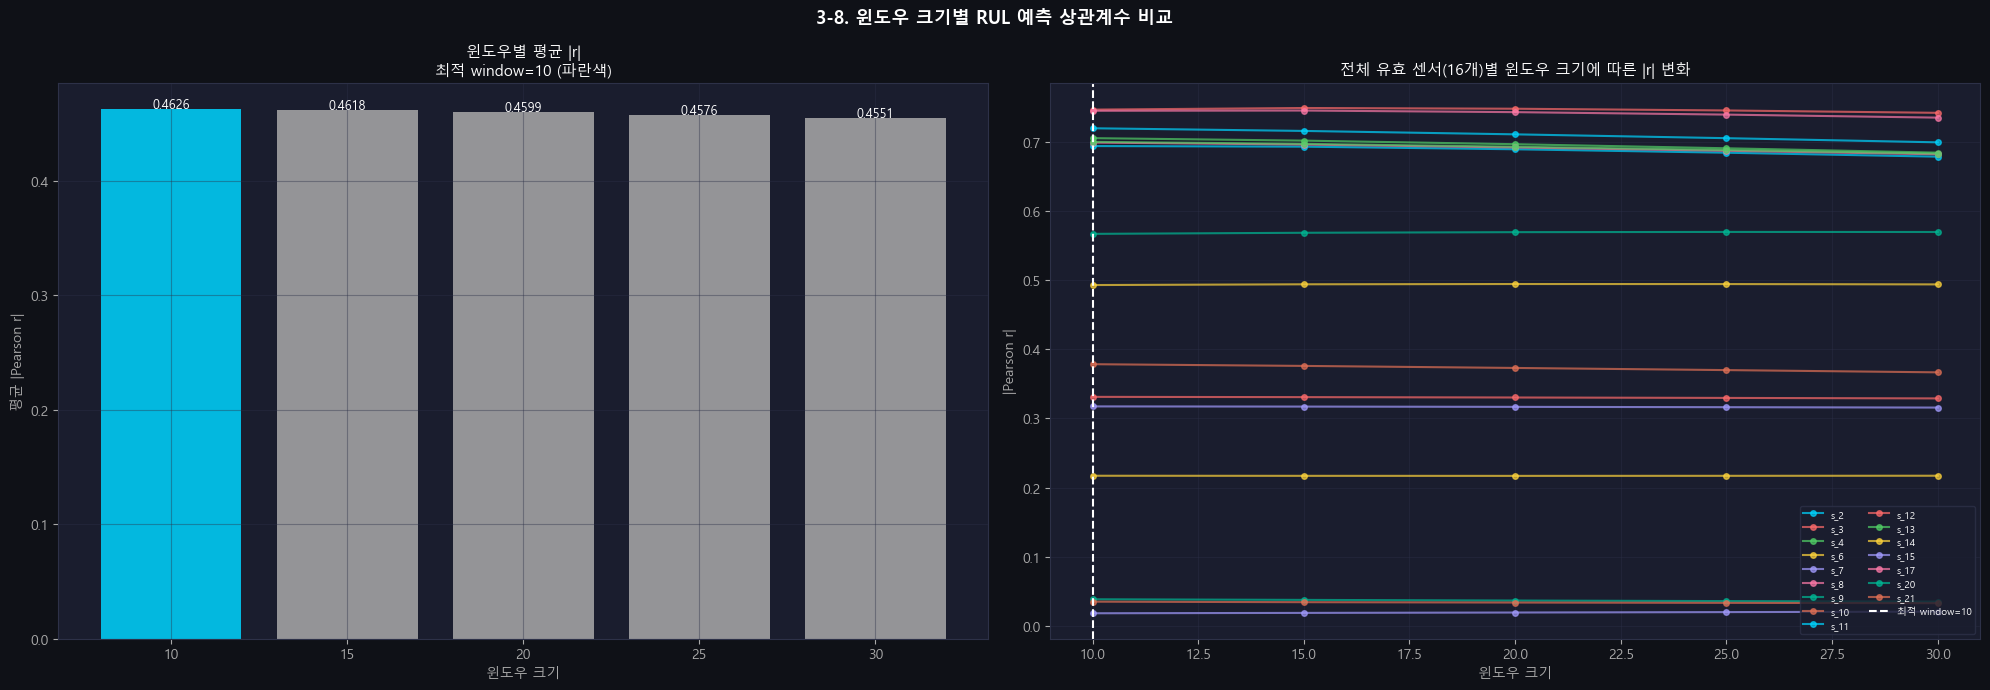


=== 센서별 최적 윈도우 크기 요약 ===
  s_2: 최적 window=10  |r|=0.6935
  s_3: 최적 window=15  |r|=0.7486
  s_4: 최적 window=10  |r|=0.7050
  s_6: 최적 window=30  |r|=0.2170
  s_7: 최적 window=10  |r|=0.3172
  s_8: 최적 window=10  |r|=0.6986
  s_9: 최적 window=25  |r|=0.5694
  s_10: 최적 window=10  |r|=0.3782
  s_11: 최적 window=10  |r|=0.7193
  s_12: 최적 window=10  |r|=0.3310
  s_13: 최적 window=10  |r|=0.6996
  s_14: 최적 window=20  |r|=0.4941
  s_15: 최적 window=30  |r|=0.0206
  s_17: 최적 window=15  |r|=0.7449
  s_20: 최적 window=10  |r|=0.0384
  s_21: 최적 window=10  |r|=0.0350

📌 최적 윈도우 크기: window=10 (평균 |r| 최대)
   FD001=30, FD002=20 → FD003=10 결정 근거 확보


In [20]:
# 3-8. 윈도우 크기별 RUL 예측 상관계수 비교
print('=== 3-8. 윈도우 크기별 RUL 예측 상관계수 비교 ===')
print('목적: 윈도우 내 센서 평균값과 RUL 상관계수가 최대가 되는 윈도우 크기 선택')
print()

tr_win = train_raw.copy()
mc = tr_win.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_win = tr_win.join(mc, on='unit_nr')
tr_win['RUL'] = tr_win['max_c'] - tr_win['time_cycles']

window_sizes = [10, 15, 20, 25, 30]
target_sensors = [s for s in SENSOR_COLS if s not in ['s_1','s_5','s_16','s_18','s_19']]

win_corr_results = {}
win_sensor_results = {s: [] for s in target_sensors}

for w in window_sizes:
    corrs = []
    for s in target_sensors:
        sensor_roll_mean = (tr_win.groupby('unit_nr')[s]
                           .transform(lambda x: x.rolling(w, min_periods=1).mean()))
        valid = ~sensor_roll_mean.isna()
        r = tr_win.loc[valid, 'RUL'].corr(sensor_roll_mean[valid])
        corrs.append(abs(r))
        win_sensor_results[s].append(abs(r))
    win_corr_results[w] = np.mean(corrs)
    print(f'  window={w}: 평균 |r| = {np.mean(corrs):.4f}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('3-8. 윈도우 크기별 RUL 예측 상관계수 비교', fontsize=13, fontweight='bold')

# 왼쪽: 윈도우별 평균 상관계수
best_w = max(win_corr_results, key=win_corr_results.get)
colors = [C[0] if w == best_w else GRAY for w in window_sizes]
axes[0].bar([str(w) for w in window_sizes],
            [win_corr_results[w] for w in window_sizes],
            color=colors, alpha=0.85)
axes[0].set_xlabel('윈도우 크기')
axes[0].set_ylabel('평균 |Pearson r|')
axes[0].set_title(f'윈도우별 평균 |r|\n최적 window={best_w} (파란색)')
for i, w in enumerate(window_sizes):
    axes[0].text(i, win_corr_results[w]+0.001,
                 f'{win_corr_results[w]:.4f}', ha='center', fontsize=9)

# 오른쪽: 전체 유효 센서별 윈도우 크기에 따른 상관계수 변화
for i, s in enumerate(target_sensors):
    axes[1].plot(window_sizes, win_sensor_results[s],
                 color=C[i % len(C)], lw=1.5, marker='o', markersize=4,
                 alpha=0.7, label=s)
axes[1].axvline(best_w, color='white', ls='--', lw=1.5, label=f'최적 window={best_w}')
axes[1].set_xlabel('윈도우 크기')
axes[1].set_ylabel('|Pearson r|')
axes[1].set_title(f'전체 유효 센서({len(target_sensors)}개)별 윈도우 크기에 따른 |r| 변화')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout(); plt.show()

# 센서별 최적 윈도우 요약
print('\n=== 센서별 최적 윈도우 크기 요약 ===')
for s in target_sensors:
    best_w_s = window_sizes[int(np.argmax(win_sensor_results[s]))]
    best_r_s = max(win_sensor_results[s])
    print(f'  {s}: 최적 window={best_w_s}  |r|={best_r_s:.4f}')

print(f'\n📌 최적 윈도우 크기: window={best_w} (평균 |r| 최대)')
print(f'   FD001=30, FD002=20 → FD003={best_w} 결정 근거 확보')

### 📊 3-8. 윈도우 크기별 RUL 예측 상관계수 비교 결과

---

#### 윈도우별 평균 |r|

| 윈도우 크기 | 평균 |r| | 비고 |
|-----------|------|------|
| 10 | 0.4626 | ← 통계적 최적 |
| 15 | 0.4618 | |
| 20 | 0.4599 | ← FD002 기본값 |
| 25 | 0.4576 | |
| 30 | 0.4551 | ← FD001 기본값 |

> 📌 window=10 → 30 전체 차이: 0.0075 → 실질적 차이 매우 미미

---

#### 센서별 최적 윈도우 크기

| 최적 window | 센서 |
|-----------|------|
| 10 | s_2, s_4, s_7, s_8, s_10, s_11, s_12, s_13, s_20, s_21 (10개) |
| 15 | s_3, s_17 (2개) |
| 20 | s_14 (1개) |
| 25 | s_9 (1개) |
| 30 | s_6, s_15 (2개) |

> 📌 대부분 센서에서 윈도우 크기 변화에 따른 |r| 변화가 거의 수평 → window 크기가 FD003 성능에 큰 영향 미치지 않을 가능성 높음

---

#### ★ 윈도우 크기 최종 결정

| 데이터셋 | 기본값 | 실험값 | 근거 |
|---------|--------|--------|------|
| FD001 | 30 | - | 기존 설정 유지 |
| FD002 | 30 | - | 기존 설정 유지 |
| FD003 | **30** | 10, 20 | 통계 최적=10이나 차이 미미 → FD001과 통일, lag=8 커버 가능 |

---

#### 🔑 핵심 결론
> **통계적 최적은 window=10이나 전체 차이 0.0075로 실질적 의미 없음**  
> **모든 센서에서 window 크기 변화에 따른 상관계수 변화가 거의 없음**  
> **window=30으로 FD001과 통일하고 전처리 실험 단계에서 window=10, 20 추가 테스트**  
> **단, window가 성능에 미치는 영향이 미미하므로 실험 우선순위 낮게 설정**

In [21]:
# ============================================================
# 파이프라인 함수 정의
# ============================================================

# ── 결정 1: 센서 필터링 ──────────────────────────────────────
def filter_useful_sensors(train_df, sensor_cols, manual_remove, manual_keep, const_thr):
    """
    1. std < const_thr 인 센서 자동 제거
    2. manual_remove 센서 추가 제거 (std 무관)
    3. manual_keep 센서 강제 유지 (std < const_thr 이어도)
    → 데이터 누수 없음: train 기준으로만 판단, test에 동일 적용
    """
    train_std   = train_df[sensor_cols].std()
    auto_remove = train_std[train_std < const_thr].index.tolist()
    remove      = sorted(set(auto_remove + manual_remove) - set(manual_keep),
                         key=lambda x: int(x.split('_')[1]))
    useful      = sorted([s for s in sensor_cols if s not in remove],
                         key=lambda x: int(x.split('_')[1]))
    return useful, remove


# ── 결정 2: Piecewise RUL 생성 ───────────────────────────────
def add_piecewise_rul(df, cap=RUL_CAP):
    """
    엔진별 RUL 계산 후 cap 적용
    → train 전용. test RUL은 RUL_FD003.txt에서 직접 가져옴
    """
    df            = df.copy()
    mc            = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df            = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)


# ── 결정 3: Gaussian 스무딩 ──────────────────────────────────
def apply_gaussian_by_unit(df, features, sigma=GAUSS_SIGMA):
    """
    엔진 단위 가우시안 스무딩
    → mode='nearest': 경계 처리 안정적
    → 데이터 누수 없음: 엔진 내부에서만 스무딩
    """
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    def _smooth(s):
        return gaussian_filter1d(
            s.values.astype(np.float32), sigma=sigma, mode='nearest'
        ) if len(s) > 1 else s.values
    for col in features:
        df[col] = df.groupby('unit_nr')[col].transform(_smooth)
    return df


# ── 결정 4: Validation 분할 ──────────────────────────────────
def split_by_unit(train_df, valid_ratio=VALID_RATIO, random_state=RANDOM_STATE):
    """
    엔진 단위 random split (행 단위 아님)
    → 동일 엔진 데이터가 train/valid에 동시에 들어가지 않음 (데이터 누수 방지)
    """
    units        = train_df['unit_nr'].unique()
    sub_u, val_u = train_test_split(units, test_size=valid_ratio, random_state=random_state)
    sub          = train_df[train_df['unit_nr'].isin(sub_u)].copy().reset_index(drop=True)
    val          = train_df[train_df['unit_nr'].isin(val_u)].copy().reset_index(drop=True)
    return sub, val, sub_u, val_u


# ── 결정 5: 정규화 ───────────────────────────────────────────
def normalize_global(sub, val, test, features, method=SCALER_TYPE):
    """
    Global 정규화 (sub-train 기준 fit)
    → FD003은 단일 운전조건 → Global MinMax 확정
    → fit은 sub-train만, valid/test는 transform만 (데이터 누수 방지)
    """
    ScalerCls      = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    scaler         = ScalerCls()
    sub            = sub.copy();  val = val.copy();  test = test.copy()
    sub[features]  = scaler.fit_transform(sub[features])
    val[features]  = scaler.transform(val[features])
    test[features] = scaler.transform(test[features])
    return sub, val, test, scaler


# ── DL 슬라이딩 윈도우 ────────────────────────────────────────
def create_sliding_windows(df, feature_cols, target_col=None,
                            window_size=WINDOW_SIZE, step=STEP):
    """Train/Valid용: 슬라이딩 윈도우 → (N, window, F)
    엔진 단위 처리 — 엔진 경계에서 윈도우 생성 안 함 (데이터 오염 방지)

    Returns
    -------
    X        : (N, window, F)
    y        : (N,)  RUL 레이블
    unit_ids : (N,)  엔진 번호  → DL CSV의 unit_nr 컬럼 생성에 사용
    is_last  : (N,)  해당 엔진의 마지막 윈도우 여부  → 공식 평가 필터링용
    """
    X_list, y_list, uid_list, last_list = [], [], [], []
    for uid in np.sort(df['unit_nr'].unique()):
        udf    = df[df['unit_nr']==uid].sort_values('time_cycles')
        data   = udf[feature_cols].values.astype(np.float32)
        tgt    = udf[target_col].values if target_col else None
        n      = len(data)
        starts = list(range(0, n - window_size + 1, step))
        n_win  = len(starts)
        for win_idx, start in enumerate(starts):
            end = start + window_size
            X_list.append(data[start:end])
            if tgt is not None:
                y_list.append(tgt[end-1])
            uid_list.append(uid)
            last_list.append(win_idx == n_win - 1)
    X        = np.array(X_list, dtype=np.float32)
    y        = np.array(y_list, dtype=np.float32) if y_list else None
    unit_ids = np.array(uid_list)
    is_last  = np.array(last_list, dtype=bool)
    return X, y, unit_ids, is_last


def create_test_windows(df, feature_cols, rul_series, window_size=WINDOW_SIZE):
    """Test용: 엔진별 마지막 window_size 사이클 → 1샘플씩
    사이클 수 < window_size 이면 앞에 zero-padding.

    Returns
    -------
    X        : (N_engines, window, F)
    y        : (N_engines,)  실제 RUL
    unit_ids : (N_engines,)  엔진 번호
    is_last  : (N_engines,)  전부 True — 엔진당 1샘플이므로 모두 마지막
    """
    X_list, y_list, uid_list = [], [], []
    for i, uid in enumerate(np.sort(df['unit_nr'].unique())):
        udf  = df[df['unit_nr']==uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        if len(data) >= window_size:
            X_list.append(data[-window_size:])
        else:
            pad = np.zeros((window_size - len(data), len(feature_cols)), dtype=np.float32)
            X_list.append(np.vstack([pad, data]))
        y_list.append(float(rul_series.iloc[i]))
        uid_list.append(uid)
    X        = np.array(X_list, dtype=np.float32)
    y        = np.array(y_list, dtype=np.float32)
    unit_ids = np.array(uid_list)
    is_last  = np.ones(len(unit_ids), dtype=bool)   # 엔진당 1샘플 → 전부 last
    return X, y, unit_ids, is_last


def windows_to_long_df(X, y, feature_cols, unit_ids=None, is_last_flags=None):
    """[벡터화] 3D 텐서 → Long Format DataFrame
    reshape 한 번으로 생성 (루프 방식 대비 수십 배 빠름).

    컬럼: sample_id | unit_nr | is_last | timestep | 센서들 | RUL
    unit_nr / is_last 는 unit_ids / is_last_flags 전달 시에만 포함.
    """
    n_samples, win_size, n_feat = X.shape
    sample_id = np.repeat(np.arange(n_samples), win_size)
    timestep  = np.tile(np.arange(win_size), n_samples)
    flat      = X.reshape(n_samples * win_size, n_feat)
    df        = pd.DataFrame(flat, columns=list(feature_cols))
    df.insert(0, 'timestep', timestep)
    df.insert(0, 'sample_id', sample_id)
    df['RUL'] = np.repeat(np.asarray(y, dtype=np.float32), win_size)
    if unit_ids is not None:
        df.insert(1, 'unit_nr',  np.repeat(unit_ids, win_size))
    if is_last_flags is not None:
        col_pos = 2 if unit_ids is not None else 1
        df.insert(col_pos, 'is_last', np.repeat(is_last_flags.astype(bool), win_size))
    return df


print('✅ 파이프라인 함수 정의 완료')
print('   filter_useful_sensors / add_piecewise_rul / apply_gaussian_by_unit')
print('   split_by_unit / normalize_global')
print('   create_sliding_windows (→ X,y,unit_ids,is_last)')
print('   create_test_windows    (→ X,y,unit_ids,is_last=True all)')
print('   windows_to_long_df     (→ sample_id|unit_nr|is_last|timestep|sensors|RUL)')

✅ 파이프라인 함수 정의 완료
   filter_useful_sensors / add_piecewise_rul / apply_gaussian_by_unit
   split_by_unit / normalize_global
   create_sliding_windows (→ X,y,unit_ids,is_last)
   create_test_windows    (→ X,y,unit_ids,is_last=True all)
   windows_to_long_df     (→ sample_id|unit_nr|is_last|timestep|sensors|RUL)


##  파이프라인 실행

In [22]:
# ── 결정 1: 센서 필터링 ──────────────────────────────────────
USEFUL_SENSORS, REMOVE_SENSORS = filter_useful_sensors(
    train_raw, SENSOR_COLS, MANUAL_REMOVE, MANUAL_KEEP, CONST_THR)

print(f'✅ 결정 1 완료')
print(f'   제거 ({len(REMOVE_SENSORS)}개): {REMOVE_SENSORS}')
print(f'   유지 ({len(USEFUL_SENSORS)}개): {USEFUL_SENSORS}')

# 최종 통일 센서 기준 검증
# 센서명은 문자열 정렬 시 s_16이 s_5보다 앞설 수 있으므로, 집합/숫자 정렬 기준으로 검증한다.
REMOVE_SENSORS = sorted(REMOVE_SENSORS, key=lambda x: int(x.split('_')[1]))
USEFUL_SENSORS = sorted(USEFUL_SENSORS, key=lambda x: int(x.split('_')[1]))

assert set(REMOVE_SENSORS) == set(FINAL_REMOVE_SENSORS), f'제거 센서 불일치: {REMOVE_SENSORS}'
assert USEFUL_SENSORS == FINAL_USEFUL_SENSORS, f'유지 센서 불일치: {USEFUL_SENSORS}'
assert len(USEFUL_SENSORS) == 15, f'유지 센서 수가 15개가 아닙니다: {len(USEFUL_SENSORS)}'
print('✅ 최종 통일 센서 기준 검증 완료: 6개 제거 → 15개 유지')

KEEP     = ID_COLS + OP_COLS + USEFUL_SENSORS
train_s1 = train_raw[KEEP].copy()
test_s1  = test_raw[KEEP].copy()

# ── 결정 2: Piecewise RUL ────────────────────────────────────
train_s2 = add_piecewise_rul(train_s1)
print(f'\n✅ 결정 2 완료  RUL 범위: {train_s2["RUL"].min():.0f} ~ {train_s2["RUL"].max():.0f}')

# ── 결정 3: Gaussian 스무딩 ──────────────────────────────────
train_s3 = apply_gaussian_by_unit(train_s2, USEFUL_SENSORS)
test_s3  = apply_gaussian_by_unit(test_s1,  USEFUL_SENSORS)
print(f'\n✅ 결정 3 완료  σ={GAUSS_SIGMA}')

# ── 결정 4: Validation 분할 ──────────────────────────────────
subtrain, valid, subtrain_units, valid_units = split_by_unit(train_s3)
print(f'\n✅ 결정 4 완료')
print(f'   Sub-train: {subtrain["unit_nr"].nunique()}대  |  Validation: {valid["unit_nr"].nunique()}대')

# ── 결정 5: 정규화 ───────────────────────────────────────────
subtrain_s4, valid_s4, test_s4, scaler = normalize_global(
    subtrain, valid, test_s3, USEFUL_SENSORS)
print(f'\n✅ 결정 5 완료  ({SCALER_TYPE})')

# ── DL 피처 구성 (클러스터링 여부에 따라 자동 분기) ──────────
if CLUSTERING:
    subtrain_s4['fault_mode_cluster'] = subtrain_s4['unit_nr'].map(slope_df['fault_mode_cluster'])
    valid_s4['fault_mode_cluster']    = valid_s4['unit_nr'].map(slope_df['fault_mode_cluster'])
    test_s4['fault_mode_cluster']     = test_s4['unit_nr'].map(slope_df['fault_mode_cluster'])

    for df_ in [subtrain_s4, valid_s4, test_s4]:
        ohe = pd.get_dummies(df_['fault_mode_cluster'], prefix='cluster').astype(np.float32)
        for col in ['cluster_0','cluster_1']:
            if col not in ohe.columns:
                ohe[col] = np.float32(0.0)
        df_[['cluster_0','cluster_1']] = ohe[['cluster_0','cluster_1']].values

    DL_FEATURES = USEFUL_SENSORS + ['cluster_0', 'cluster_1']
    print(f'\n✅ 클러스터링 적용  input_size={len(DL_FEATURES)}  (센서15 + OHE2)')
else:
    DL_FEATURES = USEFUL_SENSORS.copy()
    print(f'\n✅ 클러스터링 미적용  input_size={len(DL_FEATURES)}')

# ── DL 슬라이딩 윈도우 (unit_ids, is_last 포함) ─────────────
X_subtrain_dl, y_subtrain_dl, uid_sub, last_sub = \
    create_sliding_windows(subtrain_s4, DL_FEATURES, 'RUL')
X_valid_dl,    y_valid_dl,    uid_val, last_val = \
    create_sliding_windows(valid_s4,    DL_FEATURES, 'RUL')
X_test_dl,     y_test_dl,     uid_te,  last_te  = \
    create_test_windows(test_s4, DL_FEATURES, rul_df['RUL'])

print(f'\n✅ DL 슬라이딩 윈도우 완료  window={WINDOW_SIZE}  step={STEP}')
print(f'   X_subtrain: {X_subtrain_dl.shape}  y: {y_subtrain_dl.shape}')
print(f'   X_valid   : {X_valid_dl.shape}  y: {y_valid_dl.shape}')
print(f'   X_test    : {X_test_dl.shape}   y: {y_test_dl.shape}')

# ── Long Format 변환 (unit_nr, is_last 컬럼 포함) ────────────
dl_subtrain_long = windows_to_long_df(
    X_subtrain_dl, y_subtrain_dl, DL_FEATURES, uid_sub, last_sub)
dl_valid_long    = windows_to_long_df(
    X_valid_dl,    y_valid_dl,    DL_FEATURES, uid_val, last_val)
dl_test_long     = windows_to_long_df(
    X_test_dl,     y_test_dl,     DL_FEATURES, uid_te,  last_te)

print(f'\n   Long Format — subtrain : {dl_subtrain_long.shape}')
print(f'   Long Format — valid    : {dl_valid_long.shape}')
print(f'   Long Format — test     : {dl_test_long.shape}')
print(f'   DL CSV 컬럼: {list(dl_test_long.columns[:5])} ...')
print(f'   test is_last: {dl_test_long["is_last"].all()} (전부 True — 엔진당 1샘플)')

✅ 결정 1 완료
   제거 (6개): ['s_1', 's_5', 's_6', 's_16', 's_18', 's_19']
   유지 (15개): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
✅ 최종 통일 센서 기준 검증 완료: 6개 제거 → 15개 유지

✅ 결정 2 완료  RUL 범위: 0 ~ 125

✅ 결정 3 완료  σ=2

✅ 결정 4 완료
   Sub-train: 80대  |  Validation: 20대

✅ 결정 5 완료  (minmax)

✅ 클러스터링 미적용  input_size=15

✅ DL 슬라이딩 윈도우 완료  window=30  step=1
   X_subtrain: (17692, 30, 15)  y: (17692,)
   X_valid   : (4128, 30, 15)  y: (4128,)
   X_test    : (100, 30, 15)   y: (100,)

   Long Format — subtrain : (530760, 20)
   Long Format — valid    : (123840, 20)
   Long Format — test     : (3000, 20)
   DL CSV 컬럼: ['sample_id', 'unit_nr', 'is_last', 'timestep', 's_2'] ...
   test is_last: True (전부 True — 엔진당 1샘플)


---
## ML 분기 — 시계열 파생변수 생성 후 ML 전체 피처 정규화

ML은 사람이 설계한 시계열 파생변수를 적극 활용한다.

```text
split 완료 데이터 (subtrain, valid)
→ lag / diff / rolling mean / rolling std / EMA 생성  (엔진 단위, 누수 없음)
→ sub-train 기준으로 ML 전체 피처 MinMax fit
→ validation / test에는 transform만 적용
```

> **입력 데이터:** Gaussian 스무딩 후, DL 정규화 전의 `subtrain` / `valid` / `test_s3`.  
> DL용 `subtrain_s4`가 아닌 것에 주의.

클러스터링 분기: `CLUSTERING=True`이면 ML 피처에 `cluster_0/1` 컬럼 자동 추가.


In [23]:
def build_ml_features(df, sensors, lags, diffs, rolls, roll_stds, emas):
    """엔진 단위 시계열 파생변수 생성
    - 입력: Gaussian smoothing 후, DL 정규화 전 데이터
    - groupby('unit_nr') 기준으로 shift/rolling → 엔진 간 누수 방지
    - lag/diff 초반 NaN은 dropna()로 제거
    """
    df = df.copy().sort_values(['unit_nr','time_cycles']).reset_index(drop=True)
    for s in sensors:
        grp = df.groupby('unit_nr')[s]
        for l in lags:
            df[f'{s}_lag{l}'] = grp.shift(l)
        for d in diffs:
            df[f'{s}_diff{d}'] = grp.diff(d)
        for r in rolls:
            df[f'{s}_roll{r}'] = grp.transform(
                lambda x, r=r: x.rolling(r, min_periods=1).mean())
        for r in roll_stds:
            df[f'{s}_rollstd{r}'] = grp.transform(
                lambda x, r=r: x.rolling(r, min_periods=1).std().fillna(0))
        for e in emas:
            df[f'{s}_ema{e}'] = grp.transform(
                lambda x, e=e: x.ewm(span=e, adjust=False).mean())
    return df.dropna().reset_index(drop=True)


def get_ml_feature_cols(df):
    """모델 입력 ML 피처 목록 (메타 컬럼 제외)"""
    exclude = {'unit_nr','time_cycles','RUL','RUL_raw',
               'setting_1','setting_2','setting_3',
               'setting1','setting2','setting3','fault_mode_cluster'}
    return [c for c in df.columns if c not in exclude]


# ── ML 파생변수 생성 (정규화 전 smoothed 데이터 기준) ────────
subtrain_ml_raw = build_ml_features(
    subtrain, USEFUL_SENSORS,
    TEMPORAL_LAGS, TEMPORAL_DIFFS,
    TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS)

valid_ml_raw = build_ml_features(
    valid, USEFUL_SENSORS,
    TEMPORAL_LAGS, TEMPORAL_DIFFS,
    TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS)

test_ml_raw = build_ml_features(
    test_s3, USEFUL_SENSORS,
    TEMPORAL_LAGS, TEMPORAL_DIFFS,
    TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS)

# ── 클러스터링 분기: fault_mode_cluster OHE 추가 ─────────────
if CLUSTERING:
    for df_ in [subtrain_ml_raw, valid_ml_raw, test_ml_raw]:
        df_['cluster_0'] = (df_['unit_nr'].map(
            slope_df['fault_mode_cluster']) == 0).astype(np.float32)
        df_['cluster_1'] = (df_['unit_nr'].map(
            slope_df['fault_mode_cluster']) == 1).astype(np.float32)

ML_FEATURES = get_ml_feature_cols(subtrain_ml_raw)

# ── ML 전체 피처 MinMax 정규화 (sub-train 기준 fit) ──────────
ml_scaler = MinMaxScaler()
ml_scaler.fit(subtrain_ml_raw[ML_FEATURES])

def normalize_ml(df, features, sc):
    df = df.copy()
    df[features] = sc.transform(df[features])
    return df

subtrain_ml = normalize_ml(subtrain_ml_raw, ML_FEATURES, ml_scaler)
valid_ml    = normalize_ml(valid_ml_raw,    ML_FEATURES, ml_scaler)
test_ml     = normalize_ml(test_ml_raw,     ML_FEATURES, ml_scaler)

print(f'✅ ML 파생변수 생성 + 정규화 완료')
print(f'   클러스터링: {"적용" if CLUSTERING else "미적용"}')
print(f'   ML 피처 수: {len(ML_FEATURES)}개')
print(f'   Sub-train: {subtrain_ml_raw.shape} → {subtrain_ml.shape}')
print(f'   Valid    : {valid_ml_raw.shape} → {valid_ml.shape}')
print(f'   Test     : {test_ml_raw.shape} → {test_ml.shape}')
print(f'   ML range: min={subtrain_ml[ML_FEATURES].min().min():.4f}  '
      f'max={subtrain_ml[ML_FEATURES].max().max():.4f}')

# ── test_last_ml: 엔진별 마지막 행 + 실제 RUL (ML 점 예측 평가용) ──
test_last_ml = (test_ml
                .sort_values(['unit_nr','time_cycles'])
                .groupby('unit_nr', as_index=False).last()
                .sort_values('unit_nr')
                .reset_index(drop=True))
test_last_ml['RUL'] = rul_df['RUL'].values
print(f'   test_last_ml (평가용): {test_last_ml.shape}')


✅ ML 파생변수 생성 + 정규화 완료
   클러스터링: 미적용
   ML 피처 수: 150개
   Sub-train: (19612, 157) → (19612, 157)
   Valid    : (4608, 157) → (4608, 157)
   Test     : (16096, 155) → (16096, 155)
   ML range: min=0.0000  max=1.0000
   test_last_ml (평가용): (100, 156)


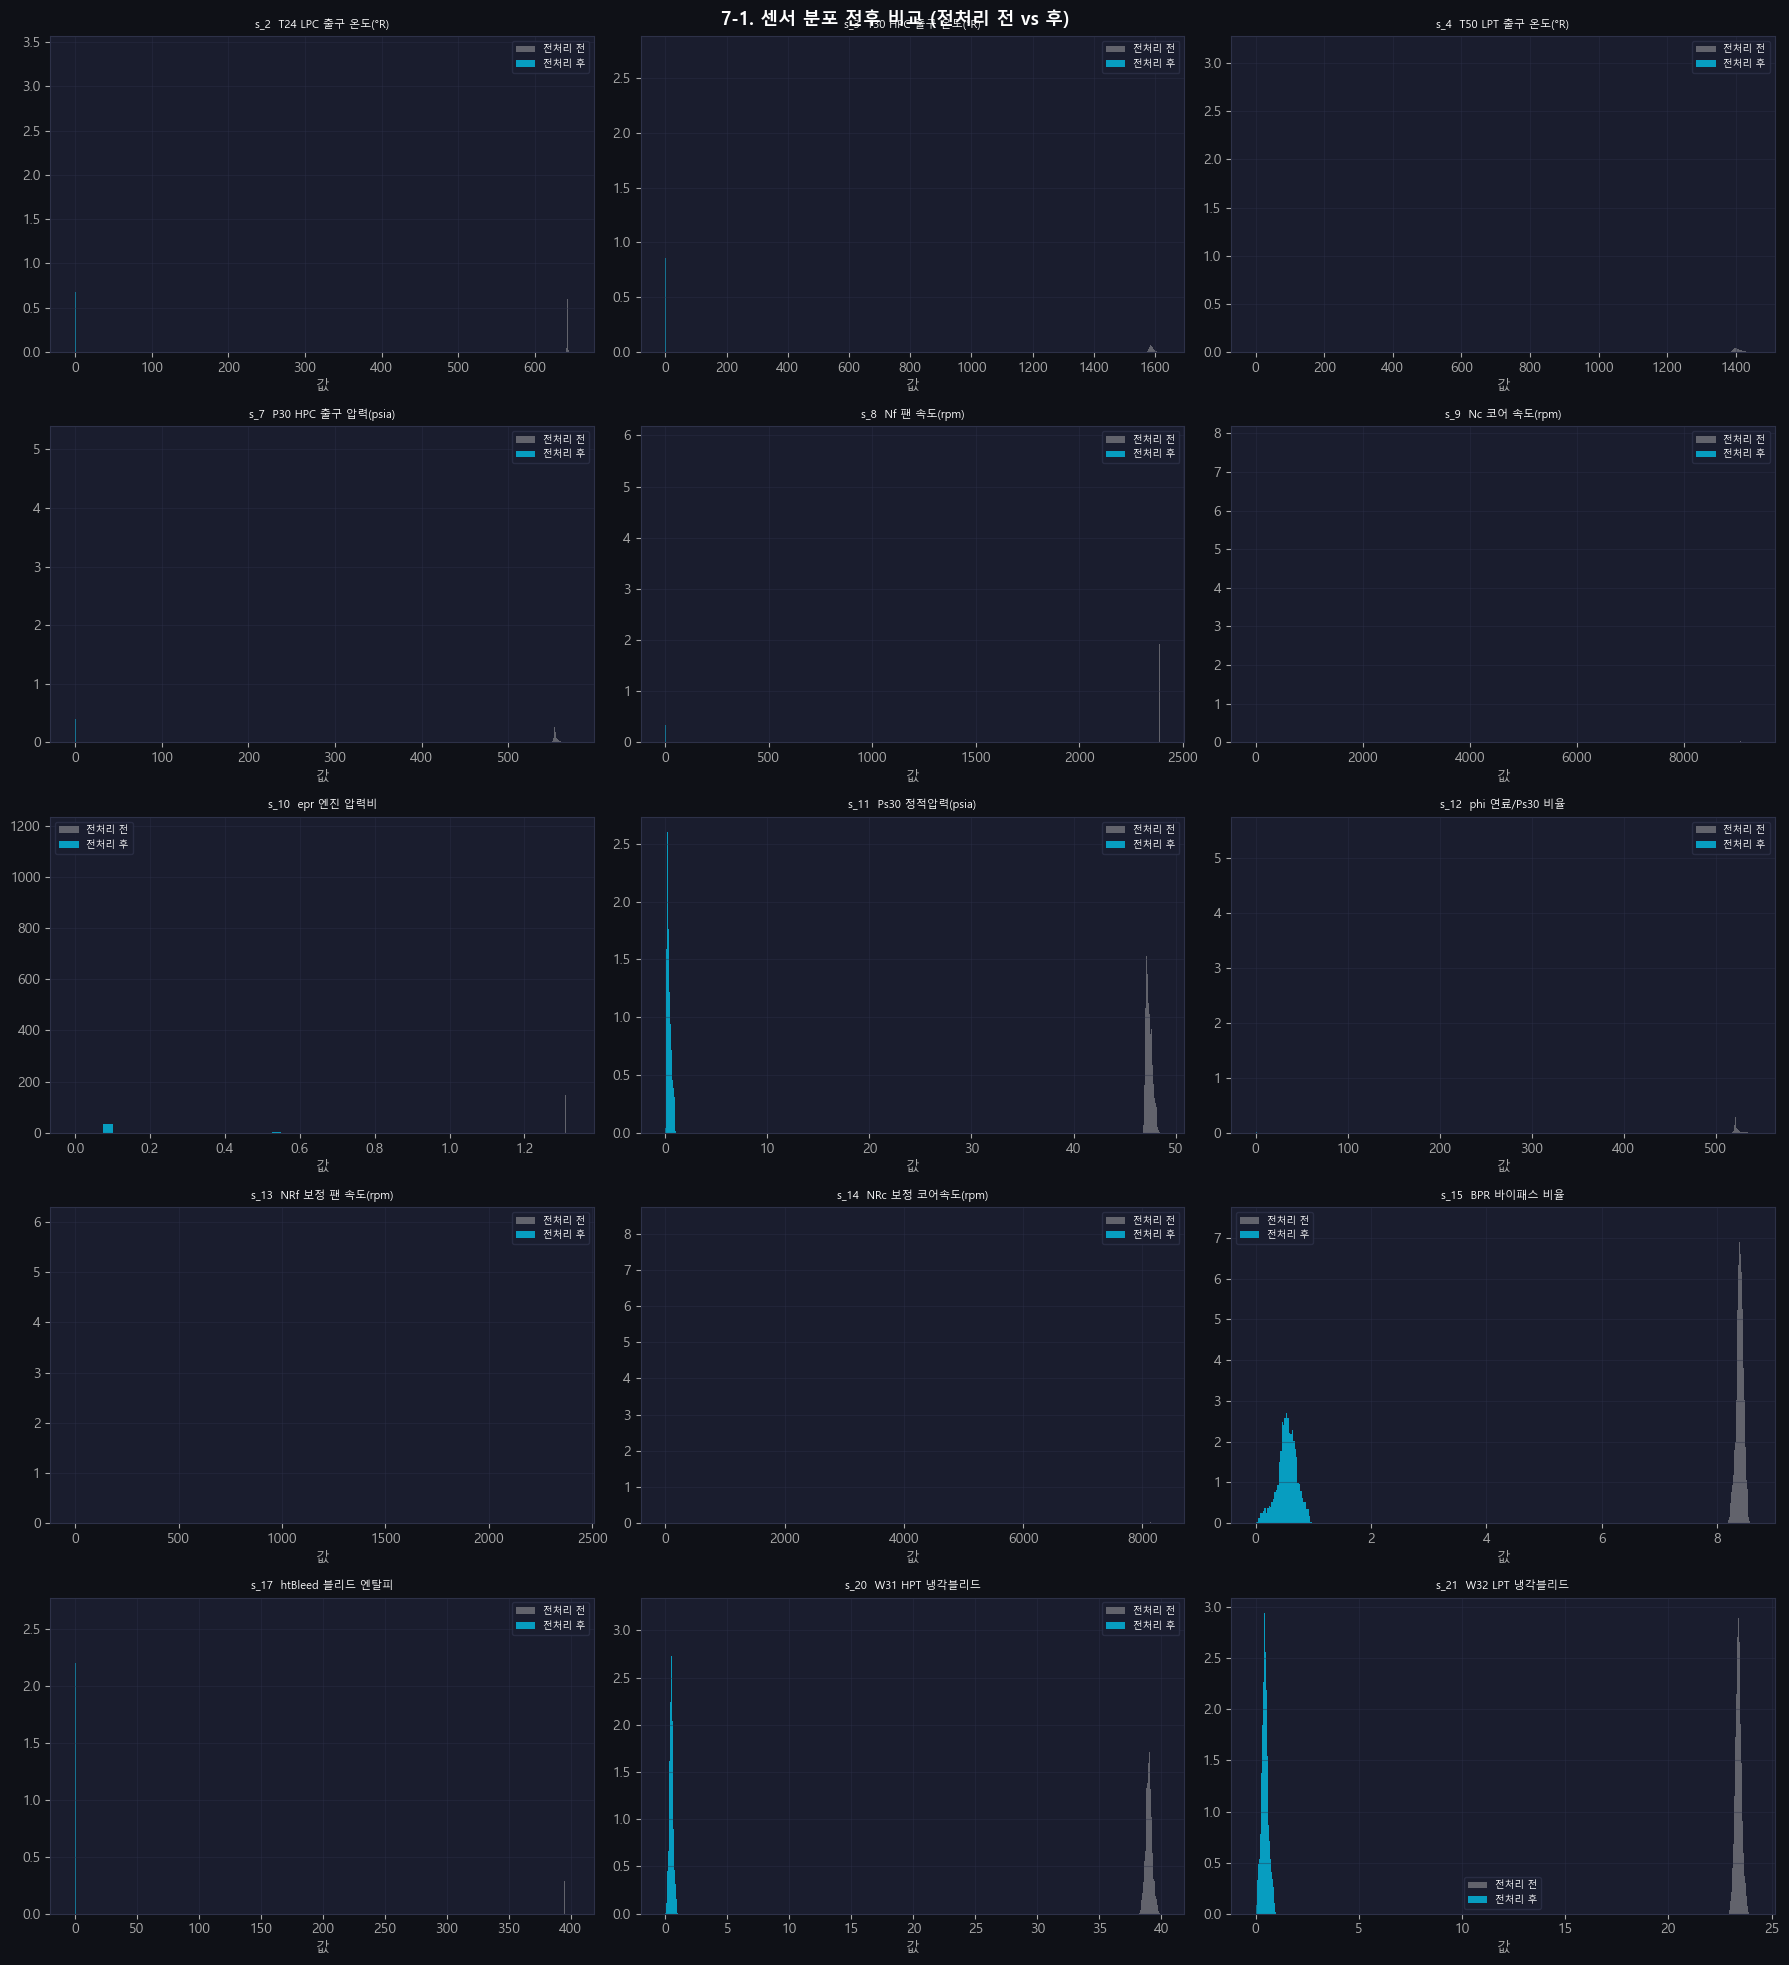

✅ 7-1 완료


In [24]:
# ============================================================
# 전처리 전후 검증 시각화
# ============================================================

# ── 7-1. 센서 분포 전후 비교 ─────────────────────────────────
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
fig.suptitle('7-1. 센서 분포 전후 비교 (전처리 전 vs 후)', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, USEFUL_SENSORS):
    before = train_raw[s].dropna()
    after  = subtrain_s4[s].dropna()
    ax.hist(before, bins=40, color=GRAY,  alpha=0.5, density=True, label='전처리 전')
    ax.hist(after,  bins=40, color=C[0],  alpha=0.7, density=True, label='전처리 후')
    ax.set_title(f'{s}  {SENSOR_DESC.get(s,"")[:20]}', fontsize=8)
    ax.set_xlabel('값'); ax.legend(fontsize=7)

for ax in axes.flat[len(USEFUL_SENSORS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()
print('✅ 7-1 완료')

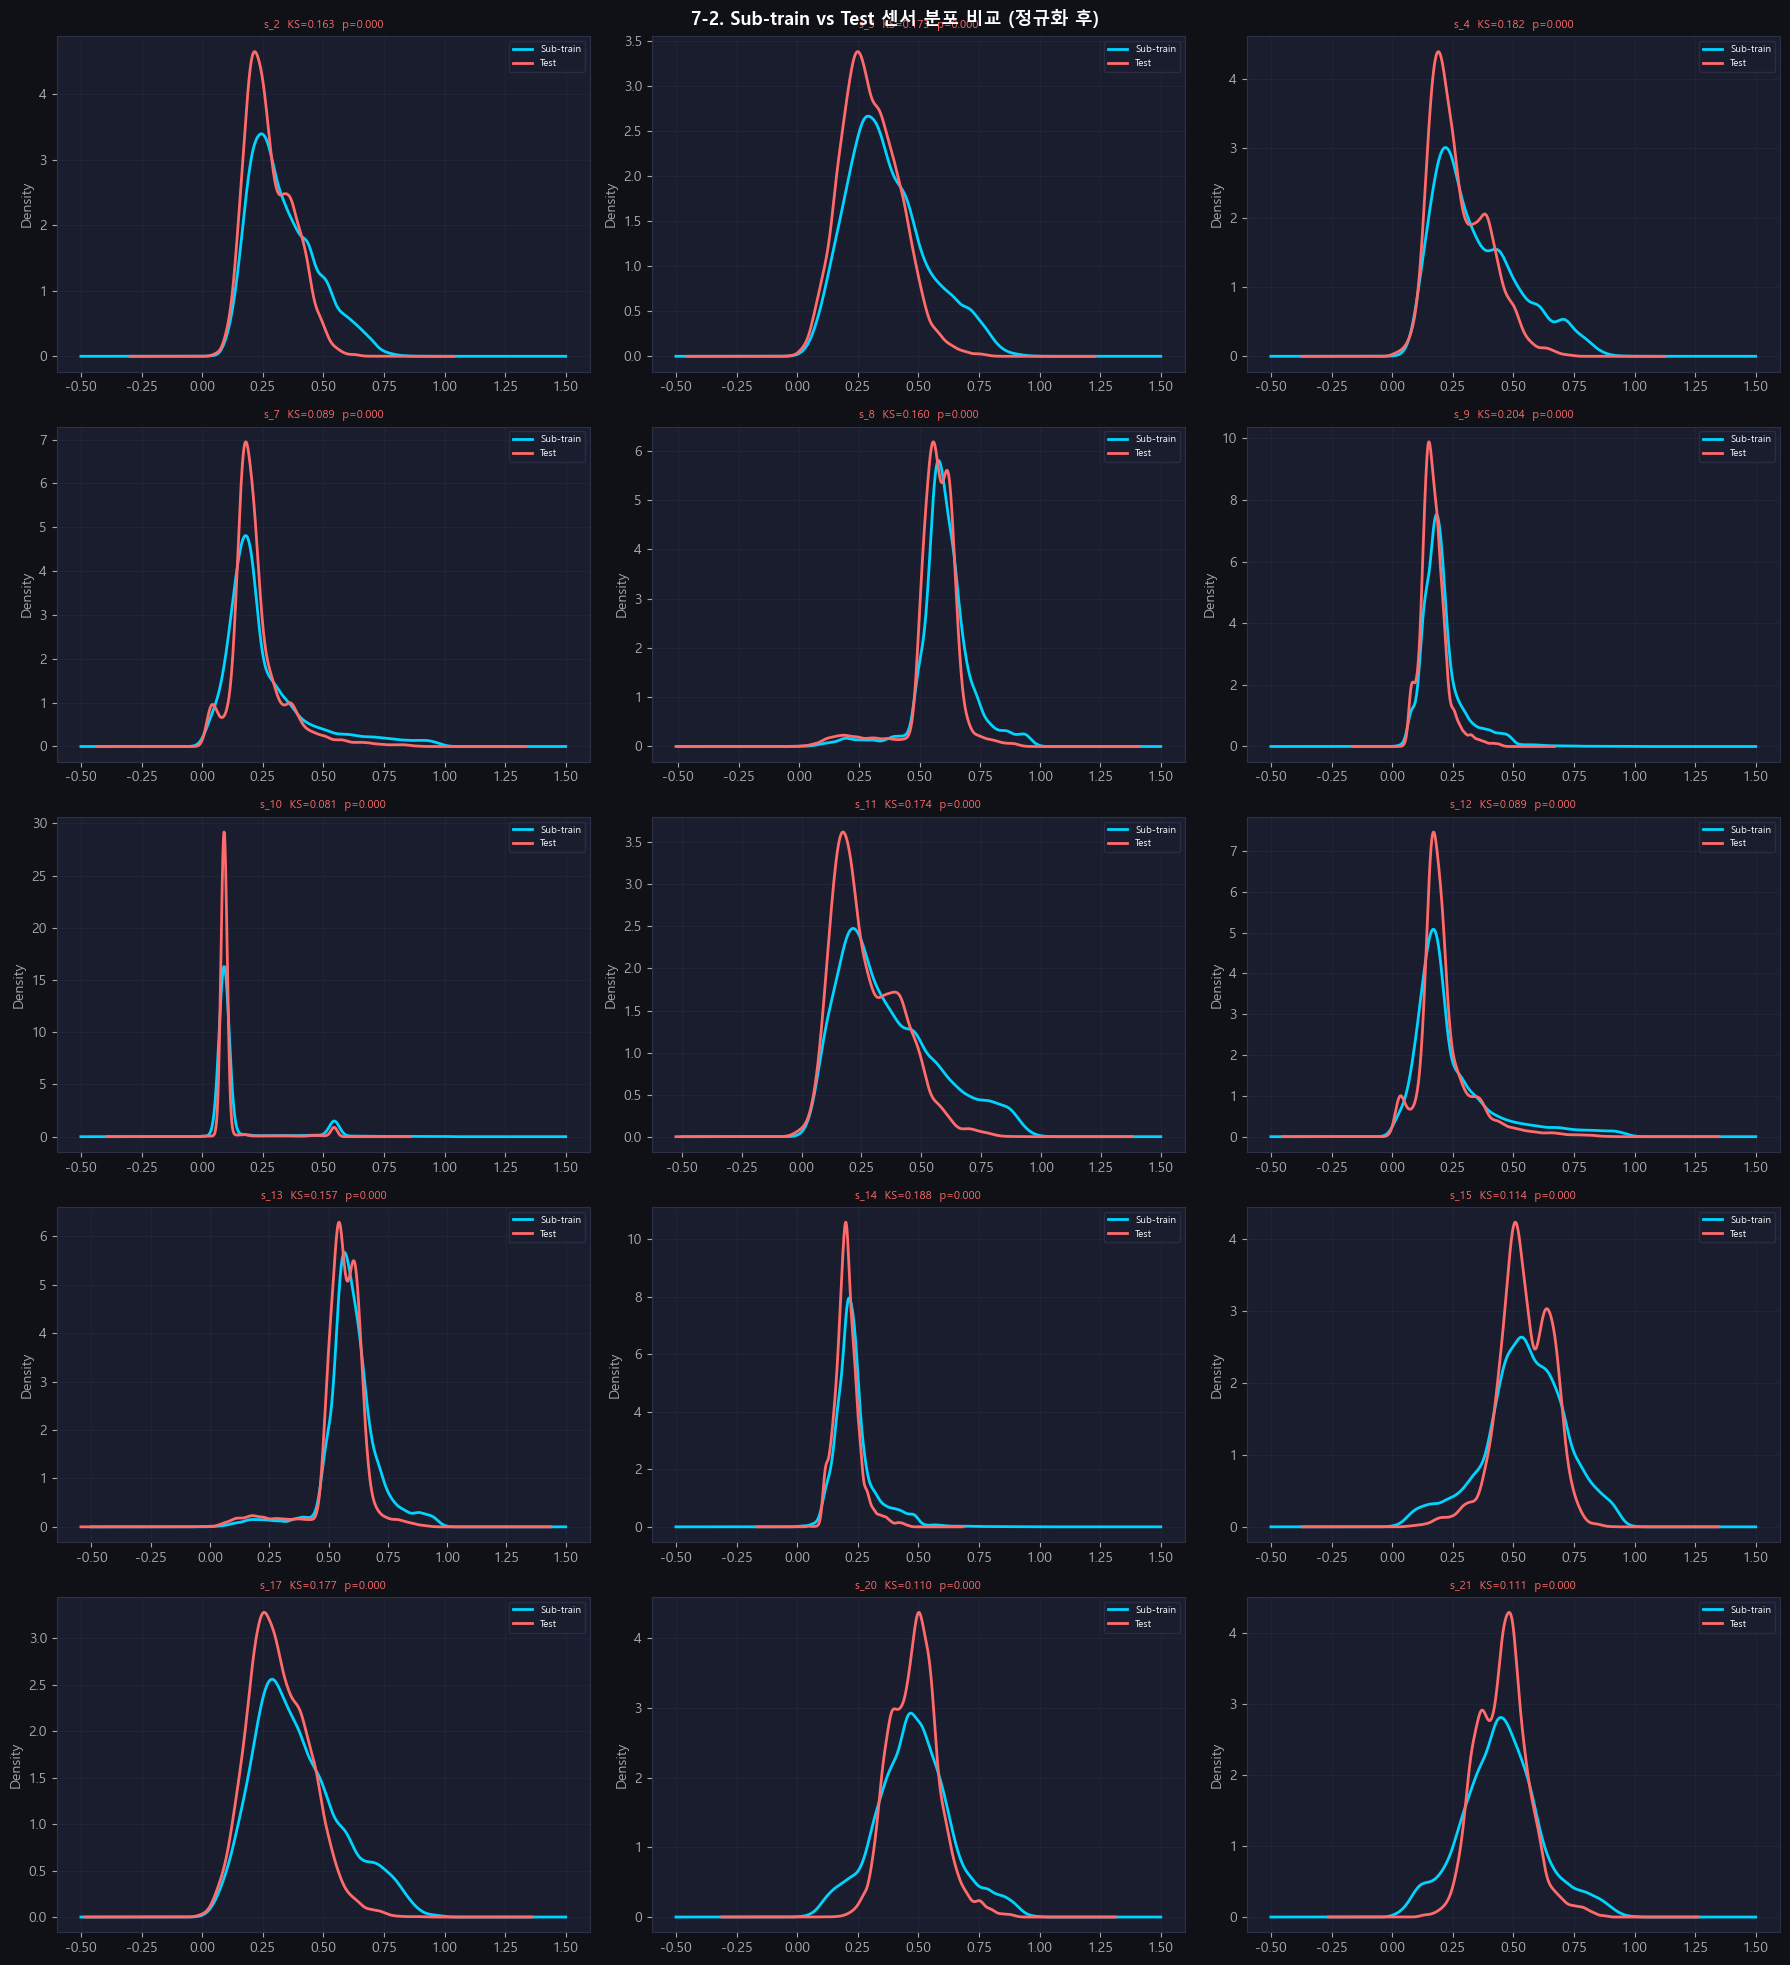

,KS 통계량,p-value,판정
센서,,,
s_2,0.1626,0.0,분포 다름 ⚠️
s_3,0.1727,0.0,분포 다름 ⚠️
s_4,0.1819,0.0,분포 다름 ⚠️
s_7,0.0890,0.0,분포 다름 ⚠️
s_8,0.1605,0.0,분포 다름 ⚠️
s_9,0.2042,0.0,분포 다름 ⚠️
s_10,0.0810,0.0,분포 다름 ⚠️
s_11,0.1741,0.0,분포 다름 ⚠️
s_12,0.0886,0.0,분포 다름 ⚠️



분포 유사 센서: 0/15개
✅ 7-2 완료


In [25]:
# ── 7-2. Train vs Test 분포 비교 (KS 검정) ───────────────────
from scipy.stats import ks_2samp

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
fig.suptitle('7-2. Sub-train vs Test 센서 분포 비교 (정규화 후)', fontsize=13, fontweight='bold')

ks_rows = []
for ax, s in zip(axes.flat, USEFUL_SENSORS):
    train_vals = subtrain_s4[s].dropna()
    test_vals  = test_s4[s].dropna()
    stat, p    = ks_2samp(train_vals, test_vals)
    ks_rows.append({'센서': s, 'KS 통계량': round(stat,4), 'p-value': round(p,4),
                    '판정': '분포 유사 ✅' if p > 0.05 else '분포 다름 ⚠️'})
    color = C[2] if p > 0.05 else C[1]
    try:
        train_vals.plot.kde(ax=ax, color=C[0], lw=2, label='Sub-train')
        test_vals.plot.kde( ax=ax, color=color, lw=2, label='Test')
    except: pass
    ax.set_title(f'{s}  KS={stat:.3f}  p={p:.3f}', fontsize=8,
                 color=C[2] if p > 0.05 else C[1])
    ax.legend(fontsize=7)

for ax in axes.flat[len(USEFUL_SENSORS):]:
    ax.set_visible(False)

plt.tight_layout(); plt.show()

ks_df = pd.DataFrame(ks_rows).set_index('센서')
display(ks_df)
print(f'\n분포 유사 센서: {(ks_df["판정"]=="분포 유사 ✅").sum()}/{len(USEFUL_SENSORS)}개')
print('✅ 7-2 완료')

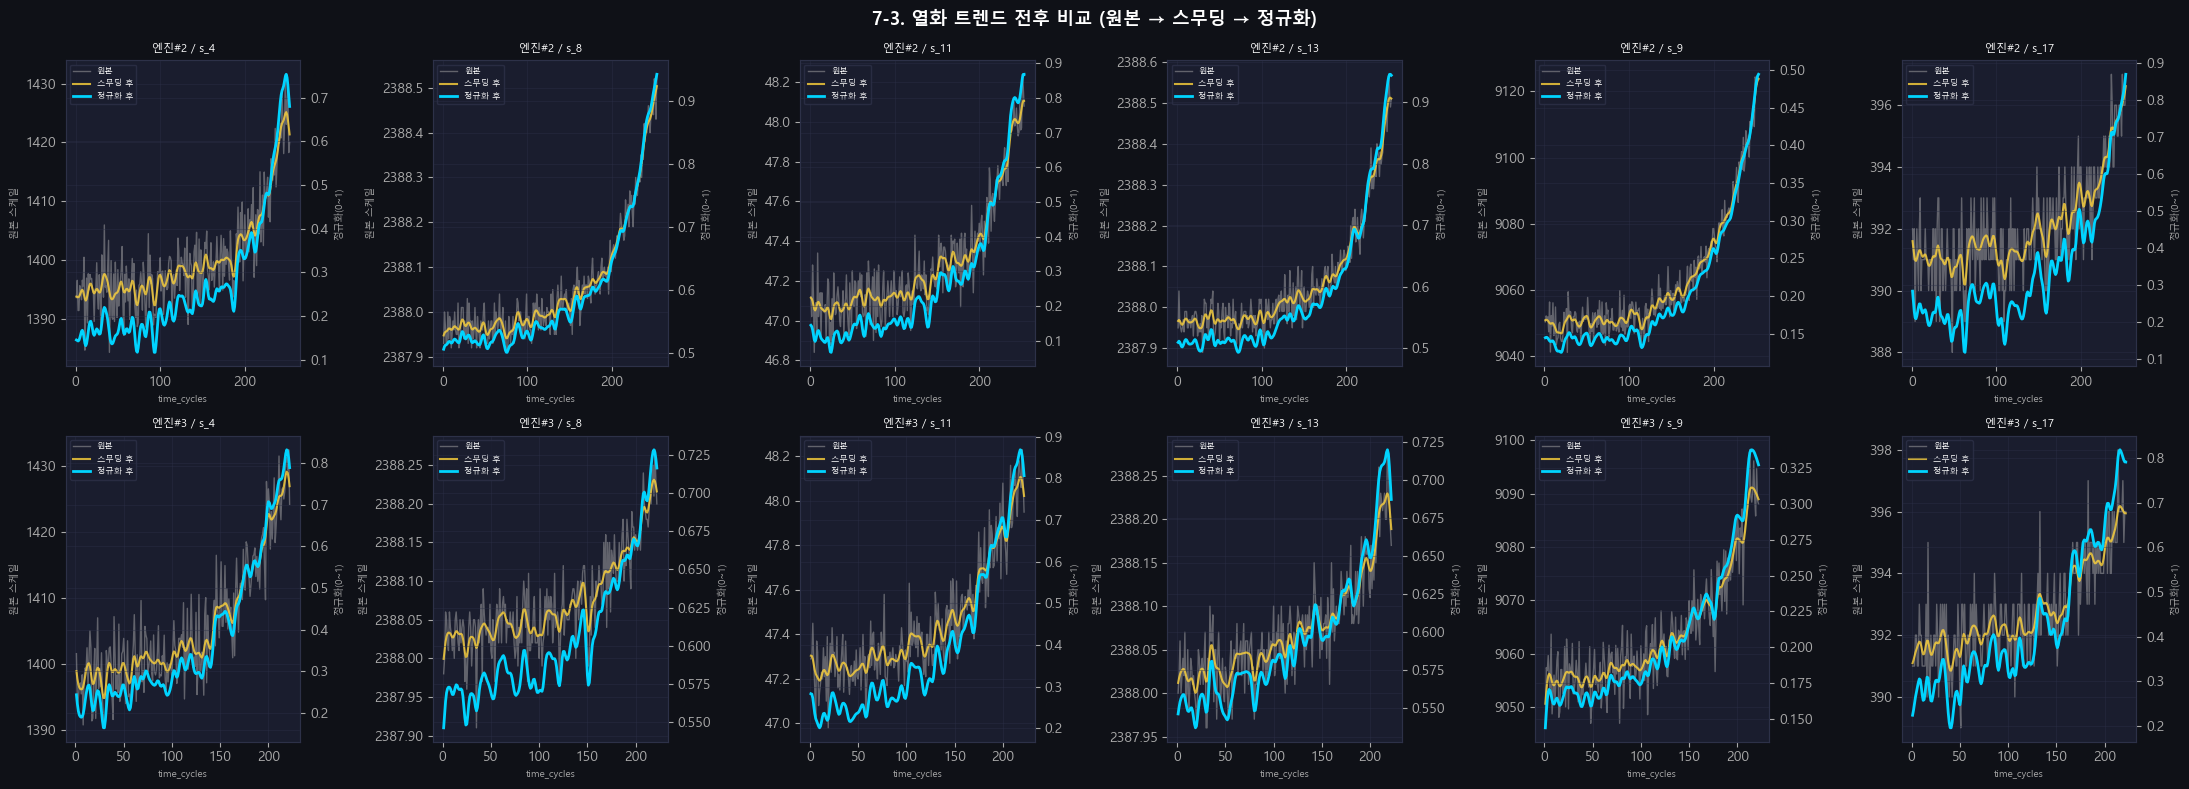

✅ 7-3 완료


In [26]:
# 7-3 수정: 원본 → 스무딩 후 → 정규화 후 3단계 비교
sample_sensors = ['s_4','s_8','s_11','s_13','s_9','s_17']
sample_units   = subtrain['unit_nr'].unique()[:2]

fig, axes = plt.subplots(len(sample_units), len(sample_sensors), figsize=(22, 8))
fig.suptitle('7-3. 열화 트렌드 전후 비교 (원본 → 스무딩 → 정규화)',
             fontsize=13, fontweight='bold')

for ri, uid in enumerate(sample_units):
    raw_data    = train_raw[train_raw['unit_nr']==uid].sort_values('time_cycles')
    smooth_data = train_s3[train_s3['unit_nr']==uid].sort_values('time_cycles')
    norm_data   = subtrain_s4[subtrain_s4['unit_nr']==uid].sort_values('time_cycles')
    for ci, s in enumerate(sample_sensors):
        ax = axes[ri, ci]
        ax2 = ax.twinx()  # 정규화 후는 다른 y축
        ax.plot(raw_data['time_cycles'],    raw_data[s],
                color=GRAY, lw=1, alpha=0.5, label='원본')
        ax.plot(smooth_data['time_cycles'], smooth_data[s],
                color=C[3], lw=1.5, alpha=0.8, label='스무딩 후')
        ax2.plot(norm_data['time_cycles'],  norm_data[s],
                 color=C[0], lw=2, label='정규화 후')
        ax.set_title(f'엔진#{uid} / {s}', fontsize=8)
        ax.set_xlabel('time_cycles', fontsize=7)
        ax.set_ylabel('원본 스케일', fontsize=7)
        ax2.set_ylabel('정규화(0~1)', fontsize=7)
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1+lines2, labels1+labels2, fontsize=6)

plt.tight_layout(); plt.show()
print('✅ 7-3 완료')

=== 7-4. 고장 모드 혼재 영향 확인 ===
목적: 전처리 후에도 고장 모드별 열화 트렌드 차이가 유지되는지 확인


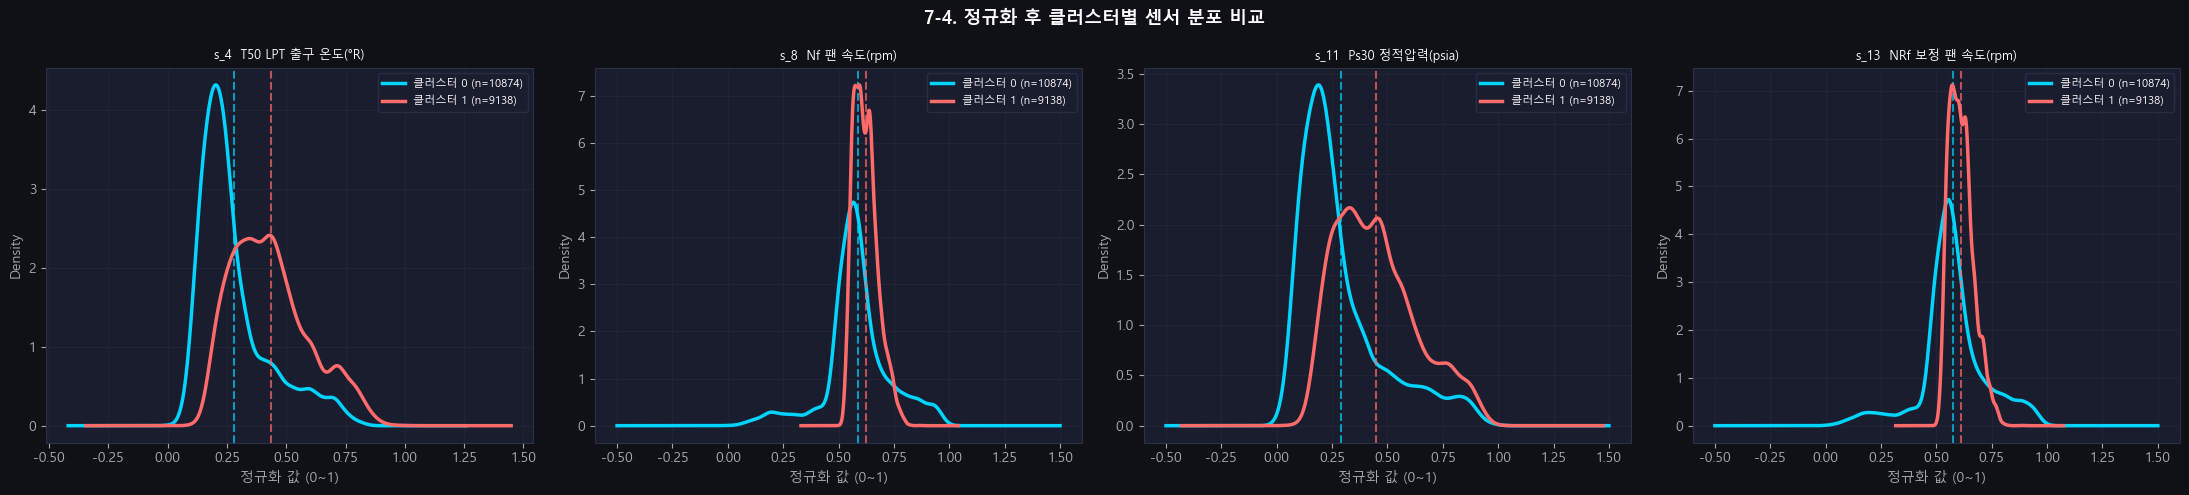

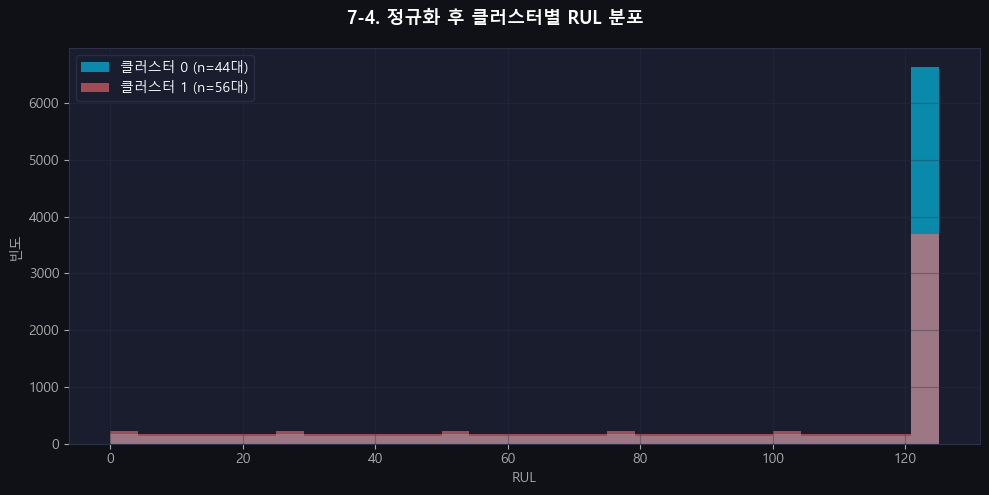

✅ 7-4 완료


In [27]:
# ── 7-4. 고장 모드 혼재 영향 확인 (FD003 전용 ★) ─────────────
print('=== 7-4. 고장 모드 혼재 영향 확인 ===')
print('목적: 전처리 후에도 고장 모드별 열화 트렌드 차이가 유지되는지 확인')

# slope_df에서 클러스터 라벨 가져오기
tr_check = subtrain_s4.copy()
tr_check['fault_mode_cluster'] = tr_check['unit_nr'].map(
    slope_df['fault_mode_cluster']
).fillna(-1).astype(int)

show_sensors = ['s_4','s_8','s_11','s_13']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('7-4. 정규화 후 클러스터별 센서 분포 비교', fontsize=13, fontweight='bold')

for ax, s in zip(axes, show_sensors):
    for c, color in zip([0,1], [C[0], C[1]]):
        data = tr_check[tr_check['fault_mode_cluster']==c][s].dropna()
        if len(data) > 1:
            try:
                data.plot.kde(ax=ax, color=color, lw=2.5,
                              label=f'클러스터 {c} (n={len(data)})')
            except: pass
        ax.axvline(data.mean(), color=color, ls='--', lw=1.5, alpha=0.7)
    ax.set_title(f'{s}  {SENSOR_DESC.get(s,"")}', fontsize=9)
    ax.set_xlabel('정규화 값 (0~1)')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# RUL 분포 확인
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('7-4. 정규화 후 클러스터별 RUL 분포', fontsize=13, fontweight='bold')
for c, color in zip([0,1], [C[0], C[1]]):
    units = slope_df[slope_df['fault_mode_cluster']==c].index
    rul_vals = subtrain_s4[subtrain_s4['unit_nr'].isin(units)]['RUL']
    ax.hist(rul_vals, bins=30, color=color, alpha=0.6,
            label=f'클러스터 {c} (n={len(units)}대)')
ax.set_xlabel('RUL'); ax.set_ylabel('빈도'); ax.legend()
plt.tight_layout(); plt.show()
print('✅ 7-4 완료')

---
### 검증 — ML 파생변수 다중공선성 (|r| > 0.95)

lag / rolling / EMA는 같은 센서에서 파생되므로 피처 간 상관이 매우 높을 수 있다.  
Ridge / Lasso / ElasticNet은 자체적으로 처리하지만, Tree 계열은 피처 중요도가 분산된다.  
실제 제거는 모델 피처 중요도 확인 후 결정.


In [28]:
print(f'=== ML 파생변수 다중공선성 (|r|>0.95) — {len(ML_FEATURES)}개 피처 ===')

corr_ml   = subtrain_ml[ML_FEATURES].corr().abs()
upper_ml  = corr_ml.where(np.triu(np.ones(corr_ml.shape), k=1).astype(bool))
HIGH_THR  = 0.95
high_pairs_ml = (upper_ml.stack().reset_index()
                 .rename(columns={'level_0':'피처A','level_1':'피처B',0:'|r|'})
                 .query('`|r|` >= @HIGH_THR')
                 .sort_values('|r|', ascending=False)
                 .reset_index(drop=True))

total_pairs = len(ML_FEATURES) * (len(ML_FEATURES) - 1) // 2
print(f'|r|≥{HIGH_THR} 쌍: {len(high_pairs_ml)}개 / 전체 {total_pairs}쌍')
if len(high_pairs_ml):
    display(high_pairs_ml.head(20))
print('→ 실제 제거는 모델 피처 중요도 확인 후 결정 권장')


=== ML 파생변수 다중공선성 (|r|>0.95) — 150개 피처 ===
|r|≥0.95 쌍: 753개 / 전체 11175쌍


,피처A,피처B,|r|
0,s_12_lag1,s_12_roll3,0.999996
1,s_7_lag1,s_7_roll3,0.999994
2,s_14_lag1,s_14_roll3,0.999987
3,s_9_lag1,s_9_roll3,0.999984
4,s_12_roll5,s_12_ema5,0.999970
5,s_15_lag1,s_15_roll3,0.999960
6,s_7_roll5,s_7_ema5,0.999959
7,s_10_lag1,s_10_roll3,0.999958
8,s_11_lag1,s_11_roll3,0.999955
9,s_21_lag1,s_21_roll3,0.999935


→ 실제 제거는 모델 피처 중요도 확인 후 결정 권장


---
## val_eval 생성 (수명 50~90% 절단)

C-MAPSS 테스트 셋은 각 엔진이 고장 전 임의 시점에서 절단된 구조.  
validation 전체 궤적과 분포가 달라 val_eval로 테스트 조건을 모방한다.

| 데이터 | 역할 |
|---|---|
| `X_valid_dl` / `y_valid_dl` | 학습 루프 early stopping 기준 |
| `val_eval_ml` / `dl_val_eval_long` | **최종 성능 평가** (학습 완료 후만 사용) |

> ⚠️ val_eval을 early stopping이나 HPO 기준으로 쓰면 낙관적 편향 발생.


In [29]:
def make_val_eval(df_ml, df_dl, features_ml, features_dl, window,
                  cut_low=0.5, cut_high=0.9, random_state=42):
    """수명 50~90% 사이에서 절단 — test와 유사한 RUL 분포 생성 (ML + DL)
    누수 없음: valid 엔진만 사용, scaler는 subtrain 기준으로 이미 fit됨.
    """
    rng = np.random.RandomState(random_state)
    ml_rows, dl_rows = [], []
    common_units = sorted(set(df_ml['unit_nr'].unique()) & set(df_dl['unit_nr'].unique()))

    for uid in common_units:
        sub_ml = df_ml[df_ml['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)
        sub_dl = df_dl[df_dl['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)
        n_ml, n_dl = len(sub_ml), len(sub_dl)
        if n_ml < 2 or n_dl < window:
            continue

        cut_i = rng.randint(max(1, int(n_ml * cut_low)), int(n_ml * cut_high) + 1)
        cut_i = max(1, min(cut_i, n_ml))

        ml_cols = [c for c in ['unit_nr','time_cycles'] + features_ml + ['RUL']
                   if c in sub_ml.columns and c != 'fault_mode_cluster']
        ml_rows.append(sub_ml.iloc[cut_i - 1][ml_cols].to_dict())

        cut_ratio = (cut_i - 1) / max(n_ml - 1, 1)
        cut_dl    = max(window, min(int(cut_ratio * n_dl) + 1, n_dl))
        seg       = sub_dl.iloc[cut_dl - window : cut_dl]
        if len(seg) == window:
            rul_at_cut = sub_ml.iloc[cut_i - 1]['RUL']
            for t_i, (_, r) in enumerate(seg.iterrows()):
                dr = {'sample_id': uid, 'timestep': t_i}
                for feat in features_dl:
                    dr[feat] = r[feat] if feat in r.index else np.nan
                dr['RUL'] = rul_at_cut
                dl_rows.append(dr)

    return pd.DataFrame(ml_rows), pd.DataFrame(dl_rows)


val_eval_ml, dl_val_eval_long = make_val_eval(
    valid_ml, valid_s4, ML_FEATURES, DL_FEATURES, WINDOW_SIZE)

y_ve = val_eval_ml['RUL'].values if 'RUL' in val_eval_ml.columns else np.array([])
print('✅ val_eval 생성 완료')
print(f'   ML val_eval: {val_eval_ml.shape}')
print(f'   DL val_eval: {dl_val_eval_long.shape}')
if len(y_ve):
    print(f'   RUL 분포: μ={y_ve.mean():.1f}  min={y_ve.min():.0f}  max={y_ve.max():.0f}')
print('\n📌 사용 가이드:')
print('   [학습 루프 중] early stopping → X_valid_dl / y_valid_dl')
print('   [학습 완료 후] 최종 평가    → val_eval_ml / dl_val_eval_long')


✅ val_eval 생성 완료
   ML val_eval: (20, 153)
   DL val_eval: (600, 18)
   RUL 분포: μ=65.8  min=16  max=114

📌 사용 가이드:
   [학습 루프 중] early stopping → X_valid_dl / y_valid_dl
   [학습 완료 후] 최종 평가    → val_eval_ml / dl_val_eval_long


---
##  CSV 저장 & 최종 요약

In [30]:
# ============================================================
# CSV 저장 & 최종 요약 (ML + DL 통합)
# ============================================================

OUTPUT_DIR = 'preprocessed_FD003'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 파일명 자동 생성 (CONFIG 값 조합) ────────────────────────
clustering_tag = 'yc' if CLUSTERING else 'nc'
prefix = f'FD003_{clustering_tag}_cap{RUL_CAP}_sig{GAUSS_SIGMA}_win{WINDOW_SIZE}'
print(f'📁 저장 prefix: {prefix}')

dl_dir = os.path.join(OUTPUT_DIR, 'dl')
os.makedirs(dl_dir, exist_ok=True)

# ── ML 파일 경로 ──────────────────────────────────────────────
ml_subtrain_path  = os.path.join(OUTPUT_DIR, f'{prefix}_ml_subtrain.csv')
ml_valid_path     = os.path.join(OUTPUT_DIR, f'{prefix}_ml_valid.csv')
ml_test_path      = os.path.join(OUTPUT_DIR, f'{prefix}_ml_test.csv')
ml_test_eval_path = os.path.join(OUTPUT_DIR, f'{prefix}_ml_test_eval.csv')
ml_val_eval_path  = os.path.join(OUTPUT_DIR, f'{prefix}_ml_val_eval.csv')
ml_scaler_path    = os.path.join(OUTPUT_DIR, f'{prefix}_ml_scaler.pkl')
ml_feat_path      = os.path.join(OUTPUT_DIR, f'{prefix}_ml_features.txt')

# ── DL 파일 경로 ──────────────────────────────────────────────
dl_subtrain_path   = os.path.join(dl_dir, f'{prefix}_dl_subtrain_long.csv')
dl_valid_path      = os.path.join(dl_dir, f'{prefix}_dl_valid_long.csv')
dl_test_path       = os.path.join(dl_dir, f'{prefix}_dl_test_long.csv')
dl_val_eval_path   = os.path.join(dl_dir, f'{prefix}_dl_val_eval_long.csv')
dl_feat_path       = os.path.join(OUTPUT_DIR, f'{prefix}_dl_features.txt')
sensor_scaler_path = os.path.join(OUTPUT_DIR, f'{prefix}_sensor_scaler.pkl')
rul_path           = os.path.join(OUTPUT_DIR, f'{prefix}_test_RUL.csv')

# ── ML CSV 저장 ───────────────────────────────────────────────
subtrain_ml.to_csv(ml_subtrain_path,  index=False, encoding='utf-8-sig')
valid_ml.to_csv(ml_valid_path,        index=False, encoding='utf-8-sig')
test_ml.to_csv(ml_test_path,          index=False, encoding='utf-8-sig')
test_last_ml.to_csv(ml_test_eval_path,index=False, encoding='utf-8-sig')
ml_save_cols = [c for c in ['unit_nr','time_cycles'] + ML_FEATURES + ['RUL']
                if c in val_eval_ml.columns]
val_eval_ml[ml_save_cols].to_csv(ml_val_eval_path, index=False, encoding='utf-8-sig')

# ── DL CSV 저장 ───────────────────────────────────────────────
dl_subtrain_long.to_csv(dl_subtrain_path,  index=False, encoding='utf-8-sig')
dl_valid_long.to_csv(dl_valid_path,        index=False, encoding='utf-8-sig')
dl_test_long.to_csv(dl_test_path,          index=False, encoding='utf-8-sig')
dl_val_eval_long.to_csv(dl_val_eval_path,  index=False, encoding='utf-8-sig')
rul_df.to_csv(rul_path,                    index=False, encoding='utf-8-sig')

# ── 스케일러 & 피처 목록 저장 ────────────────────────────────
joblib.dump(scaler,    sensor_scaler_path)
joblib.dump(ml_scaler, ml_scaler_path)
with open(ml_feat_path, 'w', encoding='utf-8') as f:
    for col in ['unit_nr','time_cycles'] + ML_FEATURES + ['RUL']:
        f.write(f'{col}\n')
with open(dl_feat_path, 'w', encoding='utf-8') as f:
    for col in DL_FEATURES:
        f.write(f'{col}\n')

# ── 저장 검증 ─────────────────────────────────────────────────
chk_sub = pd.read_csv(dl_subtrain_path)
chk_val = pd.read_csv(dl_valid_path)
chk_te  = pd.read_csv(dl_test_path)

# ── 최종 요약 ─────────────────────────────────────────────────
print('=' * 74)
print('  FD003 ML / DL 통합 전처리 파이프라인 완료')
print('=' * 74)
print()
print('■ 공통 파이프라인')
print(f'  수동 제거: {MANUAL_REMOVE}  |  수동 유지: {MANUAL_KEEP}')
print(f'  → RUL Cap={RUL_CAP} → Gaussian(σ={GAUSS_SIGMA})')
print(f'  → Validation 분할(80:20, random_state={RANDOM_STATE})')
print(f'  → {SCALER_TYPE} 정규화  |  클러스터링: {"적용" if CLUSTERING else "미적용"}')
print()
print('■ ML 분기 — lag/diff/rolling/EMA 파생변수 + ML 전체 피처 MinMax 정규화')
ml_summary = pd.DataFrame({
    '구분'      : ['Sub-train','Validation','Test(전체)','Test(평가용)','val_eval'],
    'shape'     : [str(subtrain_ml.shape), str(valid_ml.shape), str(test_ml.shape),
                   str(test_last_ml.shape), str(val_eval_ml.shape)],
    'ML 피처 수': [len(ML_FEATURES)] * 5,
    '파일'      : [os.path.basename(ml_subtrain_path),
                   os.path.basename(ml_valid_path),
                   os.path.basename(ml_test_path),
                   os.path.basename(ml_test_eval_path),
                   os.path.basename(ml_val_eval_path)],
}).set_index('구분')
display(ml_summary)

print()
print('■ DL 분기 — 센서 MinMax 정규화 후 슬라이딩 윈도우 Long Format')
n_ve = dl_val_eval_long['sample_id'].nunique() if len(dl_val_eval_long) > 0 else 0
dl_summary = pd.DataFrame({
    '구분'       : ['Sub-train','Validation','Test','val_eval'],
    'shape'      : [str(chk_sub.shape), str(chk_val.shape),
                    str(chk_te.shape),  str(dl_val_eval_long.shape)],
    '샘플 수'    : [X_subtrain_dl.shape[0], X_valid_dl.shape[0],
                    X_test_dl.shape[0],     n_ve],
    'window_size': [WINDOW_SIZE] * 4,
    'DL 피처 수' : [len(DL_FEATURES)] * 4,
    '파일(dl/)'  : [os.path.basename(dl_subtrain_path),
                    os.path.basename(dl_valid_path),
                    os.path.basename(dl_test_path),
                    os.path.basename(dl_val_eval_path)],
}).set_index('구분')
display(dl_summary)

print()
print(f'📄 저장 경로: {os.path.abspath(OUTPUT_DIR)}/')
print(f'   - Sensor scaler: {os.path.basename(sensor_scaler_path)}')
print(f'   - ML scaler    : {os.path.basename(ml_scaler_path)}')
print()
print('── ML 활용법 ──')
print(f'  subtrain = pd.read_csv("{os.path.basename(ml_subtrain_path)}")')
print(f'  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])')
print()
print('── DL 활용법 (Long Format → 3D 복원) ──')
print(f'  df  = pd.read_csv("dl/{os.path.basename(dl_subtrain_path)}")')
print(f'  grp = df.groupby("sample_id")')
print(f'  X   = np.stack([grp.get_group(i)[DL_FEATURES].values')
print(f'                  for i in range(df["sample_id"].nunique())])  # (N, {WINDOW_SIZE}, F)')
print(f'  y   = df.groupby("sample_id")["RUL"].last().values')


📁 저장 prefix: FD003_nc_cap125_sig2_win30
  FD003 ML / DL 통합 전처리 파이프라인 완료

■ 공통 파이프라인
  수동 제거: ['s_1', 's_5', 's_6', 's_16', 's_18', 's_19']  |  수동 유지: ['s_10']
  → RUL Cap=125 → Gaussian(σ=2)
  → Validation 분할(80:20, random_state=42)
  → minmax 정규화  |  클러스터링: 미적용

■ ML 분기 — lag/diff/rolling/EMA 파생변수 + ML 전체 피처 MinMax 정규화


,shape,ML 피처 수,파일
구분,,,
Sub-train,"(19612, 157)",150,FD003_nc_cap125_sig2_win30_ml_subtrain.csv
Validation,"(4608, 157)",150,FD003_nc_cap125_sig2_win30_ml_valid.csv
Test(전체),"(16096, 155)",150,FD003_nc_cap125_sig2_win30_ml_test.csv
Test(평가용),"(100, 156)",150,FD003_nc_cap125_sig2_win30_ml_test_eval.csv
val_eval,"(20, 153)",150,FD003_nc_cap125_sig2_win30_ml_val_eval.csv



■ DL 분기 — 센서 MinMax 정규화 후 슬라이딩 윈도우 Long Format


,shape,샘플 수,window_size,DL 피처 수,파일(dl/)
구분,,,,,
Sub-train,"(530760, 20)",17692,30,15,FD003_nc_cap125_sig2_win30_dl_subtrain_long.csv
Validation,"(123840, 20)",4128,30,15,FD003_nc_cap125_sig2_win30_dl_valid_long.csv
Test,"(3000, 20)",100,30,15,FD003_nc_cap125_sig2_win30_dl_test_long.csv
val_eval,"(600, 18)",20,30,15,FD003_nc_cap125_sig2_win30_dl_val_eval_long.csv



📄 저장 경로: c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\CMAPSS_DL\CMAPSS_DL_Optuna\CMAPSS_FD003_DL_Optuna\preprocessed_FD003/
   - Sensor scaler: FD003_nc_cap125_sig2_win30_sensor_scaler.pkl
   - ML scaler    : FD003_nc_cap125_sig2_win30_ml_scaler.pkl

── ML 활용법 ──
  subtrain = pd.read_csv("FD003_nc_cap125_sig2_win30_ml_subtrain.csv")
  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])

── DL 활용법 (Long Format → 3D 복원) ──
  df  = pd.read_csv("dl/FD003_nc_cap125_sig2_win30_dl_subtrain_long.csv")
  grp = df.groupby("sample_id")
  X   = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df["sample_id"].nunique())])  # (N, 30, F)
  y   = df.groupby("sample_id")["RUL"].last().values
